# OULAD — EDA Consolidated Notebook
> **Tổng hợp & lọc từ 3 notebooks**: `eda_exploratory.ipynb`, `EDA_Final_1.ipynb`, `EDA.ipynb`
>
> Mỗi section đều có: (1) code chạy được, (2) biểu đồ, (3) insight + quyết định feature engineering

**Dataset**: Open University Learning Analytics Dataset (OULAD)
- ~32K sinh viên, 7 modules, 2 kỳ học (B/J)
- Target: `final_result` ∈ {Distinction, Pass, Fail, Withdrawn}
- Mục tiêu: Early Warning System — dự đoán kết quả **trước khi kết thúc module**
- **`CUTOFF_DAY = 135`** — set ở Section 0, dùng xuyên suốt

---

| Section | Nội dung | Insight chính | Status |
|---------|----------|---------------|--------|
| 0 | Setup & Configuration | CUTOFF_DAY, helper functions | — |
| 1 | Schema Overview | Null patterns, file sizes | EDA gốc |
| 2 | Semantic Null Analysis | Null ≠ missing data — xử lý sai = pipeline sai | EDA gốc |
| 3 | Target Variable + Demographics | Class imbalance, chi-square ranking | EDA gốc |
| 4 | Assessment Analysis | Score distribution + submission timing | EDA gốc |
| 5 | Module Structure Audit | Không so sánh raw score cross-module | EDA gốc |
| 6 | Presentation Effect (B vs J) | Cần feature `semester` + `module_semester` | EDA gốc |
| 7 | Cut-off Selection | Data-driven = day 135, trade-off coverage vs intervention | EDA gốc |
| 8 | Leakage Audit | TMA ✅ safe, CMA ⚠️ thận trọng, Exam ❌ drop | EDA gốc |
| 9 | VLE Time-series | Temporal features > `sum_click` tổng | EDA gốc |
| 10 | Statistical Tests | Chi-square + Spearman correlation matrix | EDA gốc |
| Summary | Feature Engineering Decisions | DROP / GIỮ / TẠO MỚI + modeling checklist | EDA gốc |
| **11** | **Pre-Course Engagement** | **Clicks trước day 0 có signal không?** | **Thêm mới** |
| **12** | **VLE Engagement Heatmap** | **Heatmap temporal + retention score per activity** | **Thêm mới** |
| **13** | **Cut-off Ablation Framework** | **Per-module analysis + placeholder ablation curve** | **Thêm mới** |

---

### Cách chạy

```python
# Chạy tuần tự từ Section 0 trở xuống
# studentVle.csv nặng (~10M rows) — Section 9, 11, 12 sẽ mất 30-60s load

# Nếu không tìm được data tự động:
MANUAL_DATA_DIR = '/path/to/oulad/data'   # set ở Section 0
```

### Dependency

```
pandas, numpy, matplotlib, seaborn, scipy
```

---
## Section 0 — Setup & Configuration

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
CUTOFF_DAY   = 135  # Kết quả từ Section 7 — không thay đổi sau khi đã chọn

# ── CONFIG: set path thủ công nếu cần ──────────────────────────────────────
MANUAL_DATA_DIR = None  # VD: r'C:\Users\ten\data'  hoặc '/home/user/oulad'

def _find_data_dir():
    if MANUAL_DATA_DIR:
        return Path(MANUAL_DATA_DIR)
    candidates = [
        Path(os.getcwd()),
        Path(os.getcwd()) / 'data',
        Path(os.getcwd()).parent / 'data',
        Path(os.getcwd()).parent,
    ]
    for p in candidates:
        if (p / 'studentInfo.csv').exists():
            return p
    raise FileNotFoundError(
        'Không tìm thấy studentInfo.csv.\n'
        'Set MANUAL_DATA_DIR = "<path>" ở đầu cell này.'
    )

DATA_DIR = _find_data_dir()
REQUIRED = [
    'studentInfo.csv', 'studentRegistration.csv', 'studentAssessment.csv',
    'studentVle.csv', 'assessments.csv', 'courses.csv', 'vle.csv'
]
missing_files = [f for f in REQUIRED if not (DATA_DIR / f).exists()]

print(f'DATA_DIR = {DATA_DIR.resolve()}')
if missing_files:
    print('⚠  Thiếu file:', missing_files)
else:
    print('✓  Tất cả 7 file CSV đều có mặt.')

# ── Helper functions ────────────────────────────────────────────────────────
RESULT_ORDER  = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
RESULT_COLORS = {'Distinction':'#2980b9', 'Pass':'#27ae60', 'Fail':'#e67e22', 'Withdrawn':'#e74c3c'}
RESULT_CLIST  = [RESULT_COLORS[r] for r in RESULT_ORDER]

def chi_square_test(df, feature, target):
    ct = pd.crosstab(df[feature], df[target])
    chi2, p, dof, _ = chi2_contingency(ct)
    return chi2, p, dof

def plot_stacked_bar(df, feature, target, title, ax=None, order=None):
    show_plot = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    ct = pd.crosstab(df[feature], df[target], normalize='index') * 100
    ct = ct.reindex(columns=RESULT_ORDER, fill_value=0)
    if order:
        ct = ct.reindex(order, fill_value=0)
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=RESULT_CLIST, edgecolor='white', width=0.75)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Tỉ lệ (%)')
    ax.set_xlabel('')
    ax.legend(title='', loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    if show_plot:
        plt.tight_layout()
        plt.show()

DATA_DIR = D:\CS-313-Data-Mining\data
✓  Tất cả 7 file CSV đều có mặt.


---
## Section 1 — Schema Overview

Nhìn nhanh toàn bộ dataset: shape, kiểu dữ liệu, missing values.

**Mục tiêu:** Xác định file nào có null, tỉ lệ bao nhiêu, để quyết định xử lý ở Section 2.

=== Schema Overview ===
                               Rows  Cols                                           Null Columns
File                                                                                            
studentInfo.csv              32,593    12                                        imd_band (3.4%)
studentRegistration.csv      32,593     5  date_registration (0.1%), date_unregistration (69.1%)
studentAssessment.csv       173,912     5                                           score (0.1%)
studentVle.csv           10,655,280     6                                                      —
assessments.csv                 206     6                                            date (5.3%)
courses.csv                      22     3                                                      —
vle.csv                       6,364     6                     week_from (82.4%), week_to (82.4%)


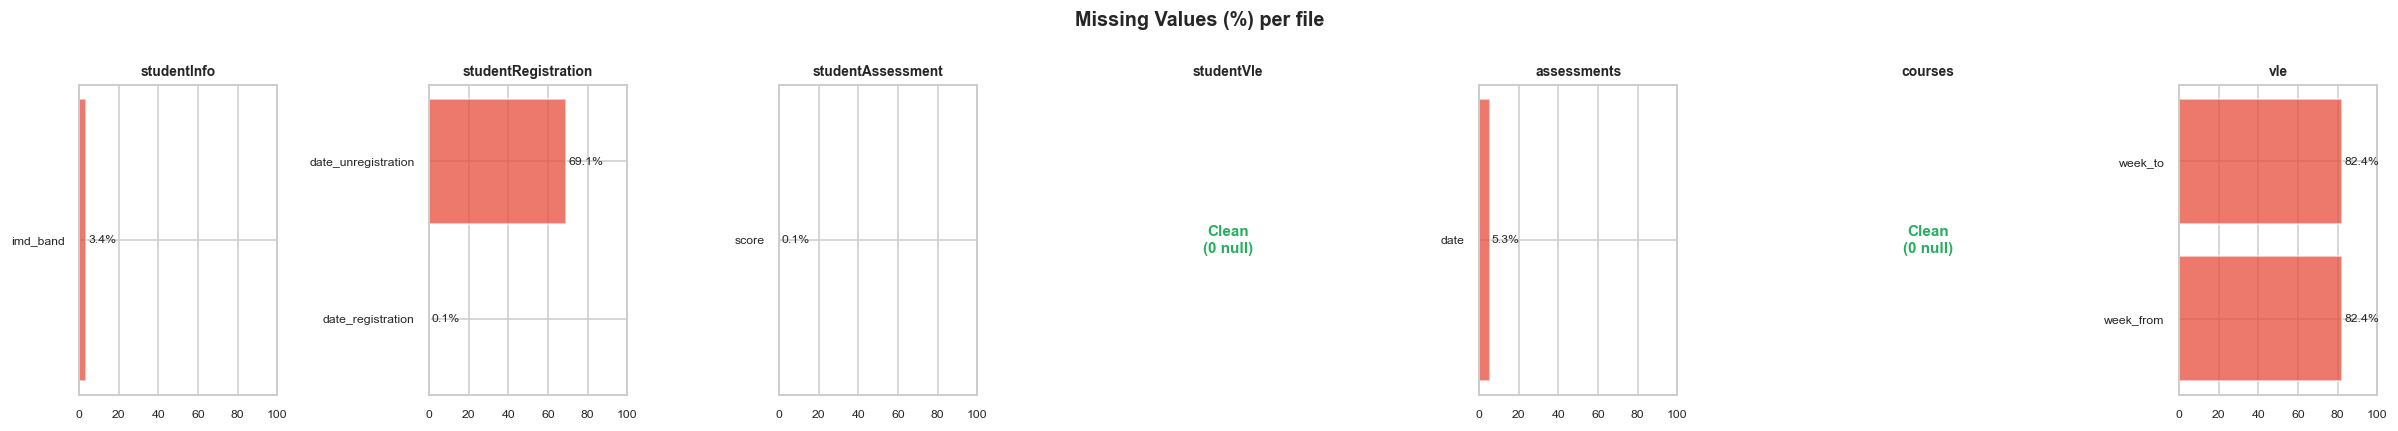

In [3]:
def section1_schema_overview():
    rows = []
    for f in REQUIRED:
        df = pd.read_csv(DATA_DIR / f)
        n_rows, n_cols = df.shape
        null_cols = df.columns[df.isnull().any()].tolist()
        null_pcts  = {c: f"{df[c].isnull().mean()*100:.1f}%" for c in null_cols}
        rows.append({
            'File': f,
            'Rows': f'{n_rows:,}',
            'Cols': n_cols,
            'Null Columns': ', '.join(f"{c} ({null_pcts[c]})" for c in null_cols) if null_cols else '—',
        })
    print('=== Schema Overview ===')
    print(pd.DataFrame(rows).set_index('File').to_string())

    # ── Missing heatmap per file ─────────────────────────────────────────
    fig, axes = plt.subplots(1, len(REQUIRED), figsize=(22, 4))
    for ax, f in zip(axes, REQUIRED):
        df   = pd.read_csv(DATA_DIR / f)
        miss = (df.isnull().mean() * 100).reset_index()
        miss.columns = ['Column', 'Missing %']
        miss = miss[miss['Missing %'] > 0]
        if miss.empty:
            ax.text(0.5, 0.5, 'Clean\n(0 null)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='#27ae60', fontweight='bold')
            ax.axis('off')
        else:
            bars = ax.barh(miss['Column'], miss['Missing %'], color='#e74c3c', alpha=0.75)
            ax.set_xlim(0, 100)
            for bar, val in zip(bars, miss['Missing %']):
                ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                        f'{val:.1f}%', va='center', fontsize=8)
        ax.set_title(f.replace('.csv',''), fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=8)
    plt.suptitle('Missing Values (%) per file', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section1_schema_overview()

---
## Section 2 — Semantic Null Analysis

> **Insight quan trọng nhất của EDA:** Null không phải lúc nào cũng là "thiếu data".
> Xử lý sai ở bước này = toàn bộ pipeline downstream bị ảnh hưởng.

| Column | Ý nghĩa thực | Xử lý đúng |
|--------|-------------|------------|
| `date_unregistration` = NULL | Sinh viên **không rút môn**, học đến cuối | **KHÔNG** dropna() |
| `date_unregistration` có giá trị | Sinh viên đã rút môn | Giữ nguyên |
| `score` = NULL | Sinh viên **không nộp bài** | `fillna(0)` — không nộp = 0 điểm |
| `imd_band` = NULL | Địa chỉ không map được vào vùng hành chính UK | Encode thành category `"Unknown"` |
| `week_from`, `week_to` = NULL (82.4%) | Resource available cả module | Drop cả 2 cột |
| `date` (assessments) = NULL (5.3%) | Không biết ngày deadline | Drop khi join |

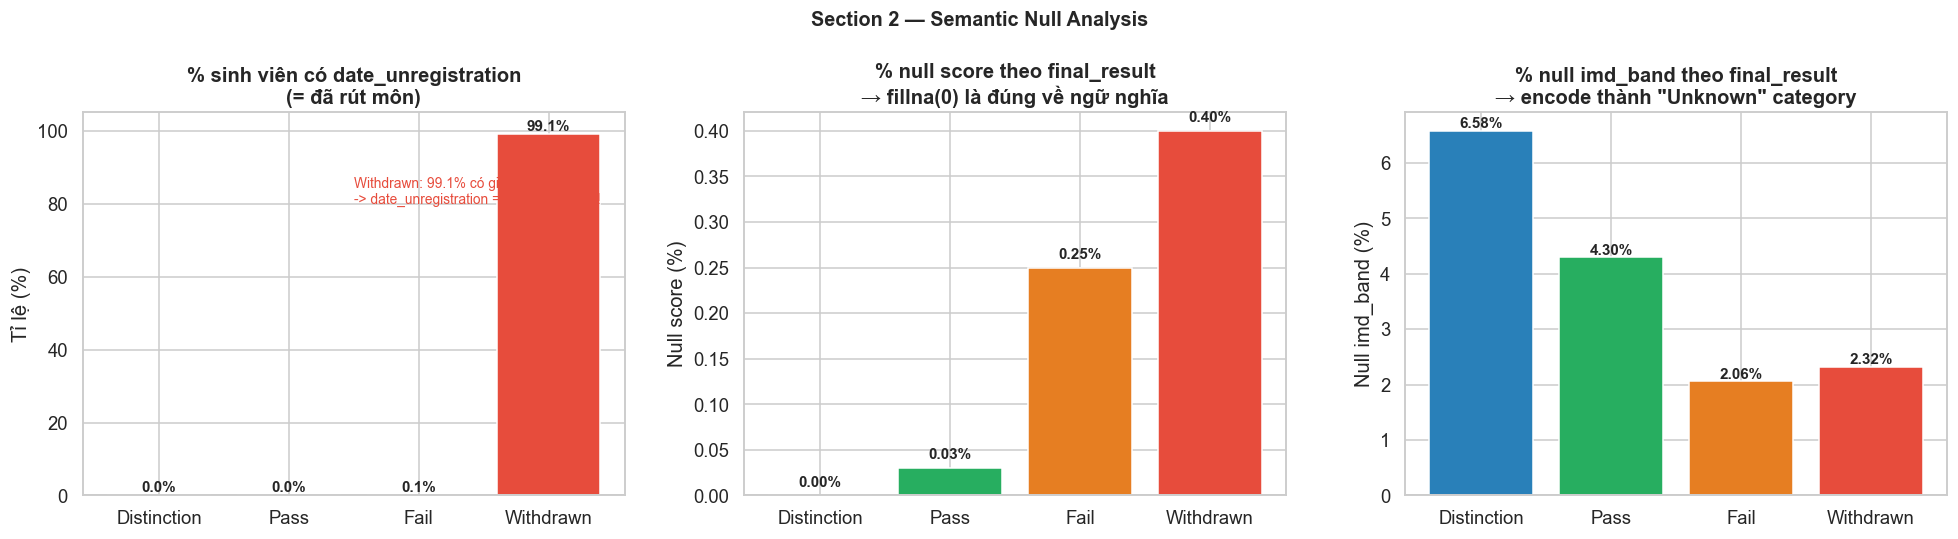

=== QUYẾT ĐỊNH XỬ LÝ NULL ===
  date_unregistration NULL → KHÔNG drop, NULL = "học đến cuối"
  date_unregistration có giá trị → KHÔNG dùng làm feature (leakage 100%!)
  score NULL → fillna(0), không nộp = 0 điểm
  imd_band NULL → encode "Unknown" category
  week_from/week_to NULL 82.4% → drop cả 2 cột


In [4]:
from matplotlib import axes


def section2_semantic_null():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    merged_reg = df_reg.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    merged_reg['has_unreg'] = merged_reg['date_unregistration'].notna()

    # Null score by final_result
    merged_sa = df_sa.merge(df_info[['id_student','final_result']], on='id_student')
    null_by_result = (
        merged_sa.groupby('final_result')['score']
        .apply(lambda x: x.isna().mean() * 100).round(2)
        .reindex(RESULT_ORDER).reset_index()
        .rename(columns={'score': 'null_pct'})
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: % has_unreg by result
    unreg_tbl = (
        merged_reg.groupby('final_result')['has_unreg']
        .mean().mul(100).round(1).reindex(RESULT_ORDER).reset_index()
    )
    colors_map = [RESULT_COLORS[r] for r in unreg_tbl['final_result']]
    bars = axes[0].bar(unreg_tbl['final_result'], unreg_tbl['has_unreg'],
                       color=colors_map, edgecolor='white')
    for bar, val in zip(bars, unreg_tbl['has_unreg']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
    axes[0].set_title('% sinh viên có date_unregistration\n(= đã rút môn)', fontweight='bold')
    axes[0].set_ylabel('Tỉ lệ (%)')
    axes[0].set_ylim(0, 105)
    axes[0].set_xlabel('')
    withdrawn_pct = (
    merged_reg[merged_reg['final_result'] == 'Withdrawn']['has_unreg']
    .mean() * 100
    )
    axes[0].annotate(
        f'Withdrawn: {withdrawn_pct:.1f}% có giá trị\n'
        f'-> date_unregistration = proxy cua label!',
        xy=(3, unreg_tbl['has_unreg'].iloc[3]),
        xytext=(1.5, 80), fontsize=9, color='#e74c3c',
        arrowprops=dict(arrowstyle='->', color='#e74c3c'))

    # Chart 2: Null score % by result
    colors_map2 = [RESULT_COLORS[r] for r in null_by_result['final_result']]
    bars2 = axes[1].bar(null_by_result['final_result'], null_by_result['null_pct'],
                        color=colors_map2, edgecolor='white')
    for bar, val in zip(bars2, null_by_result['null_pct']):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
    axes[1].set_title('% null score theo final_result\n→ fillna(0) là đúng về ngữ nghĩa', fontweight='bold')
    axes[1].set_ylabel('Null score (%)')
    axes[1].set_xlabel('')

    # Chart 3: imd_band null distribution
    df_info['imd_null'] = df_info['imd_band'].isna()
    imd_null_by_result = (
        df_info.groupby('final_result')['imd_null']
        .mean().mul(100).round(2).reindex(RESULT_ORDER).reset_index()
        .rename(columns={'imd_null': 'null_pct'})
    )
    colors_map3 = [RESULT_COLORS[r] for r in imd_null_by_result['final_result']]
    bars3 = axes[2].bar(imd_null_by_result['final_result'], imd_null_by_result['null_pct'],
                        color=colors_map3, edgecolor='white')
    for bar, val in zip(bars3, imd_null_by_result['null_pct']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
    axes[2].set_title('% null imd_band theo final_result\n→ encode thành "Unknown" category', fontweight='bold')
    axes[2].set_ylabel('Null imd_band (%)')
    axes[2].set_xlabel('')

    plt.suptitle('Section 2 — Semantic Null Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Decision log
    print('=== QUYẾT ĐỊNH XỬ LÝ NULL ===')
    print('  date_unregistration NULL → KHÔNG drop, NULL = "học đến cuối"')
    print('  date_unregistration có giá trị → KHÔNG dùng làm feature (leakage 100%!)')
    print('  score NULL → fillna(0), không nộp = 0 điểm')
    print('  imd_band NULL → encode "Unknown" category')
    print('  week_from/week_to NULL 82.4% → drop cả 2 cột')

section2_semantic_null()

---
## Section 3 — Target Variable + Demographic Analysis

### 3a. Phân phối target

| Label | Count | % | Ghi chú |
|-------|-------|---|---------|
| Pass | 12,361 | 37.9% | Nhóm lớn nhất |
| Withdrawn | 10,156 | 31.2% | **Quan trọng cho EWS** |
| Fail | 7,052 | 21.6% | — |
| Distinction | 3,024 | 9.3% | **Minority class — cần stratified split** |

### 3b. Signal của từng demographic feature

| Feature | Chi-square | Signal | Ghi chú |
|---------|-----------|--------|---------|
| `code_module` | Cao nhất | **Mạnh** | Distribution shift giữa modules |
| `highest_education` | Cao | Trung bình | HE Qual → pass tốt, Lower A Level → Withdrawn cao |
| `num_of_prev_attempts` | — | **Mạnh** | Monotonically negative — càng thi lại nhiều càng risk |
| `imd_band` | Trung bình | Trung bình | Vùng nghèo → At-Risk nhiều hơn |
| `age_band` | Trung bình | Trung bình | 0-35 Withdrawn cao nhất, 55+ Distinction cao nhất |
| `disability` | Thấp | Yếu | Không có diff lớn |
| `gender` | Thấp nhất | **Rất yếu** | Có thể drop |

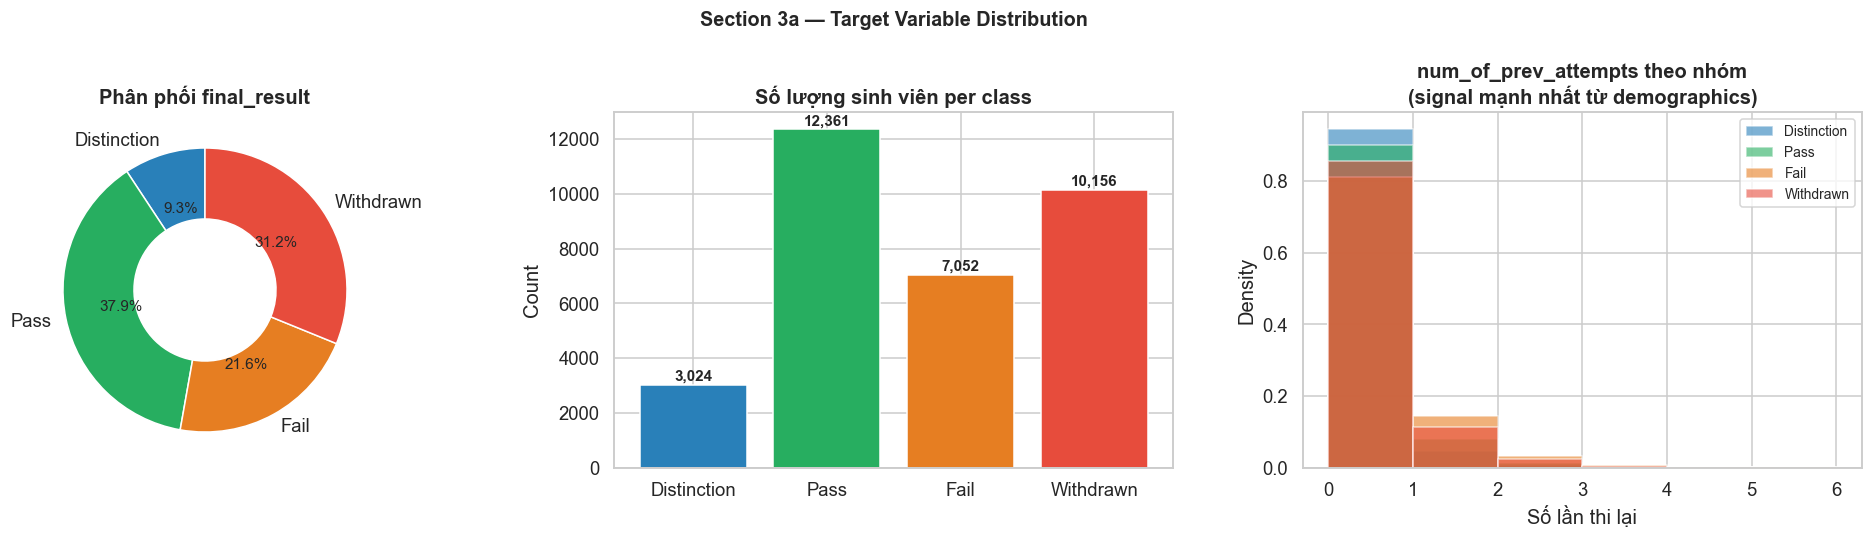

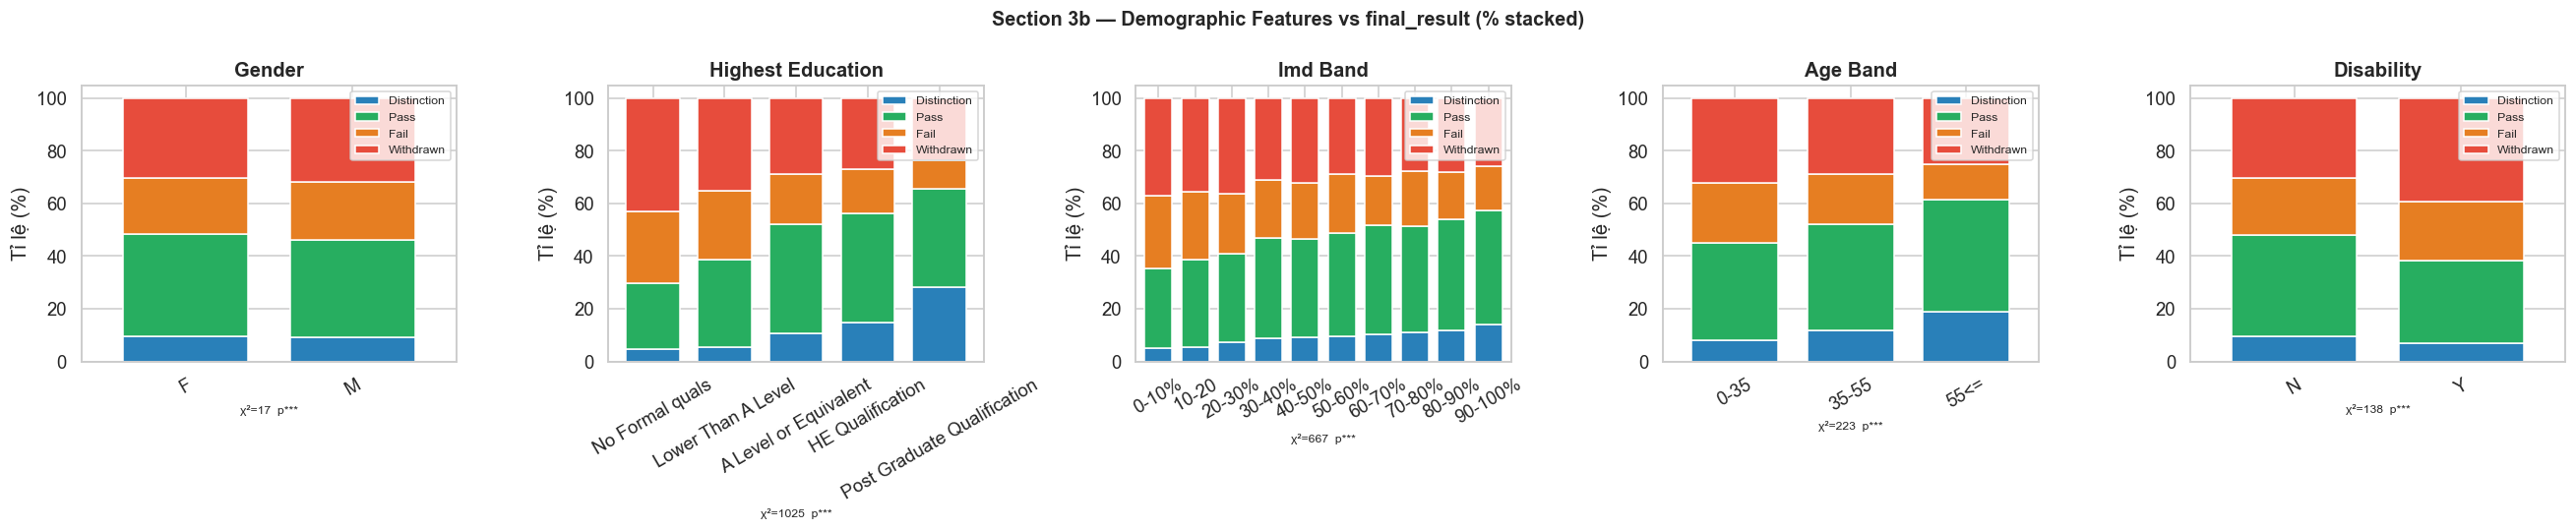


=== Chi-square ranking (demographics only) ===
  highest_education          χ²=  1024.7  p=9.18e-212  *** Mạnh
  imd_band                   χ²=   666.9  p=3.15e-123  *** Mạnh
  age_band                   χ²=   222.7  p=2.83e-45  *** Mạnh
  disability                 χ²=   138.5  p=8.14e-30  *** Mạnh
  gender                     χ²=    16.5  p=8.83e-04  *** Mạnh


In [4]:
def section3_target_analysis():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')

    # ── Fig 1: Distribution ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    counts = df['final_result'].value_counts().reindex(RESULT_ORDER)

    # Donut
    wedges, texts, autotexts = axes[0].pie(
        counts, labels=counts.index, colors=RESULT_CLIST,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white')
    )
    for at in autotexts:
        at.set_fontsize(10)
    axes[0].set_title('Phân phối final_result', fontweight='bold')

    # Bar count
    bars = axes[1].bar(RESULT_ORDER, counts.values, color=RESULT_CLIST, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[1].set_title('Số lượng sinh viên per class', fontweight='bold')
    axes[1].set_ylabel('Count')

    # num_of_prev_attempts
    for res, color in zip(RESULT_ORDER, RESULT_CLIST):
        subset = df[df['final_result'] == res]['num_of_prev_attempts']
        axes[2].hist(subset, bins=range(0, 7), alpha=0.6, label=res, color=color, density=True)
    axes[2].set_title('num_of_prev_attempts theo nhóm\n(signal mạnh nhất từ demographics)', fontweight='bold')
    axes[2].set_xlabel('Số lần thi lại')
    axes[2].set_ylabel('Density')
    axes[2].legend(fontsize=9)

    plt.suptitle('Section 3a — Target Variable Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Fig 2: Demographic profiles ───────────────────────────────────────
    demo_cols = ['gender', 'highest_education', 'imd_band', 'age_band', 'disability']
    edu_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                 'HE Qualification', 'Post Graduate Qualification']

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    orders = {
        'gender': None, 'highest_education': edu_order,
        'imd_band': sorted(df['imd_band'].dropna().unique()),
        'age_band': ['0-35', '35-55', '55<='],
        'disability': ['N', 'Y']
    }
    chi_results = []
    for ax, col in zip(axes, demo_cols):
        df_clean = df.dropna(subset=[col])
        plot_stacked_bar(df_clean, col, 'final_result',
                         col.replace('_', ' ').title(),
                         ax=ax, order=orders.get(col))
        chi2, p, _ = chi_square_test(df_clean, col, 'final_result')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
        ax.set_xlabel(f'χ²={chi2:.0f}  p{sig}', fontsize=8)
        chi_results.append({'feature': col, 'chi2': chi2, 'p_value': p})

    plt.suptitle('Section 3b — Demographic Features vs final_result (% stacked)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Chi-square ranking ─────────────────────────────────────────────────
    chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
    print('\n=== Chi-square ranking (demographics only) ===')
    for _, row in chi_df.iterrows():
        sig = '*** Mạnh' if row['p_value'] < 0.001 else 'Significant'
        print(f"  {row['feature']:<25}  χ²={row['chi2']:>8.1f}  p={row['p_value']:.2e}  {sig}")

section3_target_analysis()

---
## Section 4 — Assessment Analysis

### Score distribution & Submission timing

**Insight chính:**
- Withdrawn median score ~35, nhưng IQR rải rộng 0–70 → nhiều người bỏ học **không phải vì điểm kém** (lý do cá nhân: tài chính, công việc, gia đình)
- Sinh viên nộp bài **sớm hơn deadline** (days_before_deadline > 0) có kết quả tốt hơn
- `mean_score` cao hơn ngưỡng qua môn vì chỉ tính TMA/CMA — Exam cuối kỳ có trọng số lớn hơn nhưng điểm thấp hơn

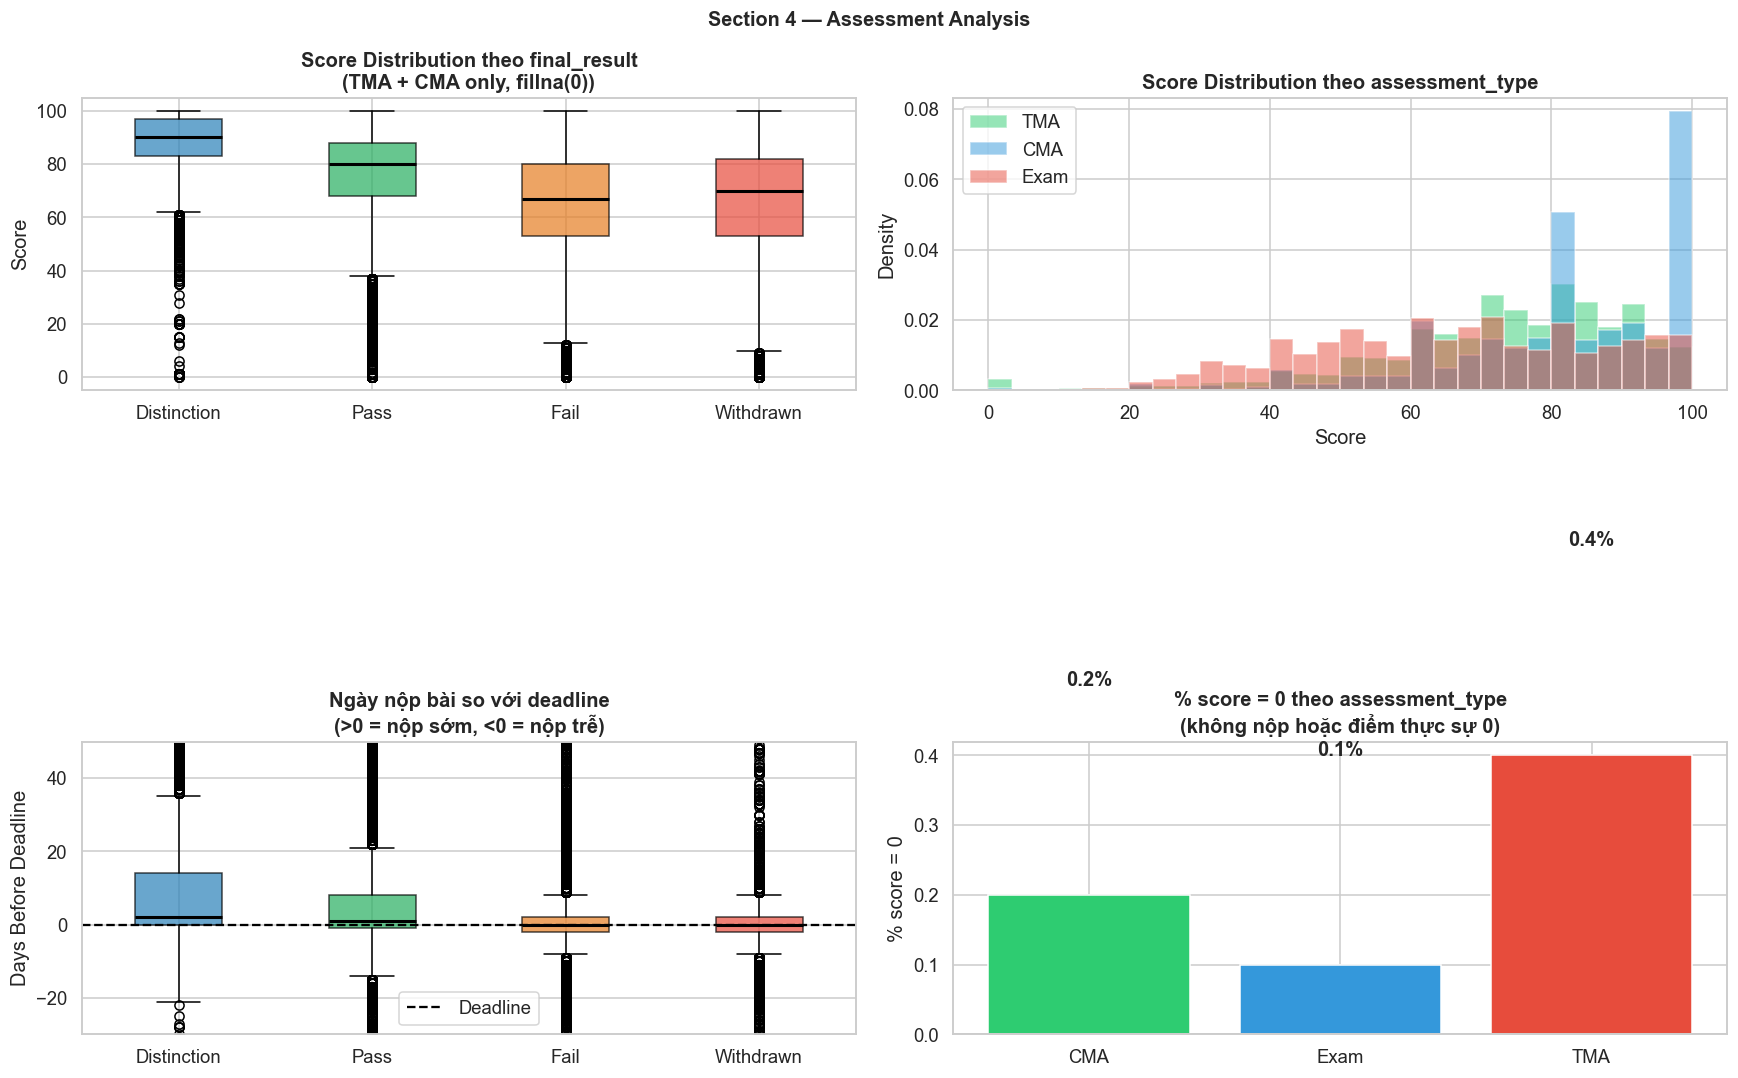

In [5]:
def section4_assessment_analysis():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')

    # Merge
    merged = (
        df_sa
        .merge(df_ass[['id_assessment','assessment_type','date','weight',
                        'code_module','code_presentation']], on='id_assessment', how='left')
        .merge(df_info[['id_student','code_module','code_presentation','final_result']],
               on=['id_student','code_module','code_presentation'], how='inner')
    )
    merged['score'] = merged['score'].fillna(0)
    merged['days_before_deadline'] = merged['date'] - merged['date_submitted']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Chart 1: Score boxplot by final_result
    merged_nonexam = merged[merged['assessment_type'] != 'Exam']
    data_by_result = [merged_nonexam[merged_nonexam['final_result'] == r]['score'].dropna()
                      for r in RESULT_ORDER]
    bp = axes[0][0].boxplot(data_by_result, labels=RESULT_ORDER, patch_artist=True,
                            medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], RESULT_CLIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0][0].set_title('Score Distribution theo final_result\n(TMA + CMA only, fillna(0))', fontweight='bold')
    axes[0][0].set_ylabel('Score')

    # Chart 2: Score boxplot by assessment_type
    for t, color in zip(['TMA', 'CMA', 'Exam'], ['#2ecc71', '#3498db', '#e74c3c']):
        sub = merged[merged['assessment_type'] == t]['score'].dropna()
        axes[0][1].hist(sub, bins=30, alpha=0.5, label=t, color=color, density=True)
    axes[0][1].set_title('Score Distribution theo assessment_type', fontweight='bold')
    axes[0][1].set_xlabel('Score')
    axes[0][1].set_ylabel('Density')
    axes[0][1].legend()

    # Chart 3: days_before_deadline boxplot
    data_days = [merged[merged['final_result'] == r]['days_before_deadline'].dropna()
                 for r in RESULT_ORDER]
    bp2 = axes[1][0].boxplot(data_days, labels=RESULT_ORDER, patch_artist=True,
                              medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp2['boxes'], RESULT_CLIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1][0].axhline(0, color='black', linestyle='--', linewidth=1.5, label='Deadline')
    axes[1][0].set_ylim(-30, 50)
    axes[1][0].set_title('Ngày nộp bài so với deadline\n(>0 = nộp sớm, <0 = nộp trễ)', fontweight='bold')
    axes[1][0].set_ylabel('Days Before Deadline')
    axes[1][0].legend()

    # Chart 4: submission rate by type
    type_counts = merged['assessment_type'].value_counts()
    null_by_type = (
        merged.groupby('assessment_type')['score']
        .apply(lambda x: (x == 0).mean() * 100).round(1)
        .rename('zero_score_pct').reset_index()
    )
    bars = axes[1][1].bar(null_by_type['assessment_type'], null_by_type['zero_score_pct'],
                          color=['#2ecc71', '#3498db', '#e74c3c'])
    for bar, val in zip(bars, null_by_type['zero_score_pct']):
        axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{val:.1f}%', ha='center', fontweight='bold')
    axes[1][1].set_title('% score = 0 theo assessment_type\n(không nộp hoặc điểm thực sự 0)', fontweight='bold')
    axes[1][1].set_ylabel('% score = 0')

    plt.suptitle('Section 4 — Assessment Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section4_assessment_analysis()

---
## Section 5 — Module Structure Audit

> **Không thể so sánh raw score cross-module.** Cấu trúc đánh giá hoàn toàn khác nhau.

| Module | CMA count | Exam weight | TMA weight | Đặc điểm |
|--------|-----------|-------------|------------|----------|
| AAA | 0 | 200 | 200 | Không có CMA |
| BBB | 15 | 400 | 385 | Nặng TMA |
| GGG | 18 | 300 | **0** | TMA **không tính điểm** |
| FFF | 28 | 400 | 400 | CMA nhiều nhất |

**GGG đặc biệt:** TMA weight = 0 → feature `weighted_score_from_TMA` vô nghĩa với module này.

**Hướng xử lý:**
- `code_module` là categorical feature — để model tự học distribution shift
- Tính `weighted_score` đúng công thức, không dùng `mean(score)`
- Normalize: `cma_submission_rate = n_submitted / n_safe_cma_in_module` — AAA/EEE fillna(0)

=== Module Duration (ngày) ===
             min   mean  max
code_module                 
AAA          268  268.5  269
BBB          234  251.0  268
CCC          241  255.0  269
DDD          240  251.0  262
EEE          241  259.3  269
FFF          240  254.5  269
GGG          241  257.0  269

=== Assessment Count per Module x Type ===
assessment_type  CMA  Exam  TMA
code_module                    
AAA                0     2   10
BBB               15     4   23
CCC                8     4    8
DDD                7     4   24
EEE                0     3   12
FFF               28     4   20
GGG               18     3    9

=== Total Weight (%) per Module x Type ===
assessment_type   CMA   Exam    TMA
code_module                        
AAA               0.0  200.0  200.0
BBB              15.0  400.0  385.0
CCC              50.0  400.0  150.0
DDD              25.0  400.0  375.0
EEE               0.0  300.0  300.0
FFF               0.0  400.0  400.0
GGG               0.0  300.0    0.0

=== Pas

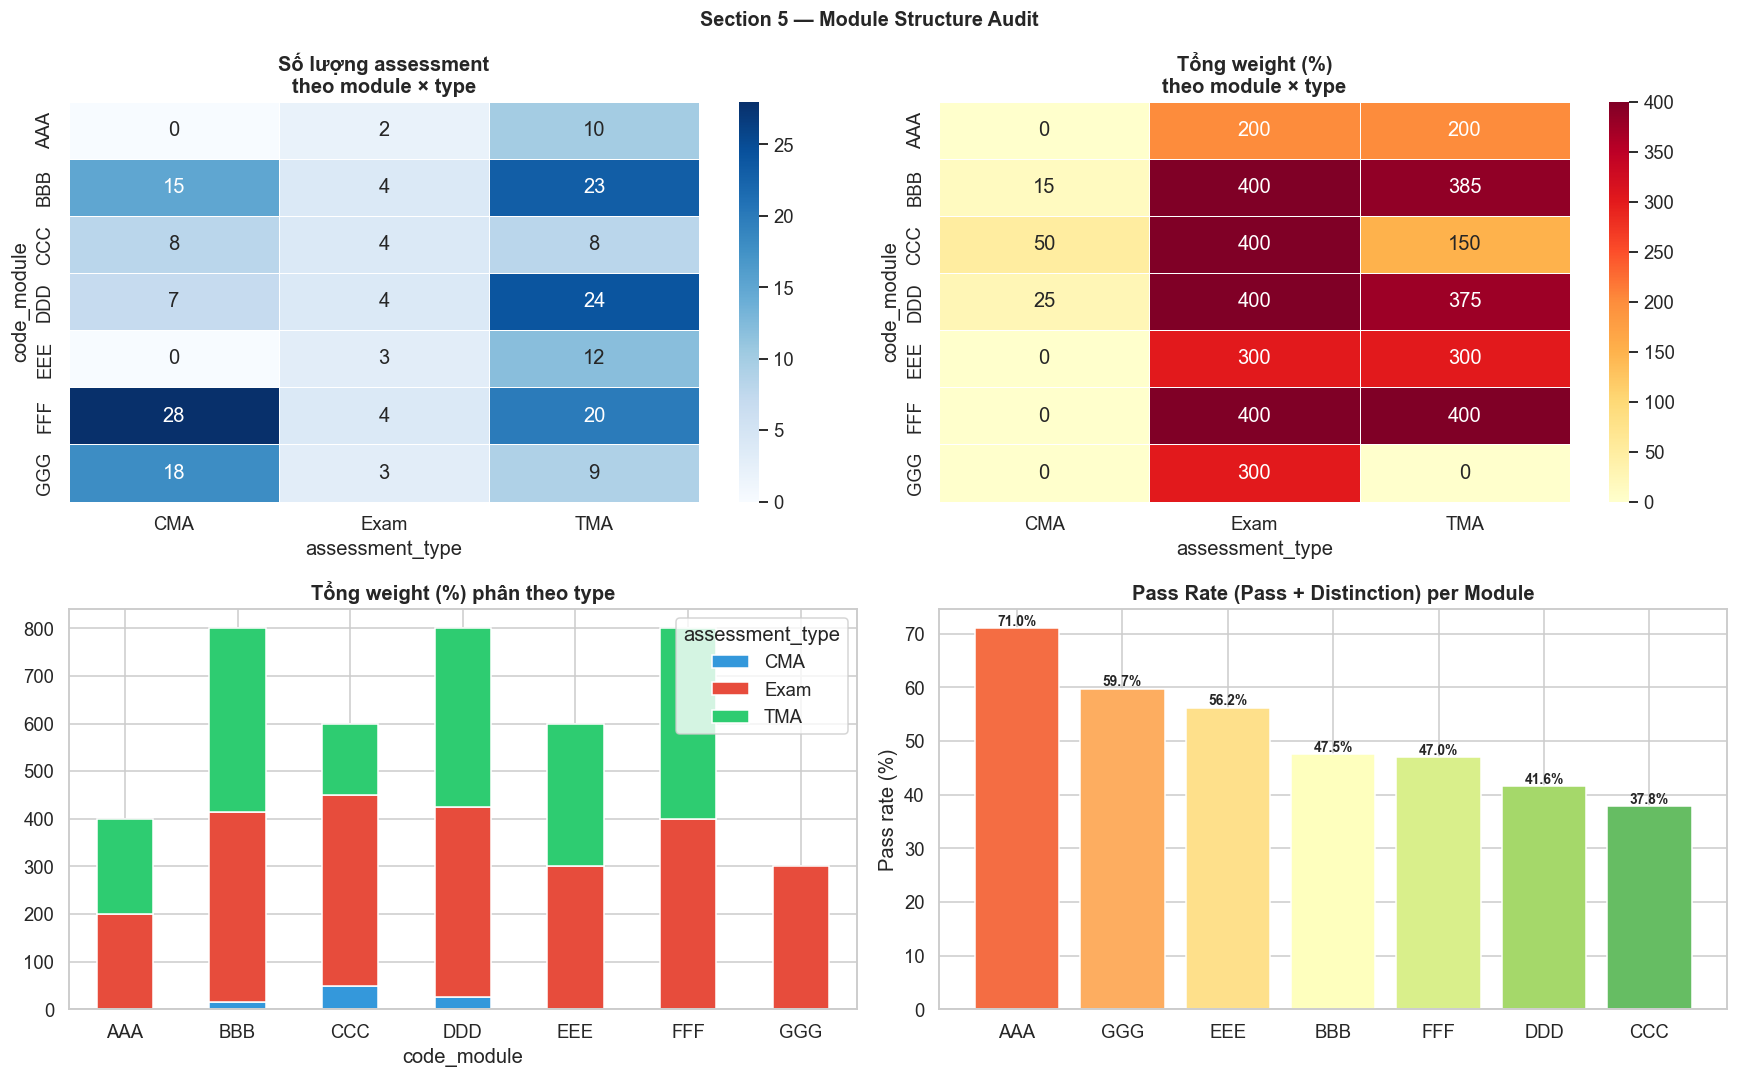

In [6]:
def section5_module_structure():
    df_ass = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs = pd.read_csv(DATA_DIR / 'courses.csv')
    df_info= pd.read_csv(DATA_DIR / 'studentInfo.csv')

    dur          = df_crs.groupby('code_module')['module_presentation_length'].agg(['min','mean','max']).round(1)
    pivot_count  = df_ass.groupby(['code_module','assessment_type'])['id_assessment'].count().unstack(fill_value=0)
    pivot_weight = df_ass.groupby(['code_module','assessment_type'])['weight'].sum().unstack(fill_value=0)
    pass_rate    = (
        df_info.assign(is_pass=lambda x: x['final_result'].isin(['Pass','Distinction']).astype(int))
        .groupby('code_module')['is_pass'].mean().mul(100).round(1)
        .rename('pass_rate_%')
    )

    print('=== Module Duration (ngày) ===')
    print(dur)
    print('\n=== Assessment Count per Module x Type ===')
    print(pivot_count)
    print('\n=== Total Weight (%) per Module x Type ===')
    print(pivot_weight)
    print('\n=== Pass Rate per Module ===')
    print(pass_rate)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, ax=axes[0][0])
    axes[0][0].set_title('Số lượng assessment\ntheo module × type', fontweight='bold')

    sns.heatmap(pivot_weight, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0][1])
    axes[0][1].set_title('Tổng weight (%)\ntheo module × type', fontweight='bold')

    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}
    pivot_weight.plot(kind='bar', stacked=True, ax=axes[1][0],
                      color=[type_colors.get(t,'gray') for t in pivot_weight.columns],
                      edgecolor='white')
    axes[1][0].set_title('Tổng weight (%) phân theo type', fontweight='bold')
    axes[1][0].tick_params(axis='x', rotation=0)

    pass_rate_sorted = pass_rate.sort_values(ascending=False)
    colors_module    = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pass_rate_sorted)))
    bars = axes[1][1].bar(pass_rate_sorted.index, pass_rate_sorted.values, color=colors_module)
    for bar, val in zip(bars, pass_rate_sorted.values):
        axes[1][1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[1][1].set_title('Pass Rate (Pass + Distinction) per Module', fontweight='bold')
    axes[1][1].set_ylabel('Pass rate (%)')

    plt.suptitle('Section 5 — Module Structure Audit', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section5_module_structure()

---
## Section 6 — Presentation Effect (B vs J)

Kỳ **B** (tháng 2) và kỳ **J** (tháng 10) có pass rate khác nhau.

| Semester | Pass rate | n_students |
|----------|-----------|-----------|
| B (Feb) | 43.67% | 12,488 |
| J (Oct) | 49.40% | 20,105 |

Chênh lệch **không đồng đều giữa modules** (CCC và EEE chênh >6pp) → `semester` phải là feature.

```python
# Feature engineering
df['semester'] = df['code_presentation'].str[-1]          # 'B' hoặc 'J'
df['module_semester'] = df['code_module'] + '_' + df['semester']  # interaction term
```

=== Pass rate theo semester ===
          pass_rate  n_students
semester                       
B             43.67       12488
J             49.40       20105

=== Pass rate per module x semester ===
semester         B      J  diff_B_minus_J
code_module                              
AAA            NaN  70.99             NaN
BBB          45.27  49.11           -3.84
CCC          34.25  40.63           -6.38
DDD          39.08  43.33           -4.25
EEE          51.44  57.72           -6.28
FFF          46.11  47.59           -1.48
GGG          57.38  60.91           -3.53


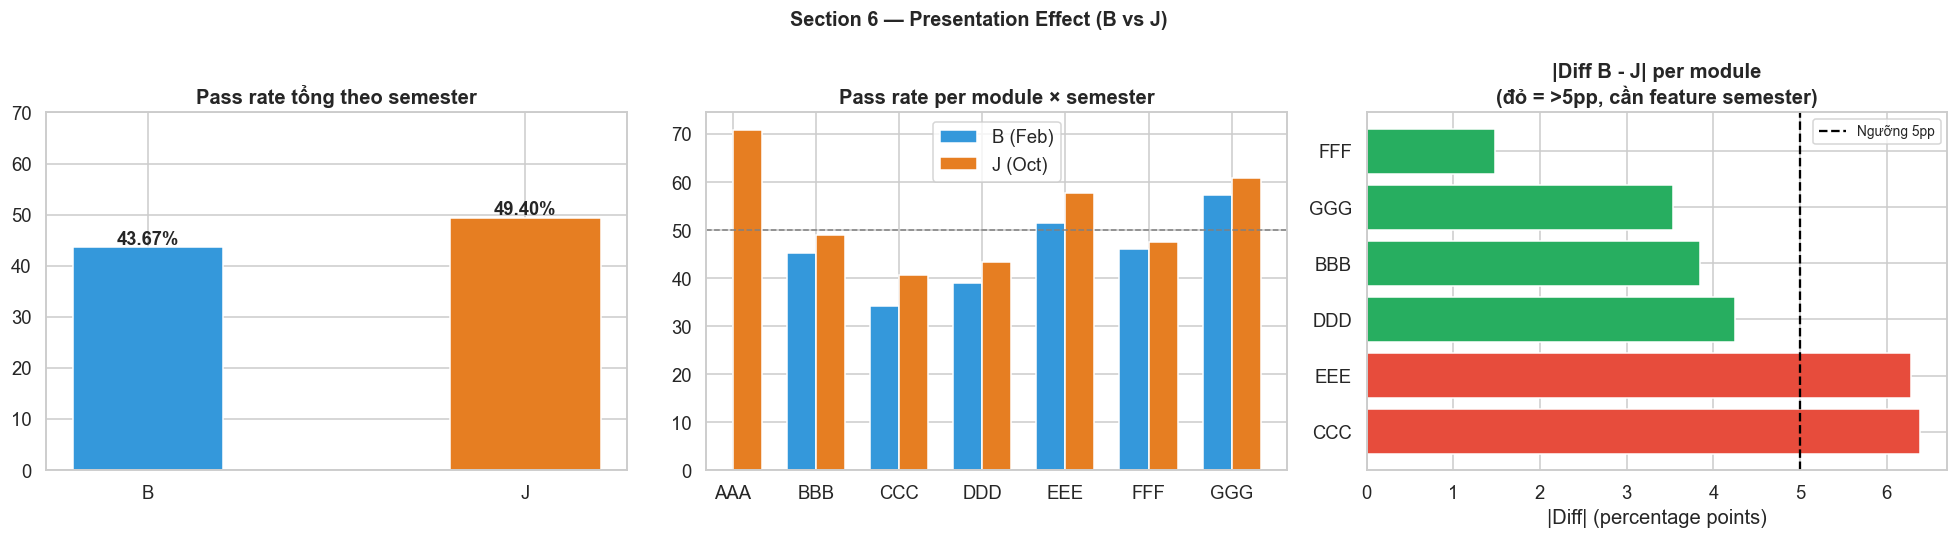

In [7]:
def section6_presentation_effect():
    df = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df['semester'] = df['code_presentation'].str[-1]
    df['is_pass']  = df['final_result'].isin(['Pass','Distinction']).astype(int)

    overall = (
        df.groupby('semester')['is_pass']
        .agg(['mean','count'])
        .rename(columns={'mean':'pass_rate','count':'n_students'})
    )
    overall['pass_rate'] = overall['pass_rate'].mul(100).round(2)

    per_module = (
        df.groupby(['code_module','semester'])['is_pass']
        .mean().mul(100).round(2).unstack()
    )
    if 'B' in per_module.columns and 'J' in per_module.columns:
        per_module['diff_B_minus_J'] = (per_module['B'] - per_module['J']).round(2)

    print('=== Pass rate theo semester ===')
    print(overall)
    print('\n=== Pass rate per module x semester ===')
    print(per_module.to_string())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sem_colors = {'B':'#3498db','J':'#e67e22'}
    bars = axes[0].bar(overall.index, overall['pass_rate'],
                       color=[sem_colors.get(s,'gray') for s in overall.index],
                       width=0.4, edgecolor='white')
    for bar, val in zip(bars, overall['pass_rate']):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.2f}%', ha='center', fontweight='bold', fontsize=12)
    axes[0].set_title('Pass rate tổng theo semester', fontweight='bold')
    axes[0].set_ylim(0, 70)

    if 'B' in per_module.columns and 'J' in per_module.columns:
        x = np.arange(len(per_module))
        w = 0.35
        axes[1].bar(x - w/2, per_module['B'], w, label='B (Feb)', color='#3498db', edgecolor='white')
        axes[1].bar(x + w/2, per_module['J'], w, label='J (Oct)', color='#e67e22', edgecolor='white')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(per_module.index)
        axes[1].set_title('Pass rate per module × semester', fontweight='bold')
        axes[1].legend()
        axes[1].axhline(50, color='gray', linestyle='--', linewidth=1)

        diff_abs = per_module['diff_B_minus_J'].abs().sort_values(ascending=False)
        colors_diff = ['#e74c3c' if abs(v) > 5 else '#27ae60' for v in diff_abs]
        bars3 = axes[2].barh(diff_abs.index, diff_abs.values, color=colors_diff)
        axes[2].axvline(5, color='black', linestyle='--', linewidth=1.5, label='Ngưỡng 5pp')
        axes[2].set_title('|Diff B - J| per module\n(đỏ = >5pp, cần feature semester)', fontweight='bold')
        axes[2].set_xlabel('|Diff| (percentage points)')
        axes[2].legend(fontsize=9)

    plt.suptitle('Section 6 — Presentation Effect (B vs J)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section6_presentation_effect()

---
## Section 7 — Data-Driven Cut-off Selection

Cut-off day là tham số quan trọng nhất của Early Warning System.
**Phải chọn từ data**, không được assume.

**Logic:** Chọn cut-off nhỏ nhất sao cho:
- Capture ≥ 80% Withdrawn (đủ để train model nhận biết Withdrawn)
- Còn đủ thời gian can thiệp sau cut-off

**Kết quả: cut-off = day 135** (~50% module length)
- Capture ~80% Withdrawn
- Còn ~126 ngày để can thiệp

Median module length : 262 ngày
Cut-off ≥80% Withdrawn: day 135 (51.6% module)
Cut-off ≥90% Withdrawn: day 175 (66.9% module)

→ Chọn CUTOFF_DAY = 135 (≥80%, còn 48% module để can thiệp)


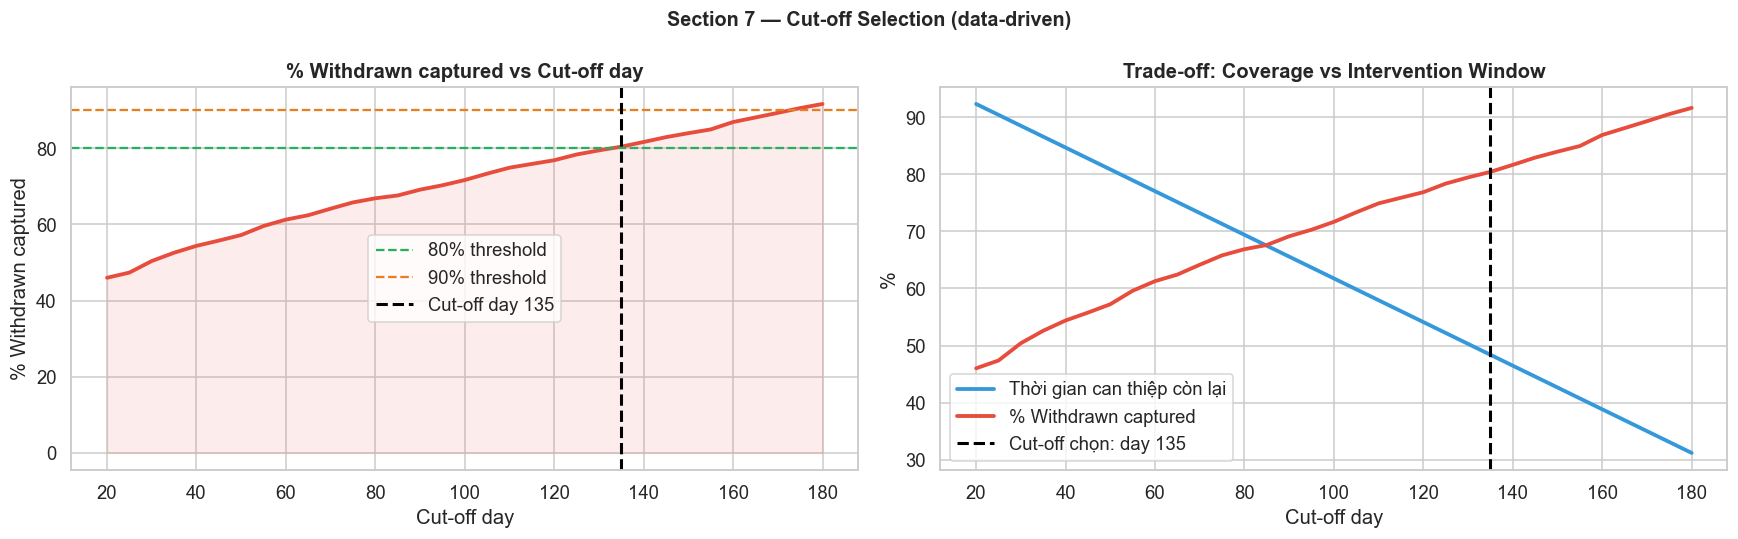

In [8]:
def section7_cutoff_selection():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_reg
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_crs, on=['code_module','code_presentation'], how='left')
    )

    withdrawn = merged[merged['final_result'] == 'Withdrawn'].copy()
    total_w   = len(withdrawn)
    med_len   = df_crs['module_presentation_length'].median()

    cutoffs = range(20, 181, 5)
    records = []
    for c in cutoffs:
        n_captured = (withdrawn['date_unregistration'] <= c).sum()
        records.append({
            'cutoff_day': c,
            'pct_withdrawn': n_captured / total_w * 100,
            'remaining_pct': (1 - c / med_len) * 100,
        })
    df_co = pd.DataFrame(records)

    co_80 = df_co[df_co['pct_withdrawn'] >= 80]['cutoff_day'].min()
    co_90 = df_co[df_co['pct_withdrawn'] >= 90]['cutoff_day'].min()

    print(f'Median module length : {med_len:.0f} ngày')
    print(f'Cut-off ≥80% Withdrawn: day {co_80} ({co_80/med_len*100:.1f}% module)')
    print(f'Cut-off ≥90% Withdrawn: day {co_90} ({co_90/med_len*100:.1f}% module)')
    print(f'\n→ Chọn CUTOFF_DAY = {CUTOFF_DAY} (≥80%, còn {100-CUTOFF_DAY/med_len*100:.0f}% module để can thiệp)')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(df_co['cutoff_day'], df_co['pct_withdrawn'],
                 color='#e74c3c', linewidth=2.5)
    axes[0].axhline(80, color='#27ae60', linestyle='--', linewidth=1.5, label='80% threshold')
    axes[0].axhline(90, color='#e67e22', linestyle='--', linewidth=1.5, label='90% threshold')
    axes[0].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {CUTOFF_DAY}')
    axes[0].fill_between(df_co['cutoff_day'], df_co['pct_withdrawn'], alpha=0.1, color='#e74c3c')
    axes[0].set_title('% Withdrawn captured vs Cut-off day', fontweight='bold')
    axes[0].set_xlabel('Cut-off day')
    axes[0].set_ylabel('% Withdrawn captured')
    axes[0].legend()

    axes[1].plot(df_co['cutoff_day'], df_co['remaining_pct'],
                 color='#3498db', linewidth=2.5, label='Thời gian can thiệp còn lại')
    axes[1].plot(df_co['cutoff_day'], df_co['pct_withdrawn'],
                 color='#e74c3c', linewidth=2.5, label='% Withdrawn captured')
    axes[1].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off chọn: day {CUTOFF_DAY}')
    axes[1].set_title('Trade-off: Coverage vs Intervention Window', fontweight='bold')
    axes[1].set_xlabel('Cut-off day')
    axes[1].set_ylabel('%')
    axes[1].legend()

    plt.suptitle('Section 7 — Cut-off Selection (data-driven)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section7_cutoff_selection()

---
## Section 8 — Leakage Audit (tại cut-off = day 135)

**Dùng toàn bộ `studentAssessment` = data leakage.** Exam cuối kỳ luôn xảy ra sau cut-off.

| Type | SAFE (≤135) | LEAKAGE (>135) | Quyết định |
|------|-------------|-----------------|-----------|
| TMA | **71** | 35 | ✅ Dùng — majority safe |
| CMA | 17 | **59** | ⚠️ Dùng thận trọng — normalize per module |
| Exam | 0 | **6** | ❌ Không dùng tuyệt đối |

**Lỗi phổ biến với CMA:**
```python
# SAI — đếm tuyệt đối
n_cma_submitted = 3

# ĐÚNG — tỉ lệ so với available trong module tại cut-off
cma_submission_rate = n_submitted / n_safe_cma_available_in_module
# AAA/EEE không có CMA → fillna(0) hoặc -1
```

=== Assessment SAFE vs LEAKAGE at cut-off day 135 ===
is_safe          LEAKAGE  SAFE (≤day 135)
assessment_type                          
CMA                   59               17
Exam                   6                0
TMA                   35               71

=== Submit ratio stats ===
                   count   mean    std    min    25%    50%    75%    max
assessment_type                                                          
CMA              70527.0  0.546  0.280 -0.033  0.286  0.577  0.804  2.475
Exam              4959.0  0.935  0.025  0.903  0.908  0.927  0.954  1.104
TMA              98426.0  0.366  0.238 -0.047  0.158  0.353  0.565  1.075


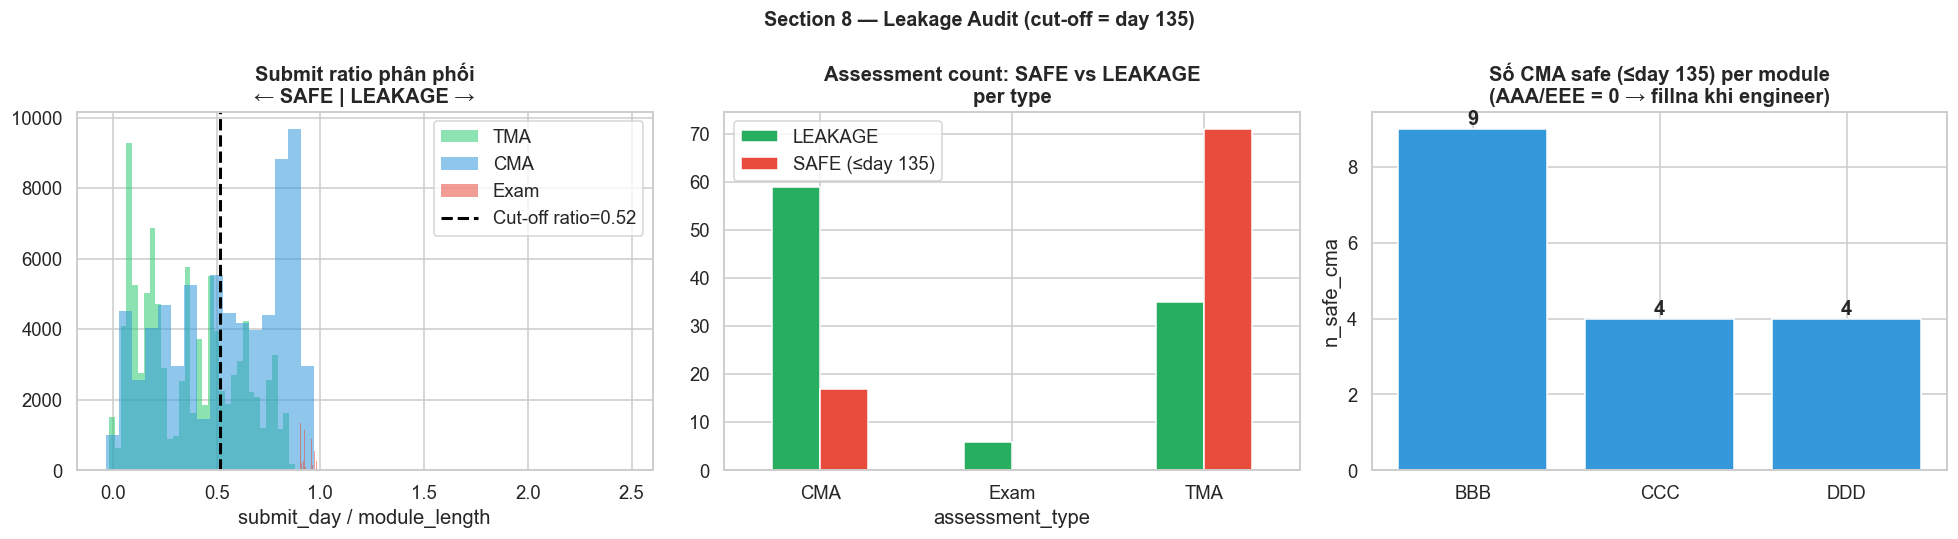

In [9]:
def section8_leakage_audit(cutoff_day=CUTOFF_DAY):
    df_sa  = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_ass = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_crs = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_sa
        .merge(df_ass, on='id_assessment')
        .merge(df_crs, on=['code_module','code_presentation'])
    )
    merged['submit_ratio']   = merged['date_submitted'] / merged['module_presentation_length']
    merged['deadline_ratio'] = merged['date']           / merged['module_presentation_length']
    merged['is_safe']        = merged['date'] <= cutoff_day

    safe_tbl = (
        merged.groupby(['assessment_type','is_safe'])['id_assessment']
        .nunique().unstack(fill_value=0)
        .rename(columns={True: f'SAFE (≤day {cutoff_day})', False: 'LEAKAGE'})
    )
    print(f'=== Assessment SAFE vs LEAKAGE at cut-off day {cutoff_day} ===')
    print(safe_tbl)
    print('\n=== Submit ratio stats ===')
    print(merged.groupby('assessment_type')['submit_ratio'].describe().round(3))

    type_colors = {'CMA':'#3498db', 'Exam':'#e74c3c', 'TMA':'#2ecc71'}
    cutoff_ratio = cutoff_day / df_crs['module_presentation_length'].median()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Chart 1: submit_ratio histogram
    for t in ['TMA', 'CMA', 'Exam']:
        sub = merged[merged['assessment_type'] == t]['submit_ratio'].dropna()
        axes[0].hist(sub, bins=40, alpha=0.55, label=t,
                     color=type_colors[t], edgecolor='none')
    axes[0].axvline(cutoff_ratio, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off ratio={cutoff_ratio:.2f}')
    axes[0].set_title(f'Submit ratio phân phối\n← SAFE | LEAKAGE →', fontweight='bold')
    axes[0].set_xlabel('submit_day / module_length')
    axes[0].legend()

    # Chart 2: safe count stacked
    safe_tbl.plot(kind='bar', stacked=False, ax=axes[1],
                  color=['#27ae60','#e74c3c'], edgecolor='white')
    axes[1].set_title('Assessment count: SAFE vs LEAKAGE\nper type', fontweight='bold')
    axes[1].set_xticklabels(safe_tbl.index, rotation=0)
    axes[1].legend()

    # Chart 3: safe CMA per module
    safe_cma = (
        merged[(merged['assessment_type'] == 'CMA') & (merged['is_safe'])]
        .groupby('code_module')['id_assessment'].nunique()
        .reset_index().rename(columns={'id_assessment': 'n_safe_cma'})
    )
    bars = axes[2].bar(safe_cma['code_module'], safe_cma['n_safe_cma'],
                       color='#3498db', edgecolor='white')
    for bar, val in zip(bars, safe_cma['n_safe_cma']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                     str(val), ha='center', fontweight='bold')
    axes[2].set_title(f'Số CMA safe (≤day {cutoff_day}) per module\n(AAA/EEE = 0 → fillna khi engineer)', fontweight='bold')
    axes[2].set_ylabel('n_safe_cma')

    plt.suptitle(f'Section 8 — Leakage Audit (cut-off = day {cutoff_day})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section8_leakage_audit()

---
## Section 9 — VLE Time-series Analysis

> **Core argument:** `sum_click` tổng là feature kém.
> 1000 clicks ngày 1 rồi biến mất ≠ 10 clicks/ngày đều trong 100 ngày.

**Temporal features cần tạo (tất cả chỉ tính trong ≤ cut-off):**
```python
active_days          # số ngày có ≥1 click
clicks_per_week_1..N # clicks từng tuần  
last_active_day      # recency — Withdrawn dừng sớm = feature mạnh
std_clicks           # độ đều đặn
clicks_by_activity   # oucontent, forumng, quiz — high-signal
```

**Patterns quan sát được:**
- **Withdrawn:** dense activity đầu khóa → dừng đột ngột trước cut-off
- **Fail:** "nước tới chân mới nhảy" — spike cuối kỳ nhưng quá muộn  
- **Distinction/Pass:** activity đều đặn suốt module, tăng nhẹ quanh deadline

Loading studentVle.csv...


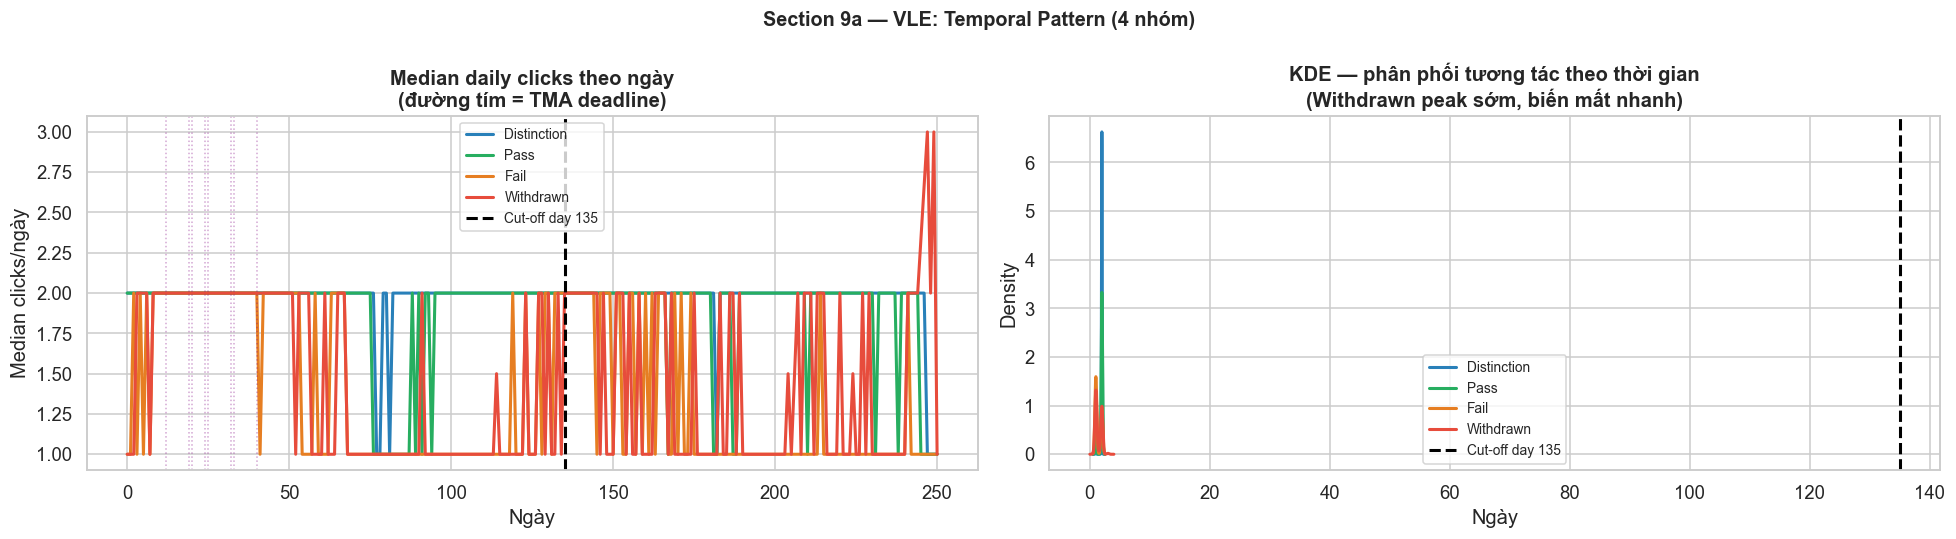

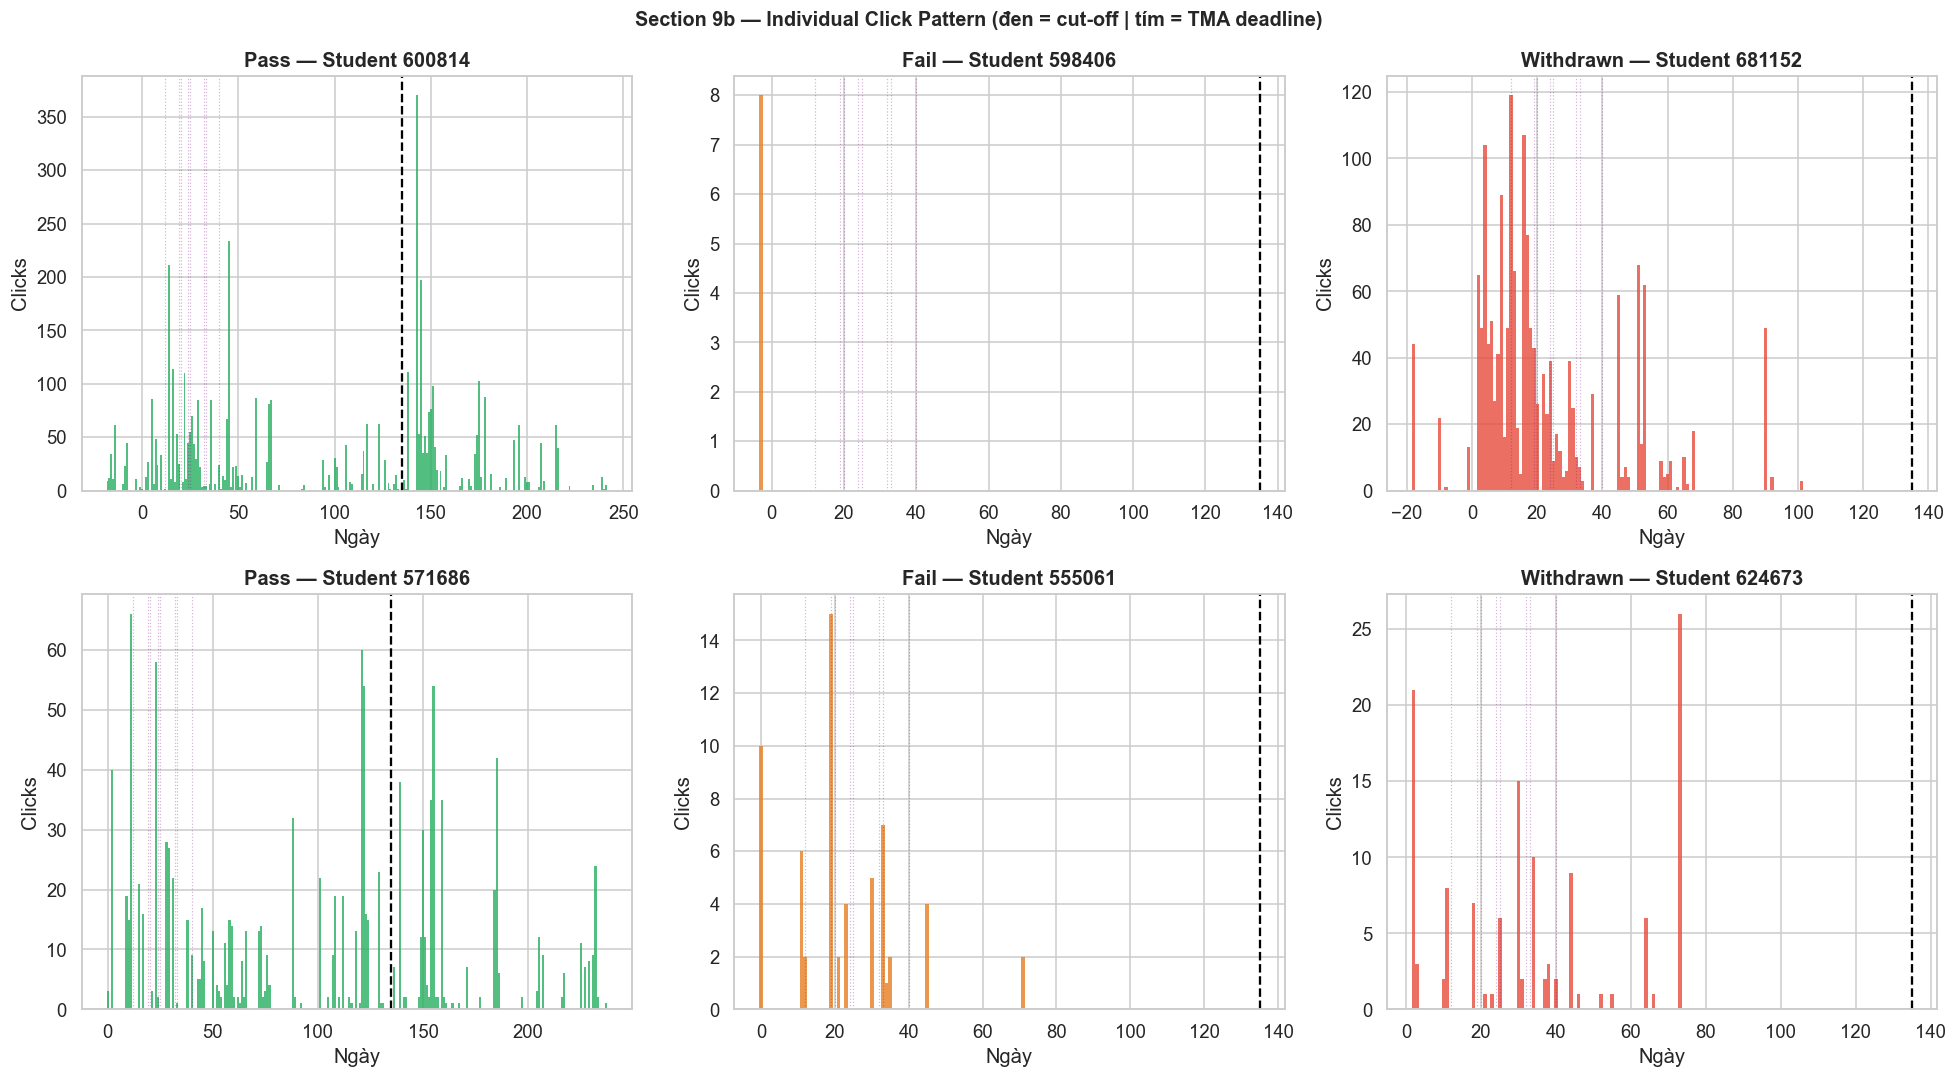

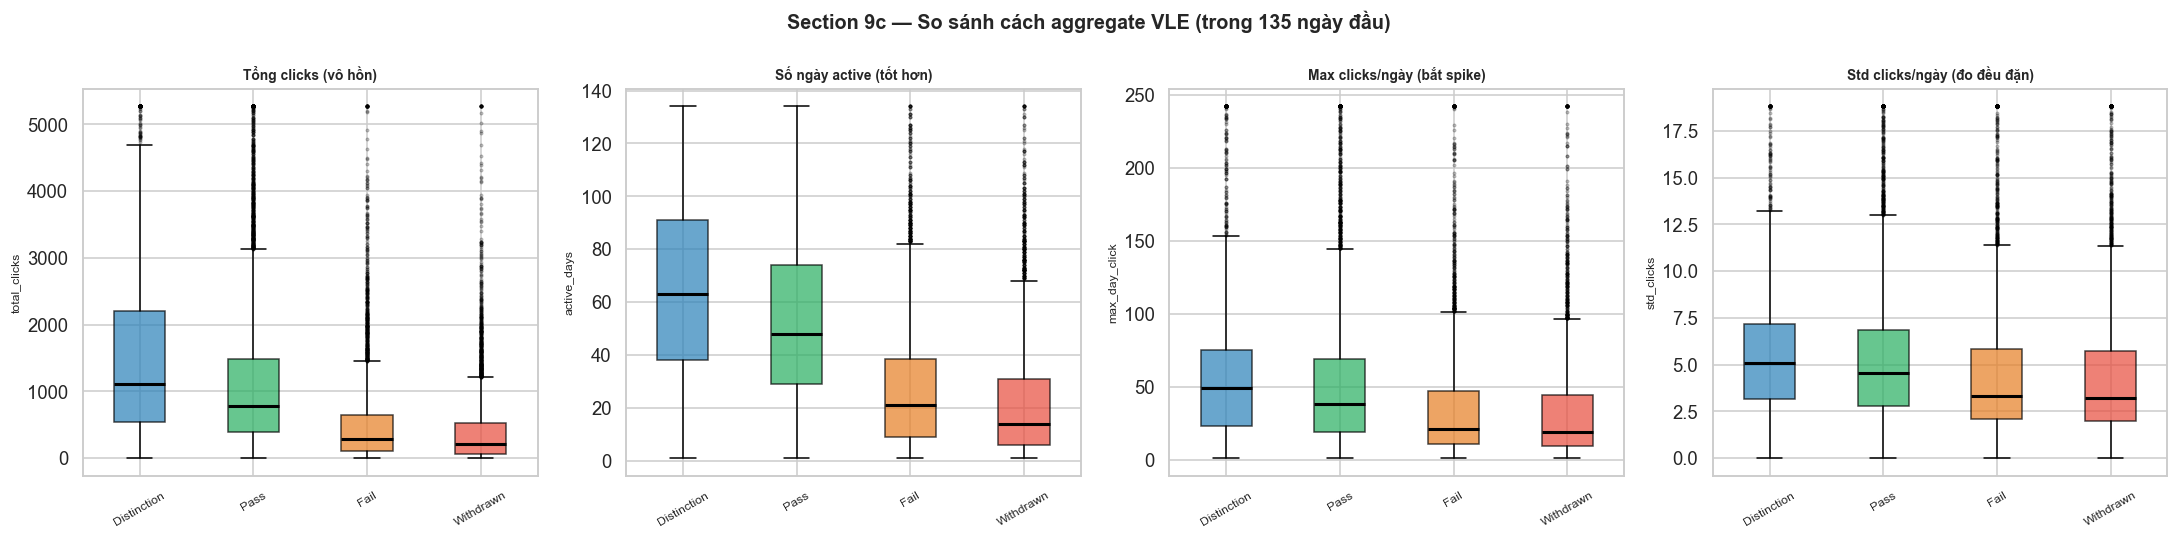

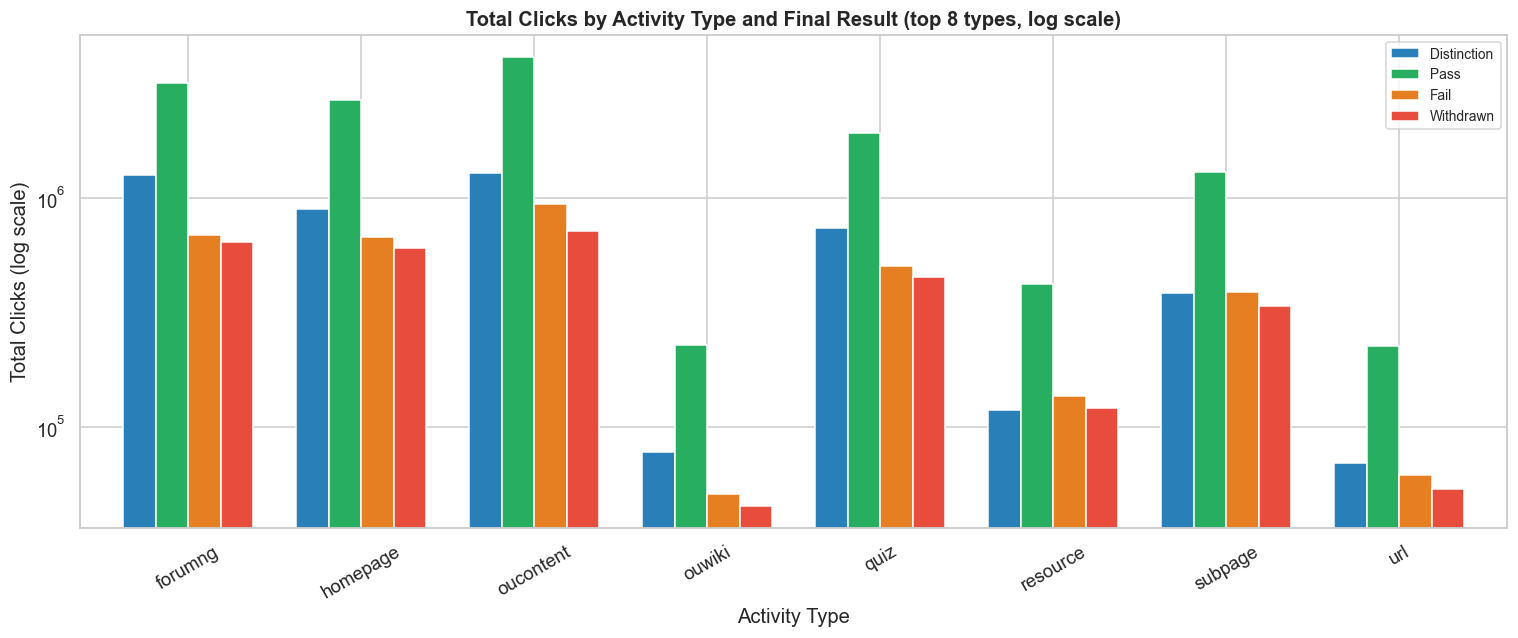


=== Kết luận Section 9 ===
→ Withdrawn: KDE peak ở ngày đầu → biến mất trước cut-off
→ Pass/Distinction: activity đều đặn suốt module
→ KHÔNG dùng sum_click tổng — cần temporal features:
   active_days, std_clicks, last_active_day, clicks_per_week


In [10]:
def section9_vle_timeseries(cutoff_day=CUTOFF_DAY):
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_ass  = pd.read_csv(DATA_DIR / 'assessments.csv')
    df_vle_raw = pd.read_csv(DATA_DIR / 'vle.csv')

    print('Loading studentVle.csv...')
    df_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    del df_vle

    tma_dates = df_ass[df_ass['assessment_type'] == 'TMA']['date'].sort_values().unique()[:8]

    # ── Section 9a: Median daily clicks — 4 nhóm ─────────────────────────
    daily = (
        vle[vle['date'].between(0, 250)]
        .groupby(['final_result','date'])['sum_click']
        .median().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    for res in RESULT_ORDER:
        g = daily[daily['final_result'] == res]
        axes[0].plot(g['date'], g['sum_click'],
                     label=res, color=RESULT_COLORS[res], linewidth=2)
    axes[0].axvline(cutoff_day, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}')
    for d in tma_dates:
        if d <= 250:
            axes[0].axvline(d, color='purple', linestyle=':', alpha=0.35, linewidth=1)
    axes[0].set_title('Median daily clicks theo ngày\n(đường tím = TMA deadline)', fontweight='bold')
    axes[0].set_xlabel('Ngày')
    axes[0].set_ylabel('Median clicks/ngày')
    axes[0].legend(fontsize=9)

    # KDE phân phối theo thời gian
    vle_cut = vle[vle['date'].between(0, 250)].copy()
    for res in RESULT_ORDER:
        g = vle_cut[vle_cut['final_result'] == res]
        g.groupby('date')['sum_click'].median().plot.kde(
            ax=axes[1], label=res, color=RESULT_COLORS[res], linewidth=2)
    axes[1].axvline(cutoff_day, color='black', linestyle='--', linewidth=2,
                    label=f'Cut-off day {cutoff_day}')
    axes[1].set_title('KDE — phân phối tương tác theo thời gian\n(Withdrawn peak sớm, biến mất nhanh)', fontweight='bold')
    axes[1].set_xlabel('Ngày')
    axes[1].set_ylabel('Density')
    axes[1].legend(fontsize=9)

    plt.suptitle('Section 9a — VLE: Temporal Pattern (4 nhóm)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Section 9b: Individual click patterns ─────────────────────────────
    np.random.seed(RANDOM_STATE)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    sample_students = {}
    for i, res in enumerate(RESULT_ORDER[:3]):
        ids = vle[vle['final_result'] == res]['id_student'].unique()
        student_id = np.random.choice(ids)
        sample_students[res] = student_id

    # 2 students per group shown
    for row, offset in enumerate([0, 1]):
        for col, res in enumerate(['Pass', 'Fail', 'Withdrawn']):
            ax = axes[row][col]
            ids = vle[vle['final_result'] == res]['id_student'].unique()
            np.random.seed(RANDOM_STATE + offset * 10 + col)
            student_id = np.random.choice(ids)
            sv = vle[(vle['id_student'] == student_id) & (vle['date'].between(-30, 270))]
            sv = sv.groupby('date')['sum_click'].sum().reset_index()
            ax.bar(sv['date'], sv['sum_click'], width=1.0,
                   color=RESULT_COLORS[res], alpha=0.8, edgecolor='none')
            ax.axvline(cutoff_day, color='black', linestyle='--', linewidth=1.5)
            for d in tma_dates:
                if -30 <= d <= 270:
                    ax.axvline(d, color='purple', linestyle=':', alpha=0.3, linewidth=0.8)
            ax.set_title(f'{res} — Student {student_id}', fontweight='bold')
            ax.set_xlabel('Ngày')
            ax.set_ylabel('Clicks')

    plt.suptitle('Section 9b — Individual Click Pattern (đen = cut-off | tím = TMA deadline)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Section 9c: Aggregate comparison ─────────────────────────────────
    vle_before = vle[vle['date'] <= cutoff_day]
    agg = (
        vle_before.groupby(['code_module','code_presentation','id_student','final_result'])
        .agg(
            total_clicks=('sum_click', 'sum'),
            active_days=('date', 'nunique'),
            max_day_click=('sum_click', 'max'),
            std_clicks=('sum_click', 'std'),
        ).reset_index()
        .fillna(0)
    )

    metrics = {
        'total_clicks': 'Tổng clicks (vô hồn)',
        'active_days': 'Số ngày active (tốt hơn)',
        'max_day_click': 'Max clicks/ngày (bắt spike)',
        'std_clicks': 'Std clicks/ngày (đo đều đặn)',
    }

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (col, title) in zip(axes, metrics.items()):
        data_by_res = [agg[agg['final_result'] == r][col].clip(upper=agg[col].quantile(0.99))
                       for r in RESULT_ORDER]
        bp = ax.boxplot(data_by_res, labels=RESULT_ORDER, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', alpha=0.3, markersize=3))
        for patch, color in zip(bp['boxes'], RESULT_CLIST):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_title(title, fontweight='bold', fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.set_ylabel(col, fontsize=8)

    plt.suptitle(f'Section 9c — So sánh cách aggregate VLE (trong {cutoff_day} ngày đầu)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Section 9d: Activity type breakdown ───────────────────────────────
    vle_with_type = vle_before.merge(df_vle_raw[['id_site','activity_type']], on='id_site', how='left')
    activity_agg = (
        vle_with_type.groupby(['activity_type','final_result'])['sum_click']
        .sum().reset_index()
    )

    top_activities = (
        activity_agg.groupby('activity_type')['sum_click'].sum()
        .sort_values(ascending=False).head(8).index
    )
    activity_top = activity_agg[activity_agg['activity_type'].isin(top_activities)]

    fig, ax = plt.subplots(figsize=(14, 6))
    activity_pivot = activity_top.pivot(index='activity_type', columns='final_result', values='sum_click').fillna(0)
    activity_pivot = activity_pivot.reindex(columns=RESULT_ORDER)
    activity_pivot.plot(kind='bar', ax=ax,
                        color=RESULT_CLIST, edgecolor='white', width=0.75)
    ax.set_yscale('log')
    ax.set_title('Total Clicks by Activity Type and Final Result (top 8 types, log scale)',
                 fontweight='bold')
    ax.set_xlabel('Activity Type')
    ax.set_ylabel('Total Clicks (log scale)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('\n=== Kết luận Section 9 ===')
    print('→ Withdrawn: KDE peak ở ngày đầu → biến mất trước cut-off')
    print('→ Pass/Distinction: activity đều đặn suốt module')
    print('→ KHÔNG dùng sum_click tổng — cần temporal features:')
    print('   active_days, std_clicks, last_active_day, clicks_per_week')

section9_vle_timeseries()

---
## Section 10 — Statistical Tests (Chi-square + Spearman)

Kiểm định toàn bộ features để justify quyết định giữ/drop.

=== Chi-square Test: Categorical vs final_result ===
          feature        chi2       p_value significance
      code_module 1443.193244 7.589955e-296     *** Mạnh
highest_education 1024.696199 9.182113e-212     *** Mạnh
         imd_band  666.935197 3.150931e-123     *** Mạnh
           region  449.715132  6.470404e-73     *** Mạnh
code_presentation  402.161774  4.736105e-81     *** Mạnh
         age_band  222.650798  2.831091e-45     *** Mạnh
       disability  138.453987  8.143196e-30     *** Mạnh
           gender   16.530150  8.827204e-04     *** Mạnh


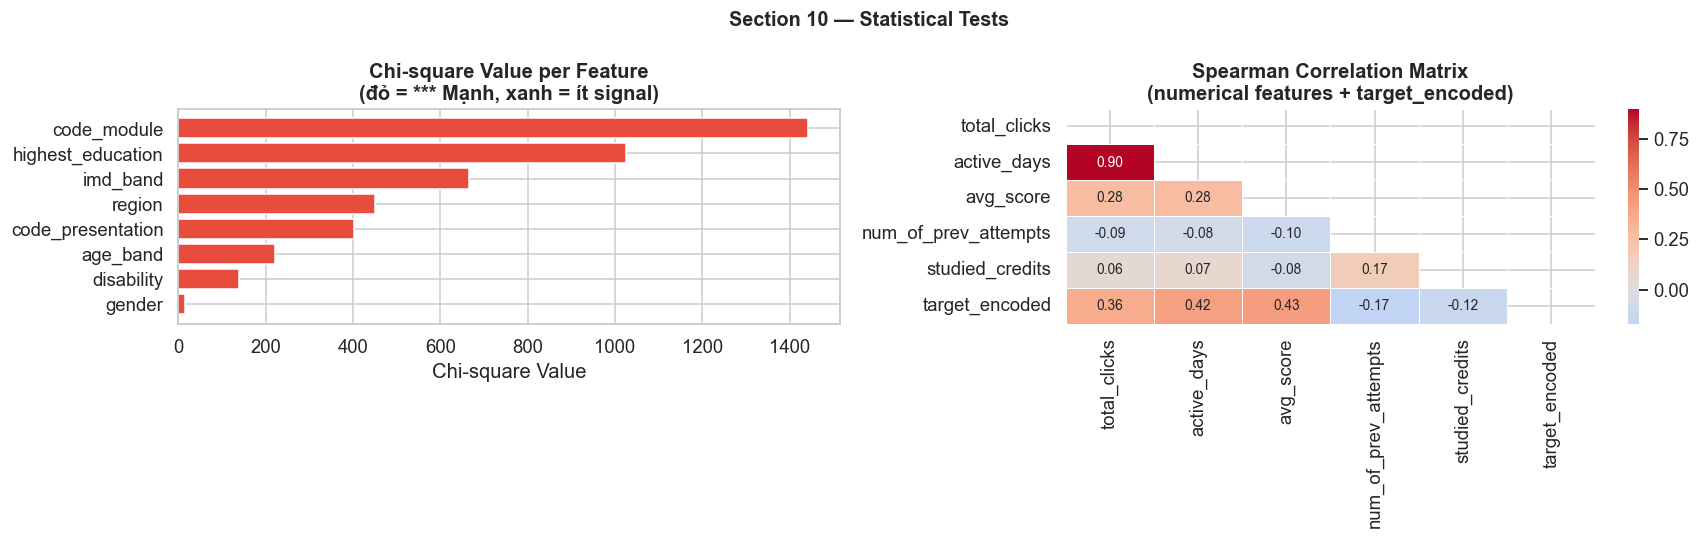

In [11]:
def section10_statistical_tests():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_sa   = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    # ── Chi-square: categorical features ─────────────────────────────────
    categorical_cols = ['gender', 'region', 'highest_education', 'imd_band',
                        'age_band', 'disability', 'code_module', 'code_presentation']

    chi_results = []
    for col in categorical_cols:
        df_clean = df_info.dropna(subset=[col])
        chi2, p, _ = chi_square_test(df_clean, col, 'final_result')
        sig = '*** Mạnh' if p < 0.001 else ('** Có ý nghĩa' if p < 0.05 else '✗ Không có ý nghĩa')
        chi_results.append({'feature': col, 'chi2': chi2, 'p_value': p, 'significance': sig})

    chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
    print('=== Chi-square Test: Categorical vs final_result ===')
    print(chi_df.to_string(index=False))

    # ── Spearman: numerical features ─────────────────────────────────────
    # VLE aggregates
    vle_merged = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    vle_before = vle_merged[vle_merged['date'] <= CUTOFF_DAY]
    agg_vle = (
        vle_before.groupby(['id_student','final_result'])
        .agg(total_clicks=('sum_click','sum'), active_days=('date','nunique'))
        .reset_index()
    )

    # Score aggregates
    df_sa_clean = df_sa.fillna({'score': 0})
    agg_score = df_sa_clean.groupby('id_student')['score'].mean().reset_index().rename(columns={'score':'avg_score'})

    # Merge all
    num_df = agg_vle.merge(agg_score, on='id_student', how='left')
    num_df = num_df.merge(df_info[['id_student','num_of_prev_attempts','studied_credits']], on='id_student', how='left')

    target_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
    num_df['target_encoded'] = num_df['final_result'].map(target_map)

    num_cols = ['total_clicks', 'active_days', 'avg_score', 'num_of_prev_attempts',
                'studied_credits', 'target_encoded']
    corr_data = num_df[num_cols].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Chi-square barplot
    chi_df_sorted = chi_df.sort_values('chi2', ascending=True)
    colors_chi = ['#e74c3c' if 'Mạnh' in s else '#27ae60' for s in chi_df_sorted['significance']]
    axes[0].barh(chi_df_sorted['feature'], chi_df_sorted['chi2'], color=colors_chi)
    axes[0].set_title('Chi-square Value per Feature\n(đỏ = *** Mạnh, xanh = ít signal)', fontweight='bold')
    axes[0].set_xlabel('Chi-square Value')

    # Spearman heatmap
    corr_matrix = corr_data.corr(method='spearman')
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=axes[1], mask=mask,
                annot_kws={'size': 9})
    axes[1].set_title('Spearman Correlation Matrix\n(numerical features + target_encoded)', fontweight='bold')

    plt.suptitle('Section 10 — Statistical Tests', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

section10_statistical_tests()

---
## Summary — Feature Engineering Decisions

### DROP — không bàn cãi

| Feature/Data | Lý do |
|--------------|-------|
| `date_unregistration` | 99.1% Withdrawn có giá trị → proxy của label → **leakage 100%** |
| Exam score | 0 safe assessment tại cut-off 135 → **leakage** |
| Assessment `date > 135` | Temporal leakage |
| Assessment `date` = NULL | Không phân loại được safe/leak |
| `week_from`, `week_to` | 82.4% null, không dùng |
| `sum_click` tổng | Không phân biệt burst vs đều đặn |
| `gender` | Chi-square thấp nhất, gần như không có signal |

### GIỮ NGUYÊN

| Feature | Signal | Ghi chú |
|---------|--------|---------|
| `num_of_prev_attempts` | **Mạnh** | Monotonically negative |
| `code_module` | Quan trọng | Categorical — model tự học shift |
| `highest_education` | Trung bình | Encode ordinal |
| `imd_band` | Trung bình | NULL → "Unknown" |
| `age_band` | Trung bình | Encode ordinal |
| `studied_credits` | Yếu | Giữ, không kỳ vọng nhiều |

### TẠO MỚI (Feature Engineering)

**Từ assessment (chỉ SAFE ≤ day 135):**
```python
weighted_score_before_cutoff  = sum(score × weight) / sum(weight)
tma_submission_rate           = n_tma_submitted / n_safe_tma_in_module
cma_submission_rate           = n_cma_submitted / n_safe_cma_in_module  # 0 nếu module ko có CMA
n_missing_submission          = số bài không nộp (score ban đầu là null)
avg_days_before_deadline      = trung bình nộp trước deadline bao nhiêu ngày
```

**Từ VLE (chỉ date ≤ day 135):**
```python
total_clicks_before_cutoff    # tổng click
active_days                   # số ngày có ≥1 click
click_per_active_day          # intensity
last_active_day               # recency — signal mạnh nhất cho Withdrawn
std_clicks                    # độ đều đặn
clicks_week_1..N              # click từng tuần (temporal pattern)
clicks_oucontent              # nội dung chính
clicks_forumng                # forum — tương quan cao với pass
clicks_quiz, clicks_resource  # secondary signals
```

**Từ registration & presentation:**
```python
semester                      = code_presentation.str[-1]       # 'B' hoặc 'J'
module_semester               = code_module + '_' + semester     # interaction
days_since_registration       = cutoff_day - date_registration   # engagement từ đầu
```

### Modeling Checklist

- [ ] Stratified split theo `final_result` (Distinction chỉ 9.3%)
- [ ] AAA chỉ 1 presentation — cẩn thận khi split
- [ ] Set class weight hoặc dùng SMOTE cho Distinction
- [ ] `code_module` phải có trong train và test split (không shuffle ngẫu nhiên)
- [ ] Normalize VLE features per module (module length khác nhau)
- [ ] Validate: không có feature nào tính từ data sau day 135

---
## Section 11 — Pre-Course Engagement (clicks trước day 0)

**Câu hỏi:** Sinh viên vào xem tài liệu trước ngày khai giảng (date < 0) có tương quan với kết quả học tập không?

**Hypothesis:** Pre-course engagement = proxy của motivation → sinh viên xem trước → pass rate cao hơn.

> Đây là gap trong EDA ban đầu — chưa ai tính.

**Decisions từ section này:**
- Nếu có signal → thêm `pre_course_clicks` và `pre_course_active_days` vào feature set
- Nếu không có signal → drop, không cần engineer

Loading studentVle.csv...
Sinh viên có pre-course activity: 77.5%
Pre-course records: 688,988 / Total: 10,655,280 (6.5%)


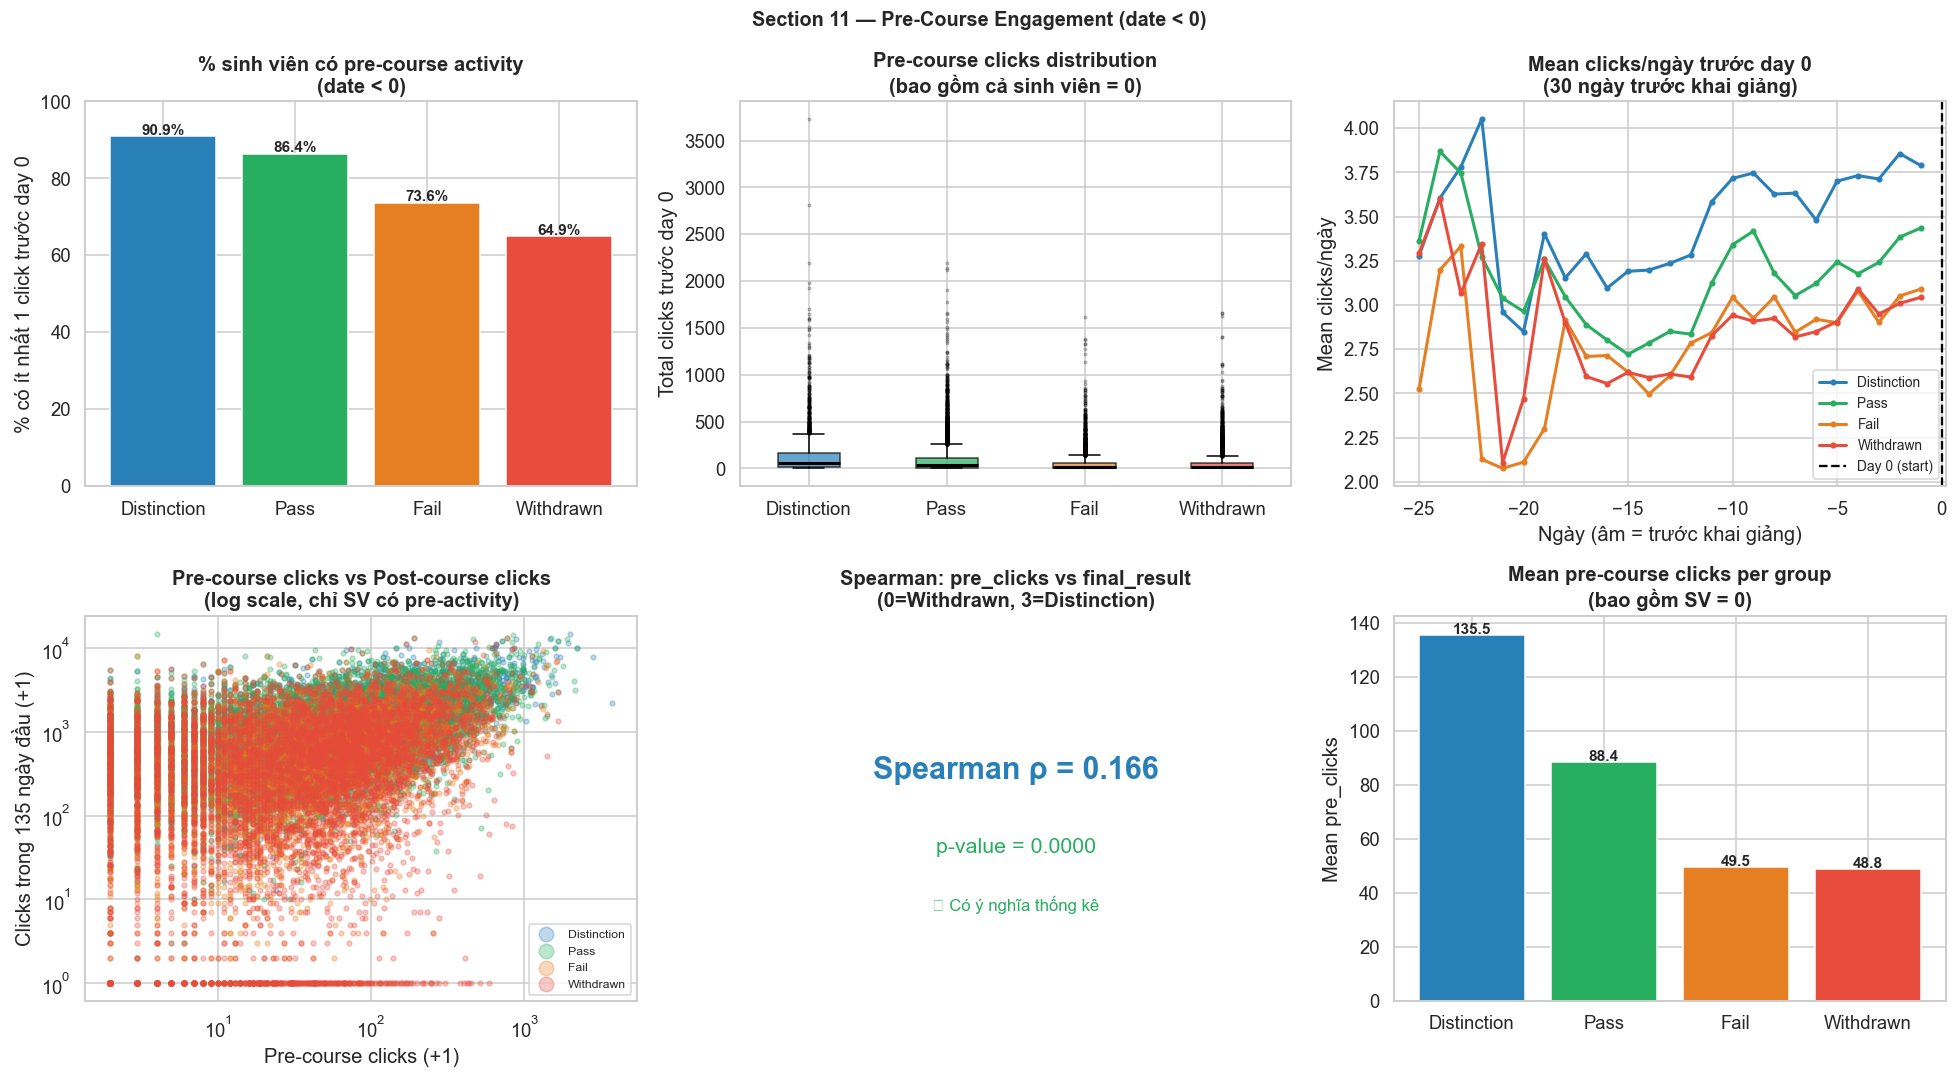


=== Kết luận Section 11 ===
Spearman ρ = 0.166, p = 0.0000
→ Pre-course engagement CÓ signal → thêm vào feature set:
   pre_course_clicks, pre_course_active_days


In [12]:
def section11_precourse_engagement():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    print('Loading studentVle.csv...')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    del df_vle

    # ── Split: pre-course vs in-course ───────────────────────────────────
    pre  = vle[vle['date'] < 0]
    post = vle[vle['date'] >= 0]

    # Aggregate per student
    pre_agg = (
        pre.groupby(['id_student','final_result'])
        .agg(
            pre_clicks      = ('sum_click', 'sum'),
            pre_active_days = ('date', 'nunique'),
        ).reset_index()
    )

    # Students with ZERO pre-course activity (merge back)
    all_students = df_info[['id_student','final_result']].drop_duplicates()
    pre_agg_full = all_students.merge(pre_agg.drop('final_result', axis=1),
                                       on='id_student', how='left').fillna(0)

    has_pre = (pre_agg_full['pre_clicks'] > 0).mean() * 100
    print(f'Sinh viên có pre-course activity: {has_pre:.1f}%')
    print(f'Pre-course records: {len(pre):,} / Total: {len(vle):,} ({len(pre)/len(vle)*100:.1f}%)')

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ── Chart 1: % có pre-course activity theo final_result ──────────────
    pct_pre = (
        pre_agg_full.groupby('final_result')
        .apply(lambda x: (x['pre_clicks'] > 0).mean() * 100)
        .reindex(RESULT_ORDER).reset_index()
        .rename(columns={0: 'pct_has_pre'})
    )
    colors_map = [RESULT_COLORS[r] for r in pct_pre['final_result']]
    bars = axes[0][0].bar(pct_pre['final_result'], pct_pre['pct_has_pre'],
                          color=colors_map, edgecolor='white')
    for bar, val in zip(bars, pct_pre['pct_has_pre']):
        axes[0][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
    axes[0][0].set_title('% sinh viên có pre-course activity\n(date < 0)', fontweight='bold')
    axes[0][0].set_ylabel('% có ít nhất 1 click trước day 0')
    axes[0][0].set_ylim(0, 100)

    # ── Chart 2: Median pre_clicks theo final_result ──────────────────────
    data_clicks = [pre_agg_full[pre_agg_full['final_result'] == r]['pre_clicks']
                   for r in RESULT_ORDER]
    bp = axes[0][1].boxplot(data_clicks, labels=RESULT_ORDER, patch_artist=True,
                             medianprops=dict(color='black', linewidth=2),
                             flierprops=dict(marker='.', alpha=0.3, markersize=3))
    for patch, color in zip(bp['boxes'], RESULT_CLIST):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[0][1].set_title('Pre-course clicks distribution\n(bao gồm cả sinh viên = 0)', fontweight='bold')
    axes[0][1].set_ylabel('Total clicks trước day 0')

    # ── Chart 3: Daily click pattern trước day 0 ─────────────────────────
    pre_daily = (
        pre[pre['date'].between(-30, -1)]
        .groupby(['final_result', 'date'])['sum_click']
        .mean().reset_index()
    )
    for res in RESULT_ORDER:
        g = pre_daily[pre_daily['final_result'] == res]
        if len(g) > 0:
            axes[0][2].plot(g['date'], g['sum_click'],
                            label=res, color=RESULT_COLORS[res], linewidth=2, marker='o', markersize=3)
    axes[0][2].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Day 0 (start)')
    axes[0][2].set_title('Mean clicks/ngày trước day 0\n(30 ngày trước khai giảng)', fontweight='bold')
    axes[0][2].set_xlabel('Ngày (âm = trước khai giảng)')
    axes[0][2].set_ylabel('Mean clicks/ngày')
    axes[0][2].legend(fontsize=9)

    # ── Chart 4: pre_clicks vs total_clicks scatter (log) ────────────────
    post_agg = (
        post[post['date'] <= CUTOFF_DAY]
        .groupby('id_student')['sum_click'].sum()
        .reset_index().rename(columns={'sum_click': 'post_clicks'})
    )
    scatter_df = pre_agg_full.merge(post_agg, on='id_student', how='left').fillna(0)
    scatter_df = scatter_df[scatter_df['pre_clicks'] > 0]  # chỉ plot người có pre-activity

    for res in RESULT_ORDER:
        g = scatter_df[scatter_df['final_result'] == res]
        axes[1][0].scatter(g['pre_clicks'] + 1, g['post_clicks'] + 1,
                           color=RESULT_COLORS[res], alpha=0.3, s=10, label=res)
    axes[1][0].set_xscale('log')
    axes[1][0].set_yscale('log')
    axes[1][0].set_title('Pre-course clicks vs Post-course clicks\n(log scale, chỉ SV có pre-activity)', fontweight='bold')
    axes[1][0].set_xlabel('Pre-course clicks (+1)')
    axes[1][0].set_ylabel(f'Clicks trong {CUTOFF_DAY} ngày đầu (+1)')
    axes[1][0].legend(fontsize=8, markerscale=3)

    # ── Chart 5: Spearman correlation pre_clicks vs target ────────────────
    target_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
    scatter_df['target_enc'] = scatter_df['final_result'].map(target_map)
    corr_val, corr_p = spearmanr(
        scatter_df['pre_clicks'].fillna(0),
        scatter_df['target_enc']
    )
    axes[1][1].text(0.5, 0.6, f'Spearman ρ = {corr_val:.3f}',
                    ha='center', va='center', fontsize=20, fontweight='bold',
                    color='#2980b9', transform=axes[1][1].transAxes)
    axes[1][1].text(0.5, 0.4, f'p-value = {corr_p:.4f}',
                    ha='center', va='center', fontsize=14,
                    color='#27ae60' if corr_p < 0.05 else '#e74c3c',
                    transform=axes[1][1].transAxes)
    sig_text = '✓ Có ý nghĩa thống kê' if corr_p < 0.05 else '✗ Không có ý nghĩa'
    axes[1][1].text(0.5, 0.25, sig_text,
                    ha='center', va='center', fontsize=11,
                    color='#27ae60' if corr_p < 0.05 else '#e74c3c',
                    transform=axes[1][1].transAxes)
    axes[1][1].set_title('Spearman: pre_clicks vs final_result\n(0=Withdrawn, 3=Distinction)', fontweight='bold')
    axes[1][1].axis('off')

    # ── Chart 6: Mean pre_clicks per result ─────────────────────────────
    mean_pre = (
        pre_agg_full.groupby('final_result')['pre_clicks']
        .mean().reindex(RESULT_ORDER)
    )
    bars = axes[1][2].bar(RESULT_ORDER, mean_pre.values,
                          color=RESULT_CLIST, edgecolor='white')
    for bar, val in zip(bars, mean_pre.values):
        axes[1][2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
    axes[1][2].set_title('Mean pre-course clicks per group\n(bao gồm SV = 0)', fontweight='bold')
    axes[1][2].set_ylabel('Mean pre_clicks')

    plt.suptitle('Section 11 — Pre-Course Engagement (date < 0)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Kết luận Section 11 ===')
    print(f'Spearman ρ = {corr_val:.3f}, p = {corr_p:.4f}')
    if corr_p < 0.05 and abs(corr_val) > 0.05:
        print('→ Pre-course engagement CÓ signal → thêm vào feature set:')
        print('   pre_course_clicks, pre_course_active_days')
    else:
        print('→ Signal yếu hoặc không có → optional feature, test khi ablation')

section11_precourse_engagement()

---
## Section 12 — VLE Engagement Heatmap

**3 visualizations:**
1. **Heatmap temporal**: X = tuần, Y = activity_type, màu = mean clicks — xem *khi nào* SV dùng *loại resource nào*
2. **Click distribution theo activity_type**: phân phối 4 class theo từng loại resource (như link team đề xuất)
3. **"Giữ chân" metric**: activity nào có tỉ lệ Distinction/Pass cao nhất so với Withdrawn

Loading studentVle.csv...


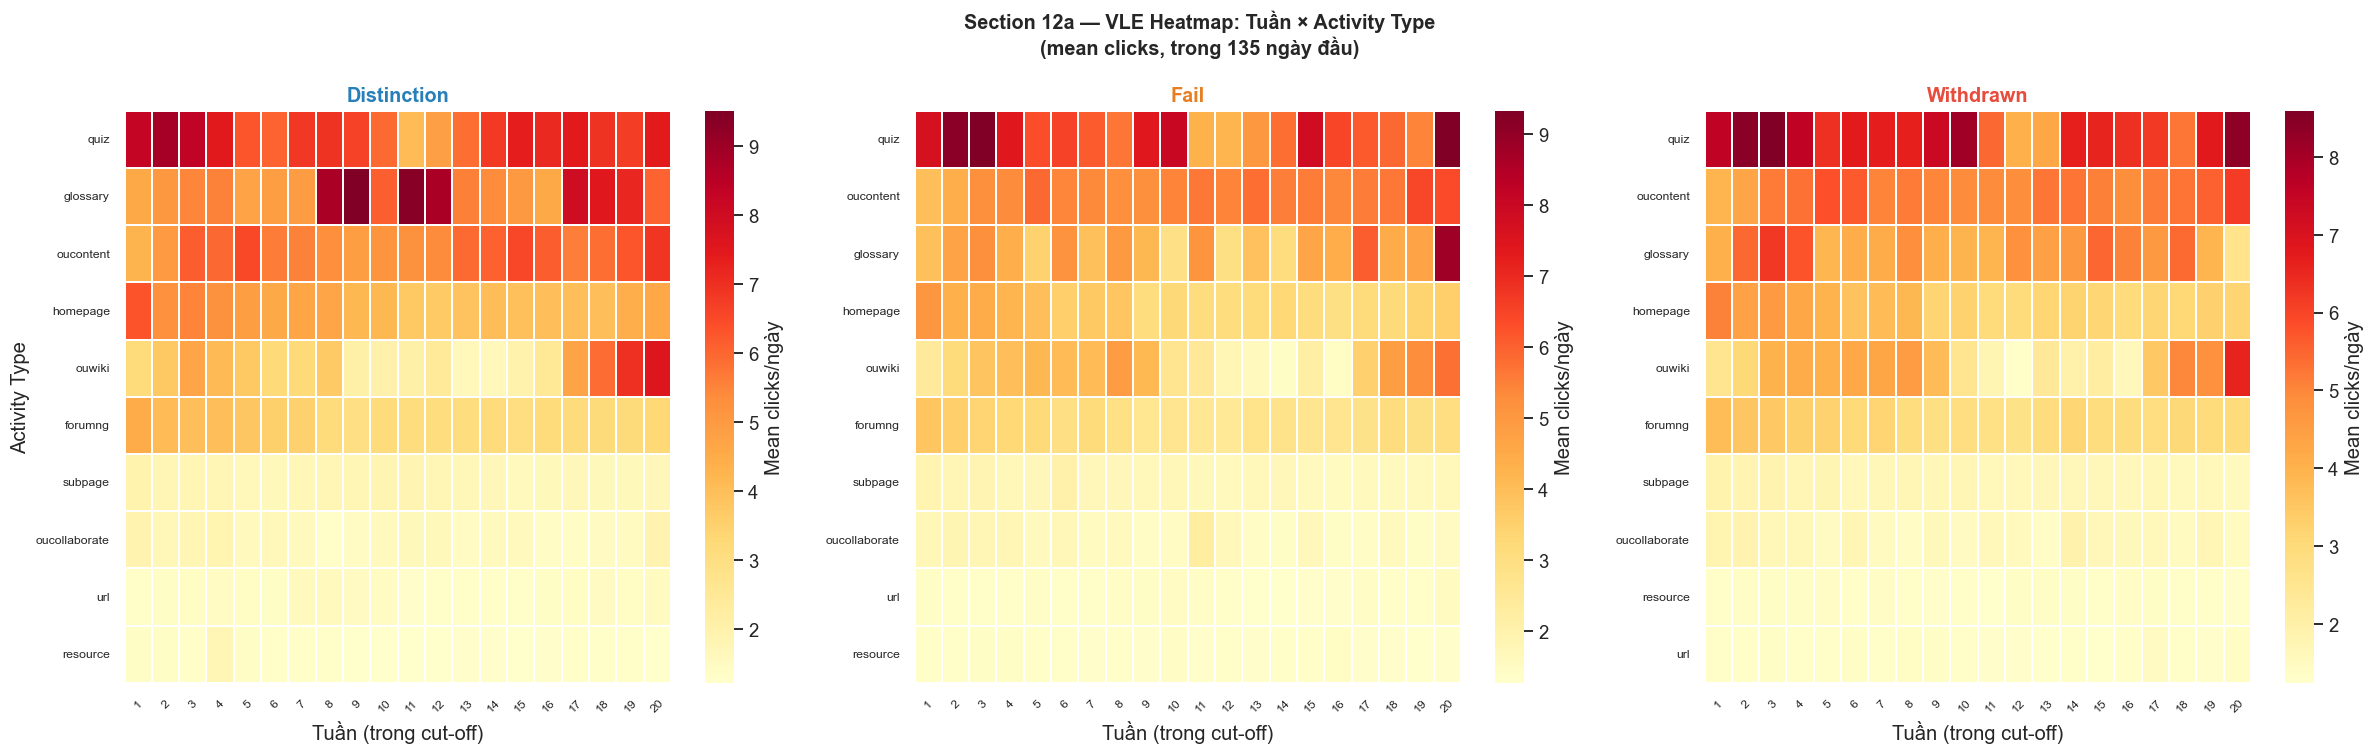

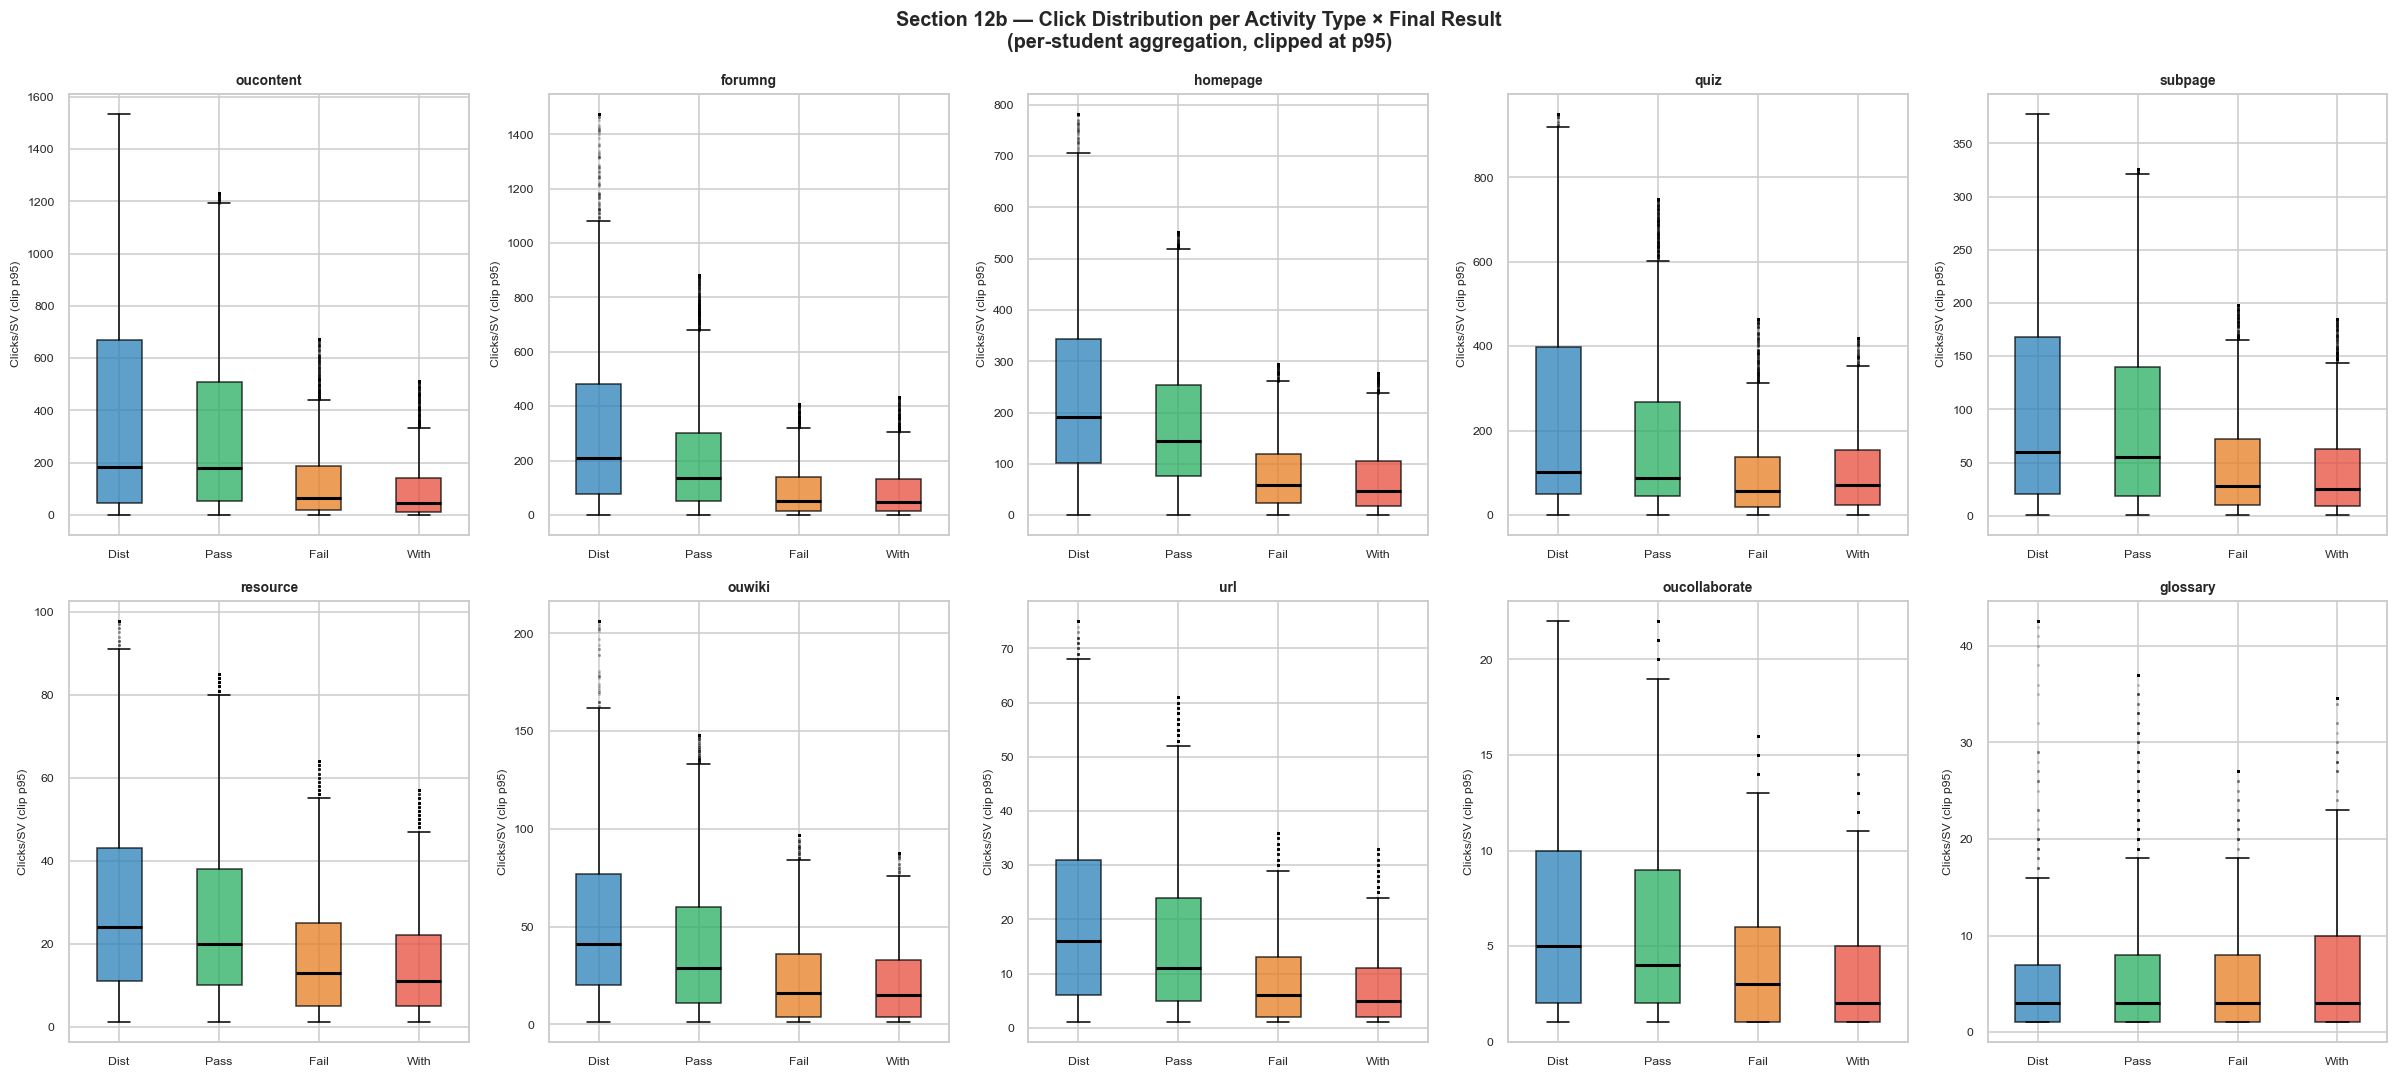

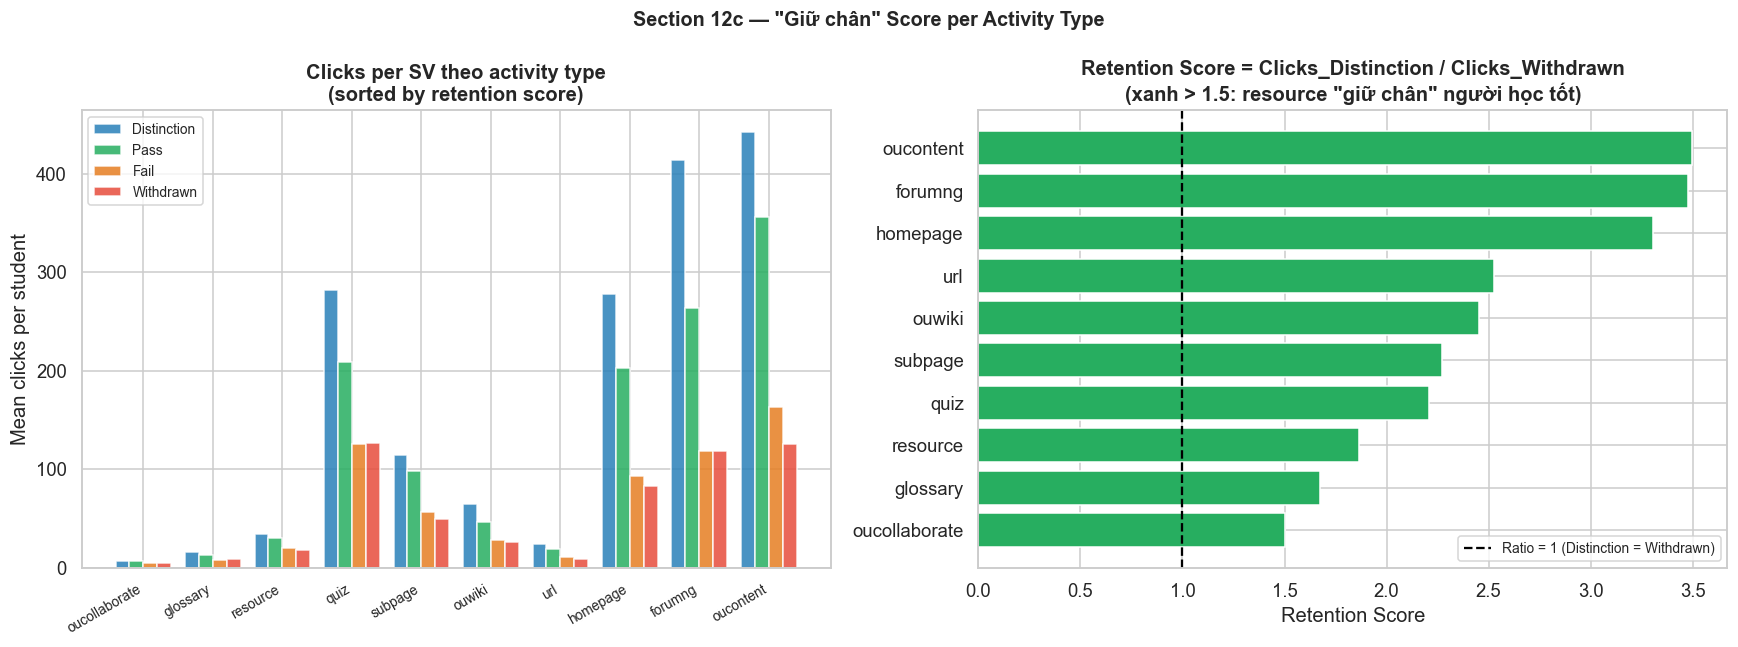


=== Top activities by retention score ===
final_result   Distinction    Pass    Fail  Withdrawn  retention_score
activity_type                                                         
oucollaborate         7.44    6.83    4.86       4.61             1.50
glossary             16.08   12.87    8.13       9.21             1.67
resource             34.04   30.83   20.12      17.77             1.87
quiz                281.67  208.66  125.48     127.10             2.21
subpage             114.71   98.19   56.67      49.98             2.27
ouwiki               64.88   46.36   28.00      25.87             2.45
url                  24.68   19.20   10.91       9.16             2.53
homepage            277.59  202.52   93.35      83.30             3.30
forumng             414.37  263.60  118.86     118.56             3.47
oucontent           442.25  356.73  163.81     125.83             3.49


In [13]:
def section12_vle_heatmap():
    df_info    = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_vle_meta= pd.read_csv(DATA_DIR / 'vle.csv')

    print('Loading studentVle.csv...')
    df_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    ).merge(df_vle_meta[['id_site','activity_type']], on='id_site', how='left')
    del df_vle

    # Chỉ lấy trong cut-off, day >= 0
    vle_cut = vle[(vle['date'] >= 0) & (vle['date'] <= CUTOFF_DAY)].copy()
    vle_cut['week'] = (vle_cut['date'] // 7) + 1

    # Top activity types by total clicks
    top_activities = (
        vle_cut.groupby('activity_type')['sum_click'].sum()
        .sort_values(ascending=False).head(10).index.tolist()
    )
    vle_top = vle_cut[vle_cut['activity_type'].isin(top_activities)]

    # ── Chart 1+2+3: 3 heatmaps per group (Pass, Fail, Withdrawn) ────────
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    show_results = ['Distinction', 'Fail', 'Withdrawn']
    for ax, res in zip(axes, show_results):
        sub = vle_top[vle_top['final_result'] == res]
        pivot = (
            sub.groupby(['activity_type','week'])['sum_click']
            .mean().unstack(fill_value=0)
        )
        # Reorder rows by total
        pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

        sns.heatmap(pivot, ax=ax, cmap='YlOrRd',
                    linewidths=0.3, linecolor='white',
                    cbar_kws={'label': 'Mean clicks/ngày'})
        ax.set_title(f'{res}', fontweight='bold', fontsize=13,
                     color=RESULT_COLORS[res])
        ax.set_xlabel('Tuần (trong cut-off)')
        ax.set_ylabel('Activity Type' if ax == axes[0] else '')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)

    plt.suptitle(f'Section 12a — VLE Heatmap: Tuần × Activity Type\n'
                 f'(mean clicks, trong {CUTOFF_DAY} ngày đầu)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Chart 2: Distribution click theo activity type — 4 class ─────────
    fig, axes = plt.subplots(2, 5, figsize=(22, 10))
    axes = axes.flatten()

    for i, act in enumerate(top_activities):
        ax = axes[i]
        data_per_result = []
        for res in RESULT_ORDER:
            sub = vle_top[
                (vle_top['activity_type'] == act) &
                (vle_top['final_result'] == res)
            ]
            # Aggregate per student
            per_student = sub.groupby('id_student')['sum_click'].sum()
            data_per_result.append(per_student.clip(upper=per_student.quantile(0.95)))

        bp = ax.boxplot(data_per_result, labels=[r[:4] for r in RESULT_ORDER],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', alpha=0.2, markersize=2))
        for patch, color in zip(bp['boxes'], RESULT_CLIST):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
        ax.set_title(act, fontweight='bold', fontsize=9)
        ax.set_ylabel('Clicks/SV (clip p95)', fontsize=8)
        ax.tick_params(labelsize=8)

    # Hide unused subplots
    for j in range(len(top_activities), len(axes)):
        axes[j].axis('off')

    plt.suptitle('Section 12b — Click Distribution per Activity Type × Final Result\n'
                 '(per-student aggregation, clipped at p95)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Chart 3: "Giữ chân" score — ratio Distinction vs Withdrawn ────────
    act_result = (
        vle_top.groupby(['activity_type','final_result'])
        .agg(total_clicks=('sum_click','sum'),
             n_students=('id_student','nunique'))
        .reset_index()
    )
    act_result['clicks_per_student'] = act_result['total_clicks'] / act_result['n_students']

    pivot_cps = act_result.pivot(
        index='activity_type', columns='final_result', values='clicks_per_student'
    ).fillna(0).reindex(columns=RESULT_ORDER)

    # "Retention score" = clicks/SV của Distinction / clicks/SV của Withdrawn
    # Cao → Distinction dùng nhiều hơn Withdrawn → resource này giữ chân người học tốt
    pivot_cps['retention_score'] = (
        (pivot_cps['Distinction'] + 1) / (pivot_cps['Withdrawn'] + 1)
    )
    pivot_cps_sorted = pivot_cps.sort_values('retention_score', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Grouped bar: clicks/SV theo activity
    x = np.arange(len(pivot_cps_sorted))
    w = 0.2
    for j, (res, color) in enumerate(zip(RESULT_ORDER, RESULT_CLIST)):
        axes[0].bar(x + j*w, pivot_cps_sorted[res], w,
                    label=res, color=color, edgecolor='white', alpha=0.85)
    axes[0].set_xticks(x + w*1.5)
    axes[0].set_xticklabels(pivot_cps_sorted.index, rotation=30, ha='right', fontsize=9)
    axes[0].set_title('Clicks per SV theo activity type\n(sorted by retention score)', fontweight='bold')
    axes[0].set_ylabel('Mean clicks per student')
    axes[0].legend(fontsize=9)

    # Retention score bar
    colors_ret = ['#27ae60' if v > 1.5 else '#e67e22' if v > 1.0 else '#e74c3c'
                  for v in pivot_cps_sorted['retention_score']]
    axes[1].barh(pivot_cps_sorted.index, pivot_cps_sorted['retention_score'],
                 color=colors_ret, edgecolor='white')
    axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.5,
                    label='Ratio = 1 (Distinction = Withdrawn)')
    axes[1].set_title('Retention Score = Clicks_Distinction / Clicks_Withdrawn\n'
                      '(xanh > 1.5: resource "giữ chân" người học tốt)',
                      fontweight='bold')
    axes[1].set_xlabel('Retention Score')
    axes[1].legend(fontsize=9)

    plt.suptitle('Section 12c — "Giữ chân" Score per Activity Type', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Top activities by retention score ===')
    print(pivot_cps_sorted[['Distinction','Pass','Fail','Withdrawn','retention_score']].round(2).to_string())

section12_vle_heatmap()

---
## Section 13 — Cut-off Ablation Framework

**Debate từ team:** Chọn ngưỡng 80% Withdrawn captured là arbitrary. Nên chạy thử nhiều cut-off và so sánh model performance.

**Cách đúng (như paper tham khảo):**
```
for cutoff in [30, 60, 90, 120, 135, 150, 180]:
    features = build_features(data, cutoff)
    model.fit(X_train)
    score = model.evaluate(X_test)
    → plot cutoff vs AUC/F1
```

**Section này:** Framework + placeholder — chưa train model thật.
Sau khi có feature engineering pipeline, quay lại điền vào `run_ablation_for_cutoff()`.

**Per-module cut-off:** Visualize withdrawal distribution per module để justify
có cần cut-off riêng cho từng module không.

> ⚠️ Note: Nếu cut-off per module → inference pipeline phức tạp hơn nhiều.
> Chỉ làm nếu ablation cho thấy chênh lệch >5% F1 giữa các module.

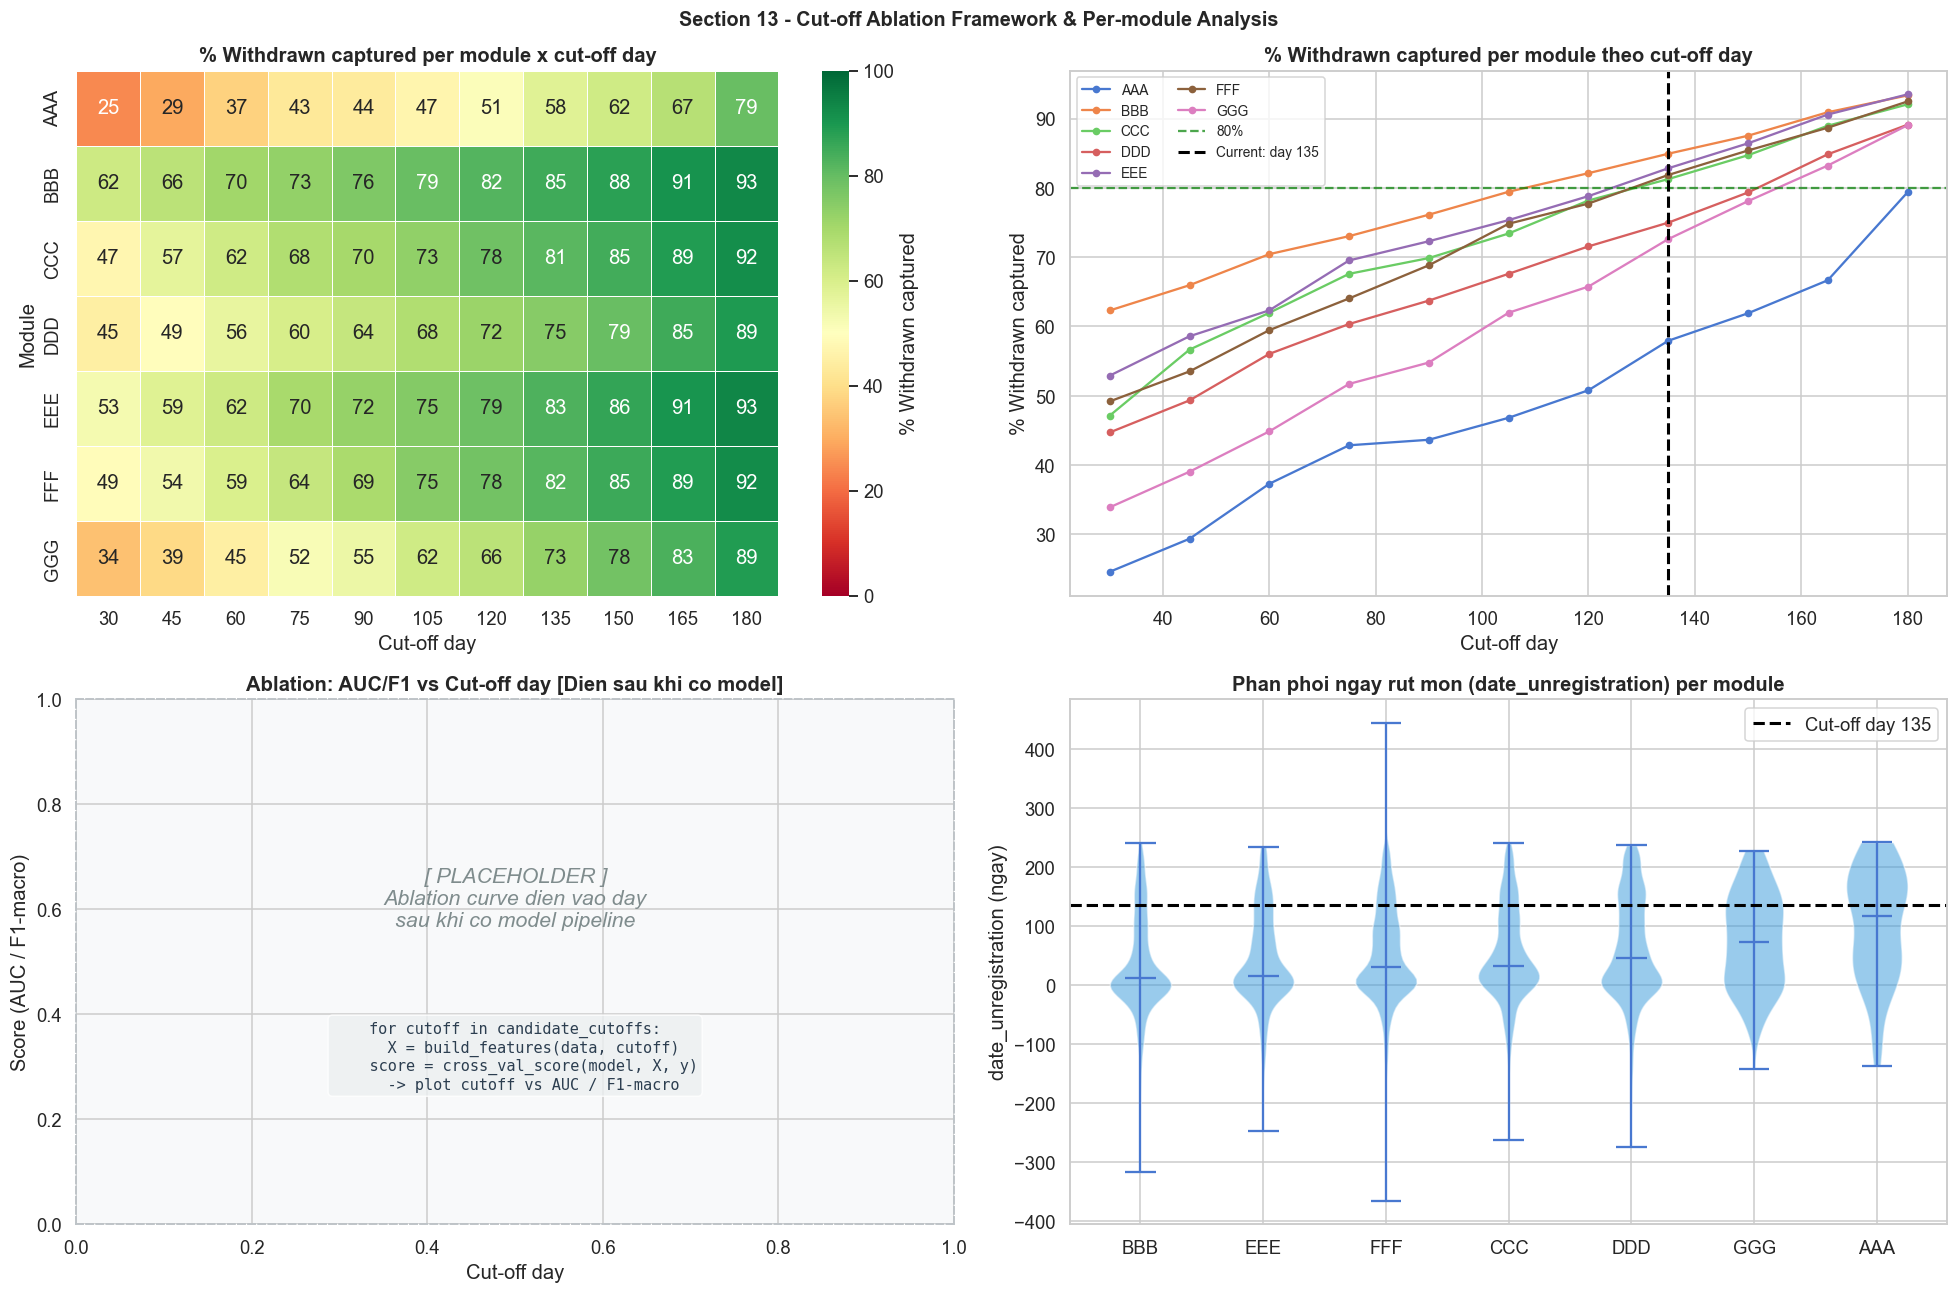

=== Divergence: ngay dat 80% Withdrawn captured per module ===
  AAA: khong dat 80% trong range thu nghiem
  BBB: day 120
  CCC: day 135
  DDD: day 165
  EEE: day 135
  FFF: day 135
  GGG: day 165

-> Neu cac module diverge >30 ngay: can xem xet per-module cut-off
-> Neu converge trong +/-20 ngay: 1 cut-off chung (day 135) la du


In [14]:
def section13_cutoff_ablation_framework():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_reg
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_crs, on=['code_module','code_presentation'], how='left')
    )
    withdrawn = merged[merged['final_result'] == 'Withdrawn'].copy()

    cutoff_candidates = [30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
    modules  = sorted(df_info['code_module'].unique())
    med_len  = df_crs['module_presentation_length'].median()
    total_w  = len(withdrawn)

    # Per-module capture rate
    records_per_module = []
    for mod in modules:
        w_mod = withdrawn[withdrawn['code_module'] == mod]
        total = len(w_mod)
        if total == 0:
            continue
        for c in cutoff_candidates:
            n = (w_mod['date_unregistration'] <= c).sum()
            records_per_module.append({'module': mod, 'cutoff_day': c,
                                       'pct_captured': n / total * 100})
    df_mod = pd.DataFrame(records_per_module)

    # Overall capture curve
    records_overall = []
    for c in cutoff_candidates:
        n = (withdrawn['date_unregistration'] <= c).sum()
        records_overall.append({'cutoff_day': c,
                                'pct_captured': n / total_w * 100,
                                'remaining_pct': (1 - c / med_len) * 100})
    df_overall = pd.DataFrame(records_overall)

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # Chart 1: heatmap module x cutoff
    pivot_mod = df_mod.pivot(index='module', columns='cutoff_day', values='pct_captured')
    sns.heatmap(pivot_mod, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, ax=axes[0][0],
                cbar_kws={'label': '% Withdrawn captured'},
                vmin=0, vmax=100)
    axes[0][0].set_title('% Withdrawn captured per module x cut-off day', fontweight='bold')
    axes[0][0].set_xlabel('Cut-off day')
    axes[0][0].set_ylabel('Module')

    # Chart 2: line per module
    for mod in modules:
        sub = df_mod[df_mod['module'] == mod]
        axes[0][1].plot(sub['cutoff_day'], sub['pct_captured'],
                        marker='o', markersize=4, linewidth=1.5, label=mod)
    axes[0][1].axhline(80, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='80%')
    axes[0][1].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                       label=f'Current: day {CUTOFF_DAY}')
    axes[0][1].set_title('% Withdrawn captured per module theo cut-off day', fontweight='bold')
    axes[0][1].set_xlabel('Cut-off day')
    axes[0][1].set_ylabel('% Withdrawn captured')
    axes[0][1].legend(fontsize=9, ncol=2)

    # Chart 3: Ablation placeholder
    axes[1][0].set_facecolor('#f8f9fa')
    axes[1][0].text(0.5, 0.62,
                    '[ PLACEHOLDER ]\nAblation curve dien vao day\nsau khi co model pipeline',
                    ha='center', va='center', fontsize=14,
                    color='#7f8c8d', style='italic',
                    transform=axes[1][0].transAxes)
    axes[1][0].text(0.5, 0.32,
                    'for cutoff in candidate_cutoffs:\n'
                    '    X = build_features(data, cutoff)\n'
                    '    score = cross_val_score(model, X, y)\n'
                    '    -> plot cutoff vs AUC / F1-macro',
                    ha='center', va='center', fontsize=10,
                    color='#2c3e50', family='monospace',
                    transform=axes[1][0].transAxes,
                    bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.8))
    axes[1][0].set_title('Ablation: AUC/F1 vs Cut-off day [Dien sau khi co model]',
                         fontweight='bold')
    axes[1][0].set_xlabel('Cut-off day')
    axes[1][0].set_ylabel('Score (AUC / F1-macro)')
    for spine in axes[1][0].spines.values():
        spine.set_linestyle('--')
        spine.set_edgecolor('#bdc3c7')

    # Chart 4: Violin plot withdrawal timing per module
    w_plot = withdrawn.dropna(subset=['date_unregistration']).copy()
    module_order = (
        w_plot.groupby('code_module')['date_unregistration']
        .median().sort_values().index.tolist()
    )
    vp = axes[1][1].violinplot(
        [w_plot[w_plot['code_module'] == m]['date_unregistration'].values
         for m in module_order],
        positions=range(len(module_order)),
        showmedians=True
    )
    for pc in vp['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.5)
    axes[1][1].axhline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                       label=f'Cut-off day {CUTOFF_DAY}')
    axes[1][1].set_xticks(range(len(module_order)))
    axes[1][1].set_xticklabels(module_order)
    axes[1][1].set_title('Phan phoi ngay rut mon (date_unregistration) per module', fontweight='bold')
    axes[1][1].set_ylabel('date_unregistration (ngay)')
    axes[1][1].legend()

    plt.suptitle('Section 13 - Cut-off Ablation Framework & Per-module Analysis',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print divergence
    print(f"=== Divergence: ngay dat 80% Withdrawn captured per module ===")
    for mod in modules:
        sub = df_mod[df_mod['module'] == mod]
        co80 = sub[sub['pct_captured'] >= 80]['cutoff_day']
        if len(co80) > 0:
            print(f"  {mod}: day {co80.min():3d}")
        else:
            print(f"  {mod}: khong dat 80% trong range thu nghiem")
    print(f"\n-> Neu cac module diverge >30 ngay: can xem xet per-module cut-off")
    print(f"-> Neu converge trong +/-20 ngay: 1 cut-off chung (day {CUTOFF_DAY}) la du")

section13_cutoff_ablation_framework()

---
## Section 11 — Pre-course Engagement (clicks trước day 0)

> **Gap trong EDA cũ: chưa ai tính.** Câu hỏi: sinh viên vào xem tài liệu trước ngày khai giảng (day < 0) có pass rate cao hơn không?

**Hypothesis:**
- Pre-course engagement = proxy của motivation
- Sinh viên chủ động vào VLE sớm → có kế hoạch học tập rõ ràng hơn

**Nếu có signal:** thêm feature `pre_course_clicks` và `pre_course_active_days` vào feature set.

**Lưu ý kỹ thuật:** VLE mở trước ngày 0 khoảng 3–4 tuần (~day -25). Không phải module nào cũng có pre-course data.

Loading studentVle.csv...
=== % sinh viên có ít nhất 1 click trước day 0 ===
              total  has_pre_click   pct
final_result                            
Distinction    3024           2598  85.9
Pass          12361          10046  81.3
Fail           7052           4726  67.0
Withdrawn     10156           5331  52.5


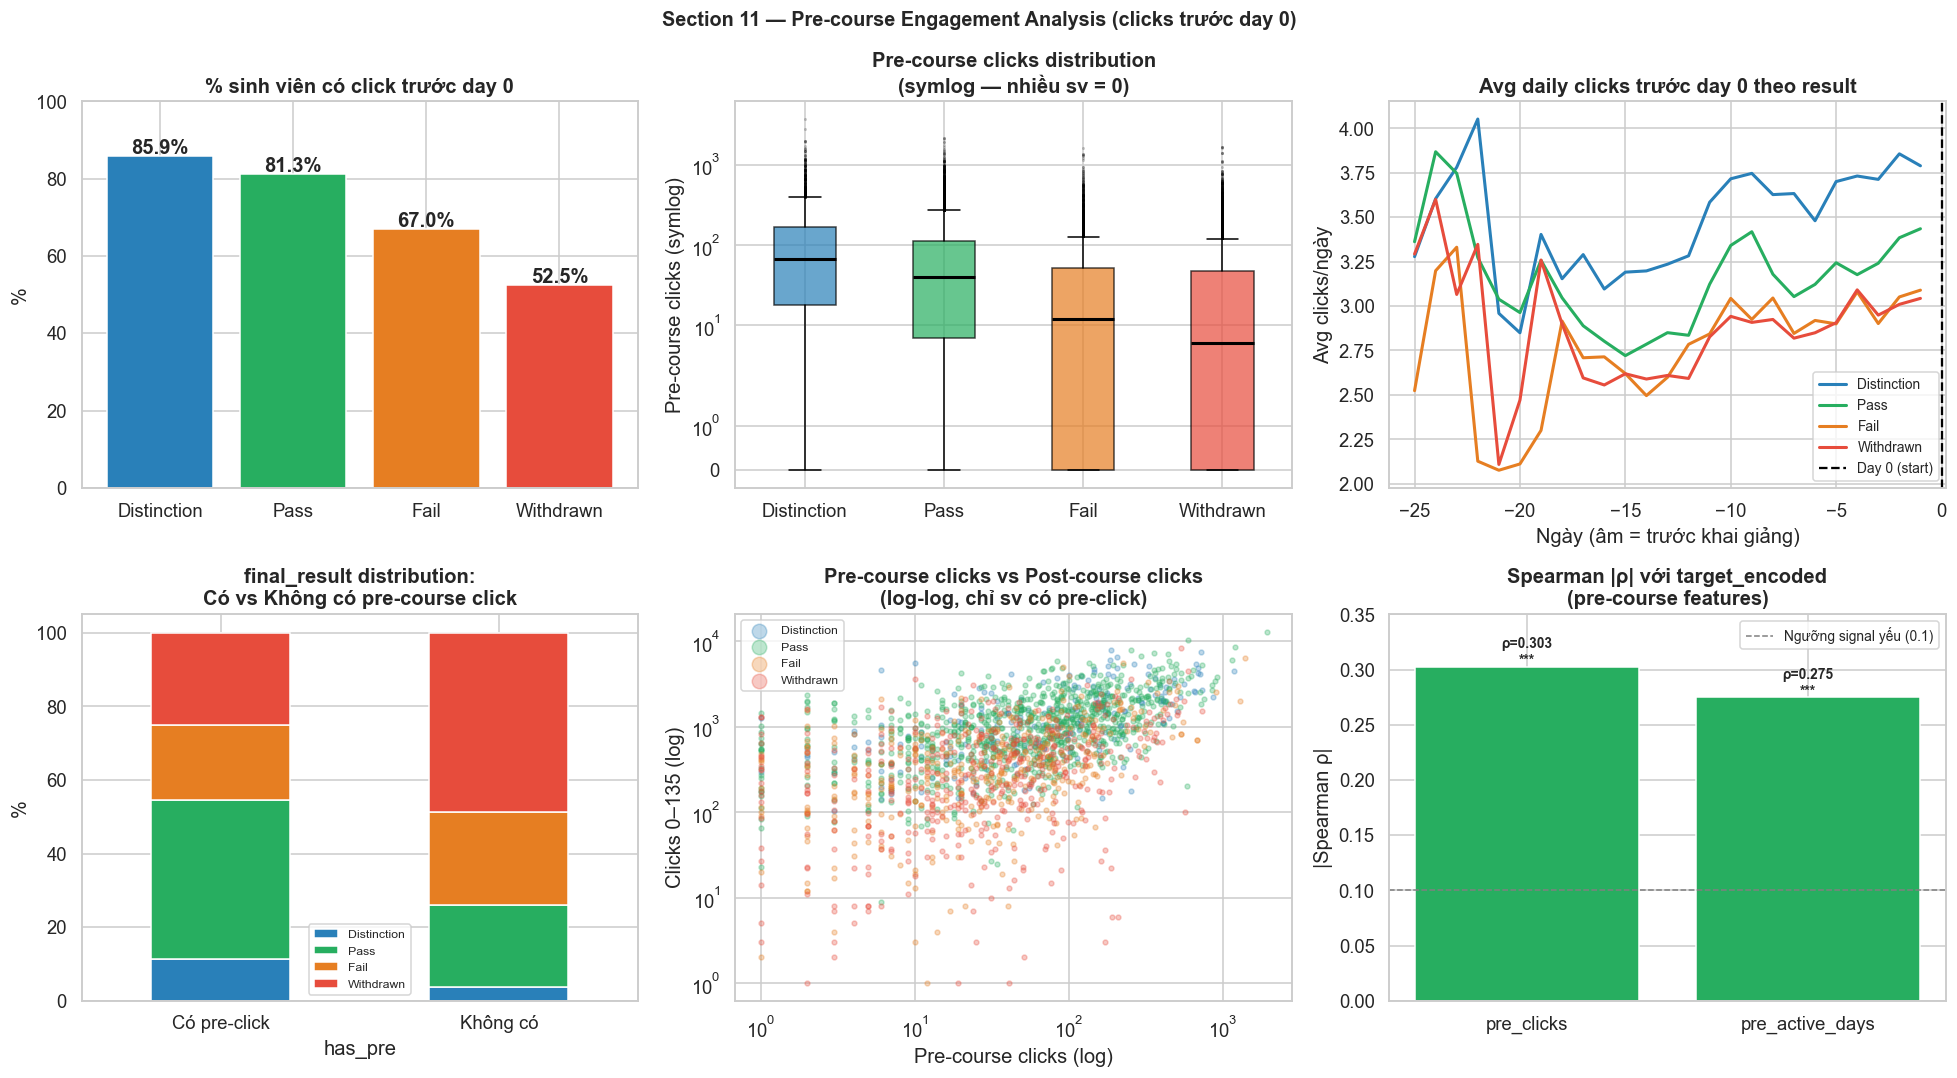


=== Kết luận ===
  Spearman ρ (pre_clicks      vs outcome): 0.303  p=0.00e+00
  Spearman ρ (pre_active_days vs outcome): 0.275  p=0.00e+00
  → Verdict: THÊM vào feature set


In [15]:
def section11_precourse_engagement():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    print('Loading studentVle.csv...')
    df_vle  = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = df_vle.merge(
        df_info[['code_module','code_presentation','id_student','final_result']],
        on=['code_module','code_presentation','id_student'], how='inner'
    )
    del df_vle

    pre  = vle[vle['date'] < 0].copy()
    post = vle[vle['date'] >= 0].copy()

    # ── 1. Bao nhiêu sinh viên có pre-course activity? ──────────────────
    total_per_result = df_info['final_result'].value_counts().rename('total')
    pre_per_result   = (
        pre.groupby('final_result')['id_student'].nunique().rename('has_pre_click')
    )
    coverage = pd.concat([total_per_result, pre_per_result], axis=1).reindex(RESULT_ORDER)
    coverage['pct'] = (coverage['has_pre_click'] / coverage['total'] * 100).round(1)
    print('=== % sinh viên có ít nhất 1 click trước day 0 ===')
    print(coverage.to_string())

    # ── 2. Aggregate pre-course per student ──────────────────────────────
    pre_agg = (
        pre.groupby(['id_student','final_result'])
        .agg(pre_clicks=('sum_click','sum'), pre_active_days=('date','nunique'))
        .reset_index()
    )
    # Include students with 0 pre-course clicks
    all_students = df_info[['id_student','final_result']].copy()
    pre_agg_full = all_students.merge(pre_agg, on=['id_student','final_result'], how='left').fillna(0)

    # ── 3. Plots ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Chart 1: % có pre-course click per result
    colors = [RESULT_COLORS[r] for r in coverage.index]
    bars = axes[0][0].bar(coverage.index, coverage['pct'], color=colors, edgecolor='white')
    for bar, val in zip(bars, coverage['pct']):
        axes[0][0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', fontweight='bold')
    axes[0][0].set_title('% sinh viên có click trước day 0', fontweight='bold')
    axes[0][0].set_ylabel('%')
    axes[0][0].set_ylim(0, 100)

    # Chart 2: Boxplot pre_clicks per result (log scale)
    data_pre = [pre_agg_full[pre_agg_full['final_result'] == r]['pre_clicks'] for r in RESULT_ORDER]
    bp = axes[0][1].boxplot(data_pre, labels=RESULT_ORDER, patch_artist=True,
                             medianprops=dict(color='black', linewidth=2),
                             flierprops=dict(marker='.', alpha=0.2, markersize=2))
    for patch, color in zip(bp['boxes'], RESULT_CLIST):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[0][1].set_yscale('symlog')  # symlog vì nhiều giá trị 0
    axes[0][1].set_title('Pre-course clicks distribution\n(symlog — nhiều sv = 0)', fontweight='bold')
    axes[0][1].set_ylabel('Pre-course clicks (symlog)')

    # Chart 3: Daily clicks trước day 0 theo result
    daily_pre = (
        pre[pre['date'].between(-30, -1)]
        .groupby(['final_result','date'])['sum_click']
        .mean().reset_index()
    )
    for res in RESULT_ORDER:
        g = daily_pre[daily_pre['final_result'] == res]
        axes[0][2].plot(g['date'], g['sum_click'],
                        label=res, color=RESULT_COLORS[res], linewidth=2)
    axes[0][2].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Day 0 (start)')
    axes[0][2].set_title('Avg daily clicks trước day 0 theo result', fontweight='bold')
    axes[0][2].set_xlabel('Ngày (âm = trước khai giảng)')
    axes[0][2].set_ylabel('Avg clicks/ngày')
    axes[0][2].legend(fontsize=9)

    # Chart 4: Có vs không có pre-course — pass rate comparison
    pre_agg_full['has_pre'] = (pre_agg_full['pre_clicks'] > 0).map({True:'Có pre-click', False:'Không có'})
    pass_by_pre = (
        pre_agg_full
        .assign(is_pass=lambda x: x['final_result'].isin(['Pass','Distinction']).astype(int))
        .groupby(['has_pre','final_result'])
        .size().reset_index(name='count')
    )
    pivot_pre = pass_by_pre.pivot(index='has_pre', columns='final_result', values='count').fillna(0)
    pivot_pre = pivot_pre.div(pivot_pre.sum(axis=1), axis=0) * 100
    pivot_pre = pivot_pre.reindex(columns=RESULT_ORDER, fill_value=0)
    pivot_pre.plot(kind='bar', stacked=True, ax=axes[1][0],
                   color=RESULT_CLIST, edgecolor='white')
    axes[1][0].set_title('final_result distribution:\nCó vs Không có pre-course click', fontweight='bold')
    axes[1][0].set_ylabel('%')
    axes[1][0].tick_params(axis='x', rotation=0)
    axes[1][0].legend(title='', fontsize=8)

    # Chart 5: Pre-course clicks vs total clicks scatter (sample)
    post_agg = (
        post[post['date'] <= CUTOFF_DAY]
        .groupby(['id_student','final_result'])['sum_click']
        .sum().reset_index().rename(columns={'sum_click':'post_clicks'})
    )
    scatter_df = pre_agg_full.merge(post_agg, on=['id_student','final_result'], how='left').dropna()
    scatter_df = scatter_df[scatter_df['pre_clicks'] > 0]  # chỉ sv có pre-click
    sample = scatter_df.sample(min(2000, len(scatter_df)), random_state=42)
    for res in RESULT_ORDER:
        s = sample[sample['final_result'] == res]
        axes[1][1].scatter(s['pre_clicks'], s['post_clicks'],
                           alpha=0.3, s=10, color=RESULT_COLORS[res], label=res)
    axes[1][1].set_xscale('log'); axes[1][1].set_yscale('log')
    axes[1][1].set_title('Pre-course clicks vs Post-course clicks\n(log-log, chỉ sv có pre-click)', fontweight='bold')
    axes[1][1].set_xlabel('Pre-course clicks (log)')
    axes[1][1].set_ylabel(f'Clicks 0–{CUTOFF_DAY} (log)')
    axes[1][1].legend(fontsize=8, markerscale=3)

    # Chart 6: Spearman corr — pre clicks vs outcome
    from scipy.stats import spearmanr
    target_map = {'Distinction':3,'Pass':2,'Fail':1,'Withdrawn':0}
    corr_df = pre_agg_full.copy()
    corr_df['target_enc'] = corr_df['final_result'].map(target_map)
    r_clicks, p_clicks = spearmanr(corr_df['pre_clicks'], corr_df['target_enc'])
    r_days,   p_days   = spearmanr(corr_df['pre_active_days'], corr_df['target_enc'])
    metrics   = ['pre_clicks', 'pre_active_days']
    rhos      = [r_clicks, r_days]
    pvals     = [p_clicks, p_days]
    colors_sp = ['#27ae60' if abs(r) > 0.1 else '#e74c3c' for r in rhos]
    bars2 = axes[1][2].bar(metrics, [abs(r) for r in rhos], color=colors_sp, edgecolor='white')
    for bar, r, p in zip(bars2, rhos, pvals):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        axes[1][2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                        f'ρ={r:.3f}\n{sig}', ha='center', fontsize=9, fontweight='bold')
    axes[1][2].set_title('Spearman |ρ| với target_encoded\n(pre-course features)', fontweight='bold')
    axes[1][2].set_ylabel('|Spearman ρ|')
    axes[1][2].set_ylim(0, 0.35)
    axes[1][2].axhline(0.1, color='gray', linestyle='--', linewidth=1, label='Ngưỡng signal yếu (0.1)')
    axes[1][2].legend(fontsize=9)

    plt.suptitle('Section 11 — Pre-course Engagement Analysis (clicks trước day 0)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== Kết luận ===')
    print(f'  Spearman ρ (pre_clicks      vs outcome): {r_clicks:.3f}  p={p_clicks:.2e}')
    print(f'  Spearman ρ (pre_active_days vs outcome): {r_days:.3f}  p={p_days:.2e}')
    verdict = 'THÊM vào feature set' if abs(r_clicks) > 0.05 else 'Signal yếu — có thể bỏ'
    print(f'  → Verdict: {verdict}')

section11_precourse_engagement()

---
## Section 12 — VLE Engagement Heatmap & Activity Breakdown

### 12a. Temporal Heatmap
Trục X = ngày, trục Y = loại activity, màu = cường độ click trung bình.
→ Xác định resource nào "giữ chân" sinh viên, vào thời điểm nào trong module.

### 12b. Click distribution per activity type — 4 classes
Tham khảo: [OULAD dropout prediction](https://sergiosim.github.io/OULAD/notebooks/time_series_classification_for_dropout_prediction.html)

So sánh tổng clicks và phân phối (boxplot) theo từng activity type, breakdown by final_result.

Loading studentVle.csv...


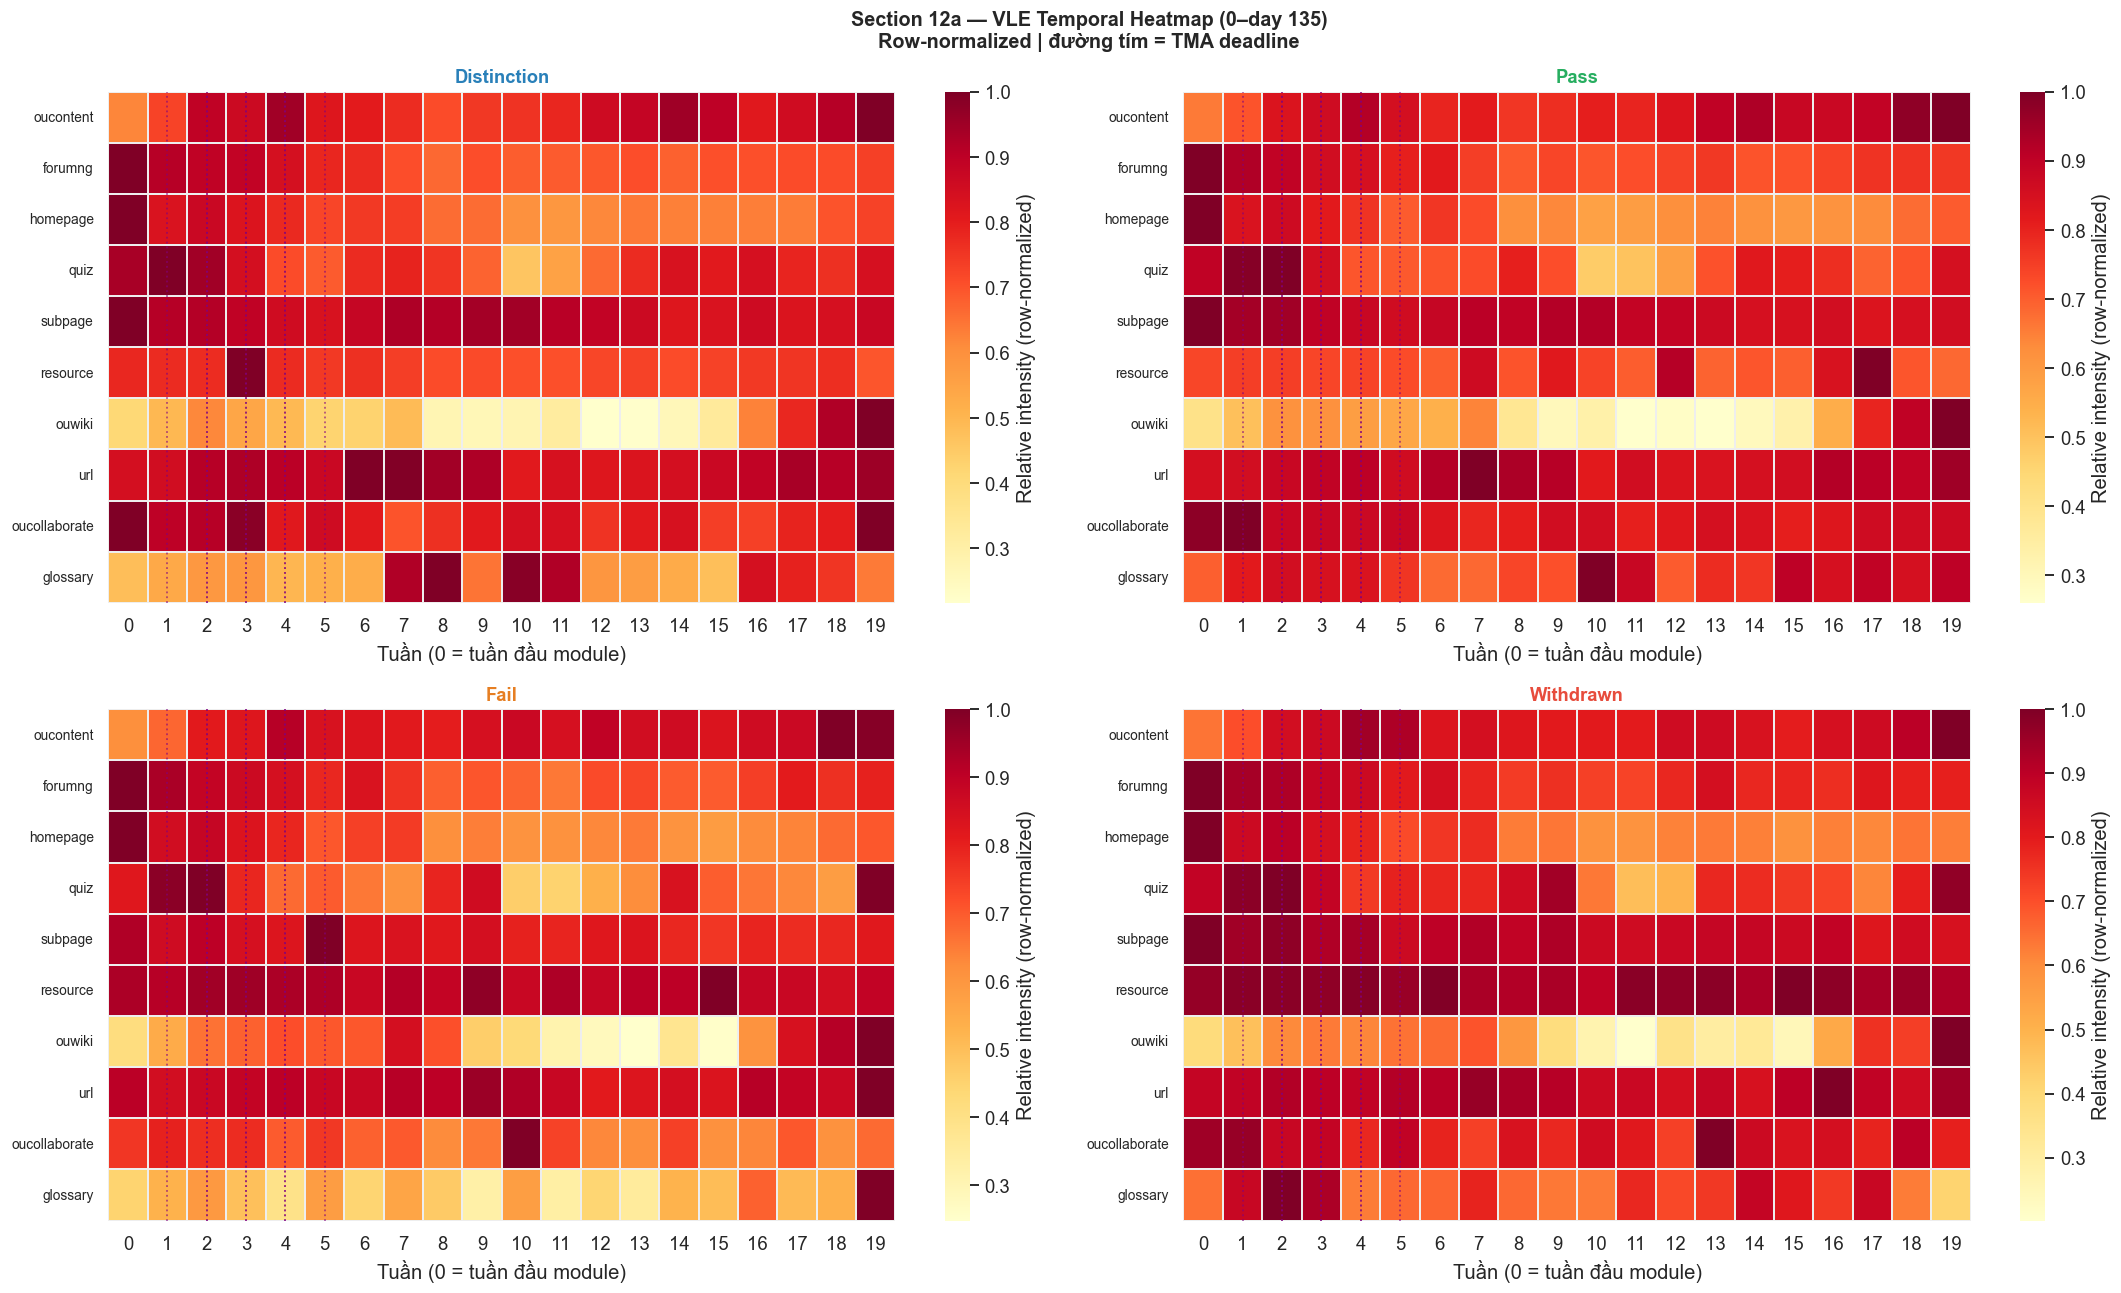

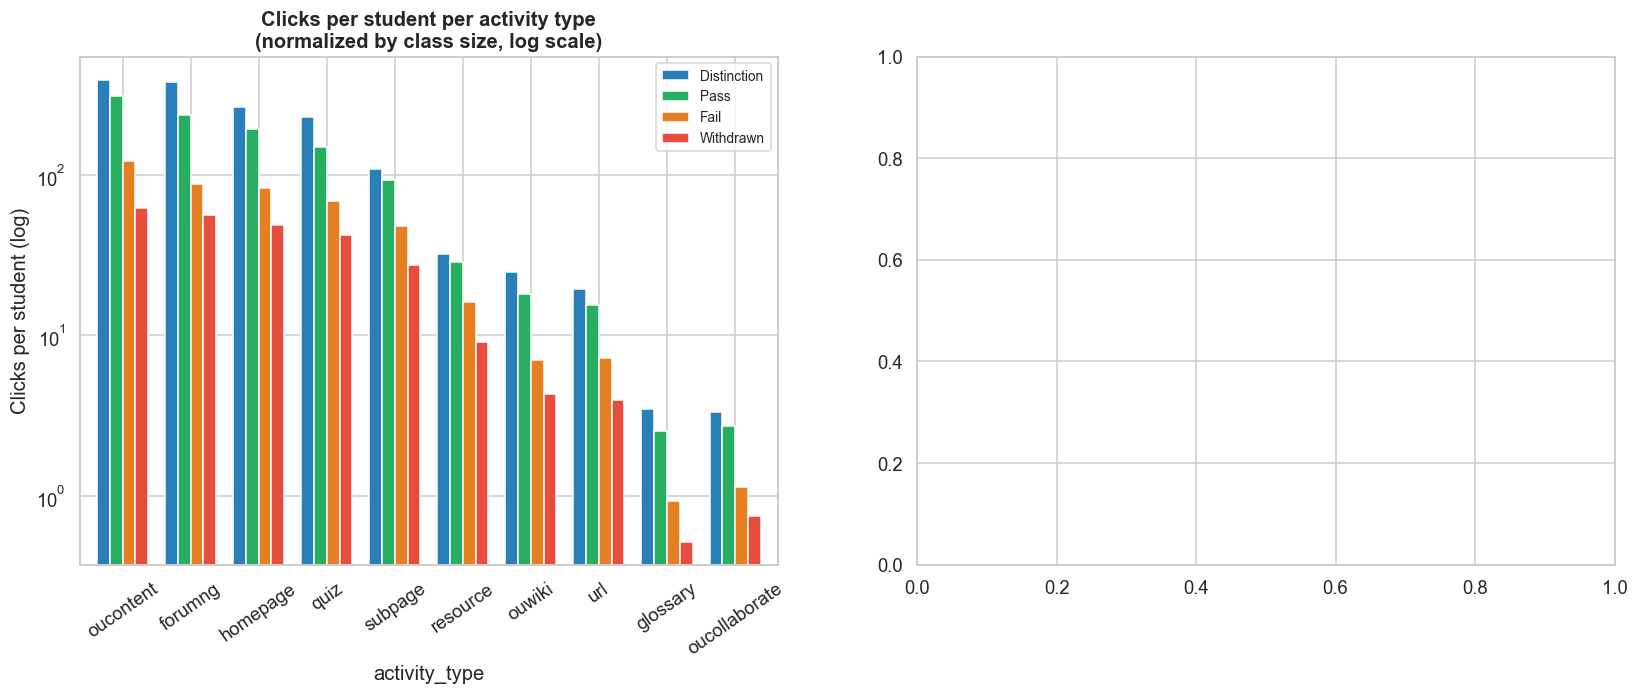

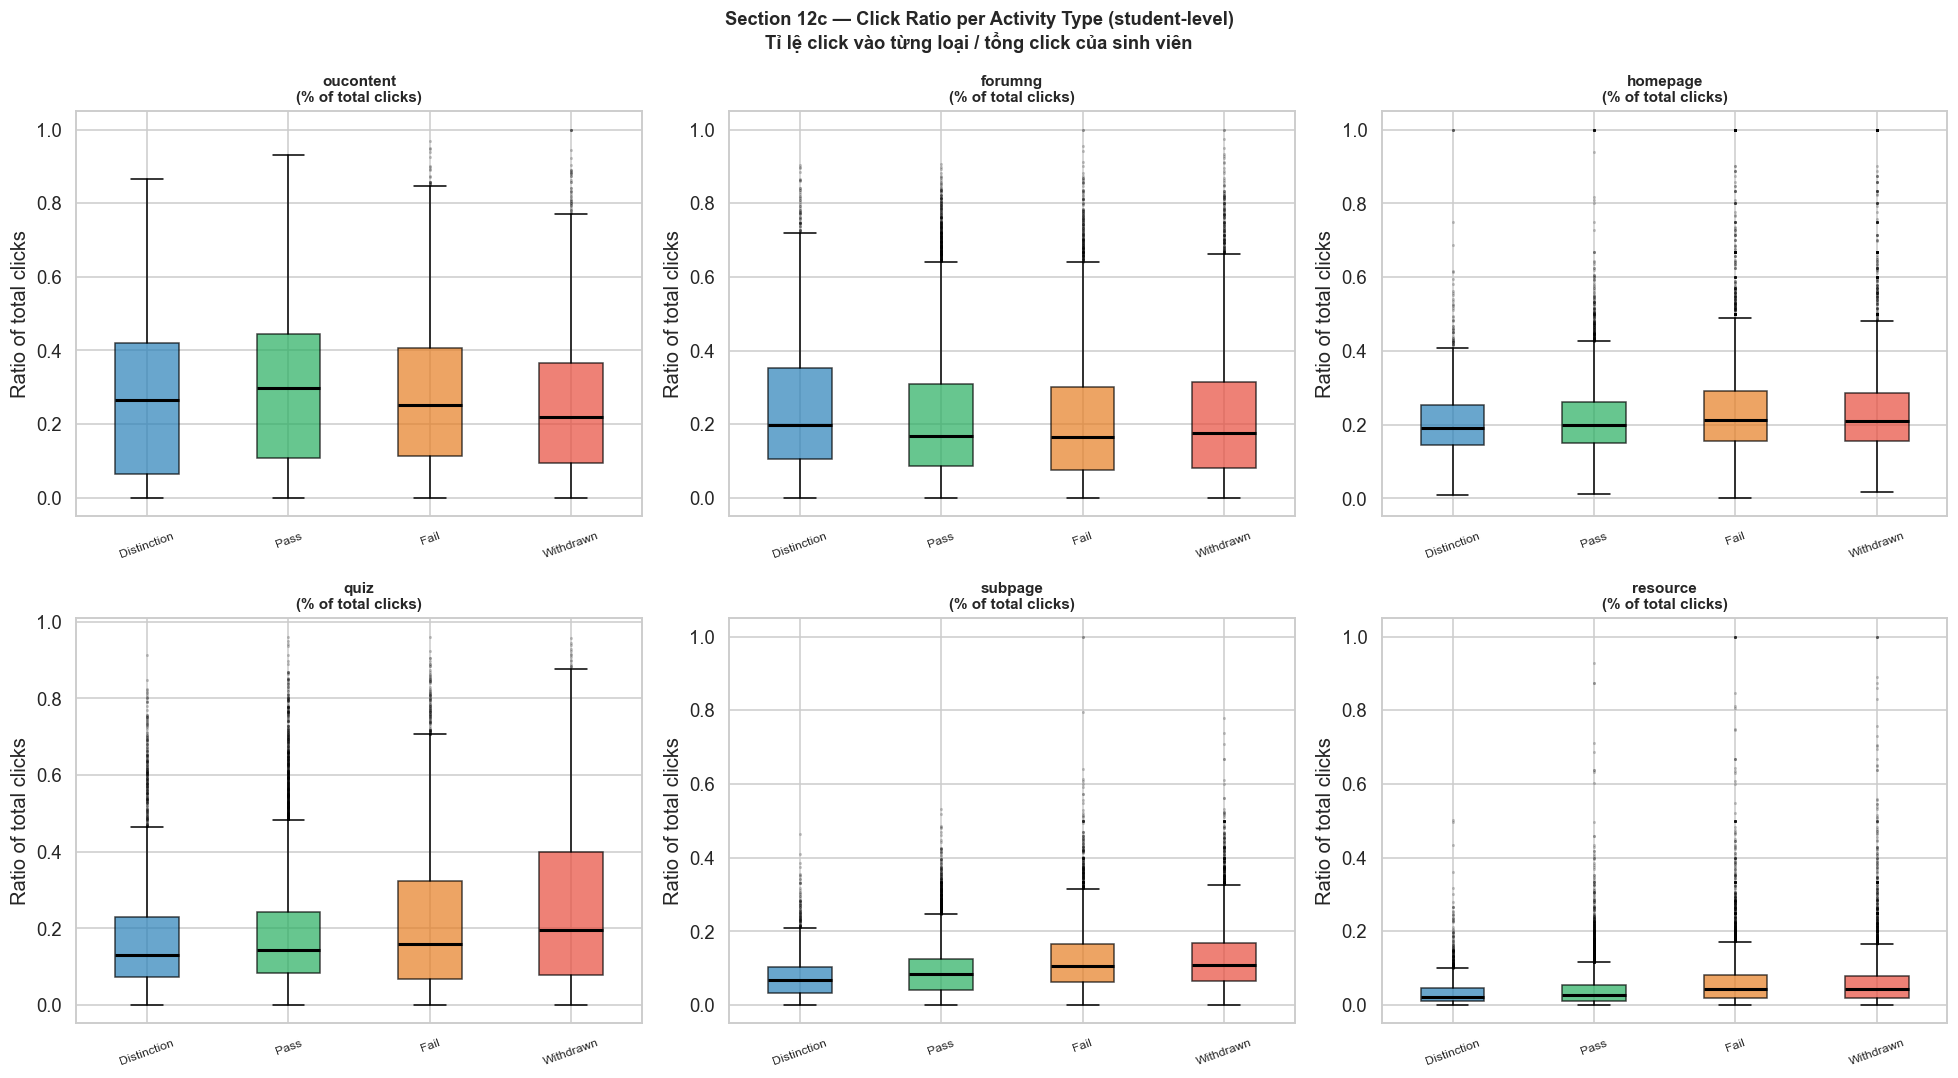

=== Top activities by Distinction click_ratio (median) ===
final_result   Distinction   Pass   Fail  Withdrawn
activity_type                                      
oucontent            0.265  0.299  0.251      0.220
forumng              0.197  0.169  0.164      0.176
homepage             0.191  0.200  0.214      0.211
quiz                 0.131  0.143  0.160      0.197
subpage              0.069  0.083  0.107      0.108
resource             0.022  0.027  0.042      0.042


In [16]:
def section12_vle_heatmap_activity():
    df_info  = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_vle_meta = pd.read_csv(DATA_DIR / 'vle.csv')
    df_ass   = pd.read_csv(DATA_DIR / 'assessments.csv')
    print('Loading studentVle.csv...')
    df_vle   = pd.read_csv(DATA_DIR / 'studentVle.csv')

    vle = (
        df_vle
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_vle_meta[['id_site','activity_type']], on='id_site', how='left')
    )
    del df_vle

    tma_dates = df_ass[df_ass['assessment_type']=='TMA']['date'].sort_values().unique()[:8]
    vle_cut   = vle[(vle['date'] >= 0) & (vle['date'] <= CUTOFF_DAY)].copy()

    # ── 12a: Heatmap temporal per result ─────────────────────────────────
    # Bin days thành tuần để heatmap đỡ noisy
    vle_cut['week_bin'] = (vle_cut['date'] // 7).astype(int)
    top_activities = (
        vle_cut.groupby('activity_type')['sum_click'].sum()
        .sort_values(ascending=False).head(10).index.tolist()
    )
    vle_top = vle_cut[vle_cut['activity_type'].isin(top_activities)]

    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    for ax, res in zip(axes.flat, RESULT_ORDER):
        sub = vle_top[vle_top['final_result'] == res]
        pivot = (
            sub.groupby(['activity_type','week_bin'])['sum_click']
            .mean().unstack(fill_value=0)
            .reindex(index=top_activities, fill_value=0)
        )
        # Normalize per row để thấy pattern, không bị dominated bởi oucontent
        pivot_norm = pivot.div(pivot.max(axis=1).replace(0, 1), axis=0)

        sns.heatmap(pivot_norm, ax=ax, cmap='YlOrRd',
                    cbar_kws={'label': 'Relative intensity (row-normalized)'},
                    linewidths=0.3, linecolor='#eee')

        # Mark TMA deadlines
        n_weeks_cutoff = CUTOFF_DAY // 7
        for d in tma_dates:
            w = int(d // 7)
            if 0 <= w <= n_weeks_cutoff:
                ax.axvline(x=w + 0.5, color='purple', linestyle=':', linewidth=1.2, alpha=0.6)

        ax.set_title(f'{res}', fontweight='bold',
                     color=RESULT_COLORS[res], fontsize=12)
        ax.set_xlabel('Tuần (0 = tuần đầu module)')
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=9)

    plt.suptitle(f'Section 12a — VLE Temporal Heatmap (0–day {CUTOFF_DAY})\n'
                 f'Row-normalized | đường tím = TMA deadline',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── 12b: Total clicks per activity — 4 classes (bar) ─────────────────
    act_total = (
        vle_cut.groupby(['activity_type','final_result'])['sum_click']
        .sum().reset_index()
    )
    # Normalize by n_students per result để fair comparison
    n_per_result = df_info['final_result'].value_counts().rename('n')
    act_total = act_total.merge(n_per_result, left_on='final_result', right_index=True)
    act_total['clicks_per_student'] = act_total['sum_click'] / act_total['n']

    act_pivot = (
        act_total[act_total['activity_type'].isin(top_activities)]
        .pivot(index='activity_type', columns='final_result', values='clicks_per_student')
        .reindex(columns=RESULT_ORDER, fill_value=0)
        .sort_values('Distinction', ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    act_pivot.plot(kind='bar', ax=axes[0], color=RESULT_CLIST, edgecolor='white', width=0.75)
    axes[0].set_title('Clicks per student per activity type\n(normalized by class size, log scale)',
                      fontweight='bold')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Clicks per student (log)')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].legend(title='', fontsize=9)

    # ── 12c: Boxplot per activity — student-level ─────────────────────────
    # Aggregate per student first
    student_act = (
        vle_cut.groupby(['id_student','final_result','activity_type'])['sum_click']
        .sum().reset_index()
    )
    # Chỉ lấy top 6 activity để boxplot không quá chật
    top6 = top_activities[:6]
    student_act6 = student_act[student_act['activity_type'].isin(top6)]

    # Ratio: clicks trên activity / total clicks của student
    total_per_student = (
        vle_cut.groupby(['id_student','final_result'])['sum_click']
        .sum().reset_index().rename(columns={'sum_click':'total'})
    )
    student_act6 = student_act6.merge(total_per_student, on=['id_student','final_result'])
    student_act6['click_ratio'] = student_act6['sum_click'] / student_act6['total'].replace(0, 1)

    # One subplot per activity
    fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
    for ax, act in zip(axes2.flat, top6):
        sub = student_act6[student_act6['activity_type'] == act]
        data = [sub[sub['final_result'] == r]['click_ratio'].values for r in RESULT_ORDER]
        bp = ax.boxplot(data, labels=RESULT_ORDER, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', alpha=0.2, markersize=2))
        for patch, color in zip(bp['boxes'], RESULT_CLIST):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        ax.set_title(f'{act}\n(% of total clicks)', fontweight='bold', fontsize=10)
        ax.set_ylabel('Ratio of total clicks')
        ax.tick_params(axis='x', rotation=20, labelsize=8)

    plt.suptitle('Section 12c — Click Ratio per Activity Type (student-level)\n'
                 'Tỉ lệ click vào từng loại / tổng click của sinh viên',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────
    print('=== Top activities by Distinction click_ratio (median) ===')
    summary = (
        student_act6.groupby(['activity_type','final_result'])['click_ratio']
        .median().unstack().reindex(columns=RESULT_ORDER).round(3)
    )
    print(summary.sort_values('Distinction', ascending=False).to_string())

section12_vle_heatmap_activity()

---
## Section 13 — Cut-off Ablation Study (Framework)

> **Debate từ teammate:** Không nên hardcode day 135. Nên thử nhiều cut-off và đo model performance tại từng ngưỡng.
> Reference: [Time-series classification for dropout prediction — OULAD](https://sergiosim.github.io/OULAD/notebooks/time_series_classification_for_dropout_prediction.html)

**Framework này chưa train model thật** (sẽ làm sau Feature Engineering). Mục tiêu section này:
1. Define pipeline chuẩn để chạy ablation
2. Visualize framework: với mỗi cutoff → features → model → metrics
3. Per-module cut-off analysis: withdrawal rate theo module có đồng đều không?

### Logic đúng về cut-off threshold

Teammate argue "80% Withdrawn bỏ gần hết rồi" — **logic này cần làm rõ:**

| Quan điểm | Đúng/Sai | Lý do |
|-----------|----------|-------|
| "80% Withdrawn bỏ rồi mới dự đoán thì muộn" | ❌ Nhầm | Cut-off là thời điểm *thu thập data*, không phải thời điểm họ bỏ. Họ bỏ ngày 30, nhưng model train với data đến day 135 vẫn *capture* được hành vi bỏ học đó vì `date_unregistration=30 ≤ 135` |
| "Nên thử nhiều cut-off" | ✅ Đúng | Ablation study là best practice cho EWS |
| "Per-module cut-off" | ⚠️ Đúng về lý thuyết, trade-off complexity | Module length khác nhau → fair hơn nếu normalize |

=== Withdrawal rate per module ===
code_module
CCC    44.5
DDD    35.9
FFF    31.0
BBB    30.2
EEE    24.6
AAA    16.8
GGG    11.5

=== % Withdrawn captured per module tại các cut-off ===
        day_60  day_90  day_135
module                         
AAA       37.3    43.7     57.9
BBB       70.4    76.1     84.9
CCC       62.0    69.9     81.3
DDD       56.0    63.7     75.0
EEE       62.3    72.3     82.8
FFF       59.5    68.8     81.9
GGG       44.9    54.8     72.6


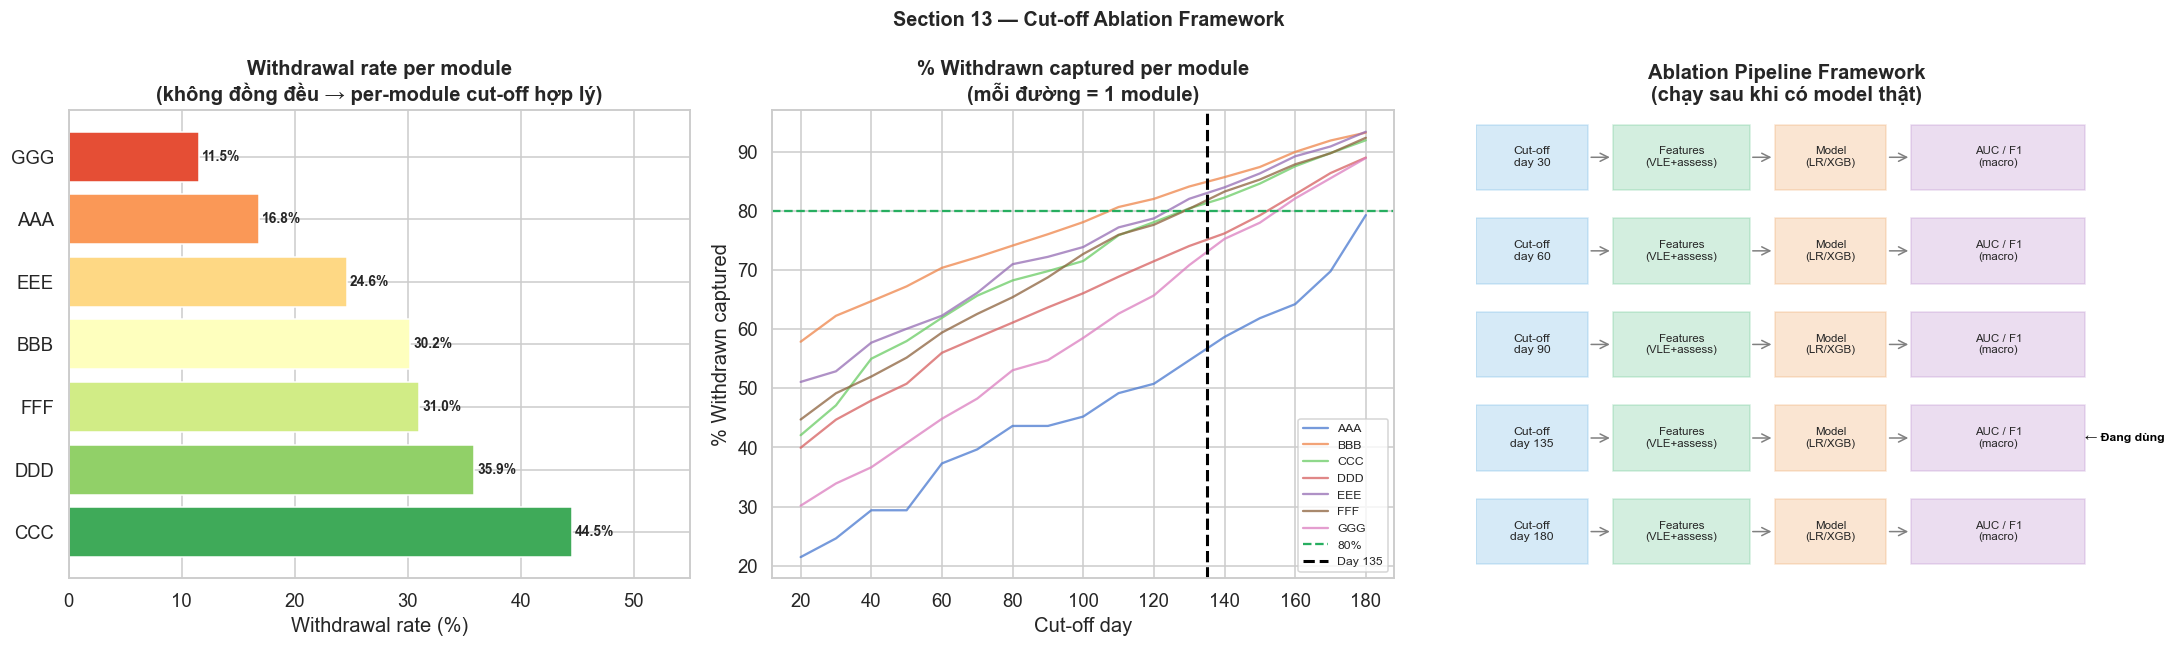


=== TODO: Sau Feature Engineering ===
  for cutoff in [30, 60, 90, 135, 180]:
      X = build_features(cutoff)
      model.fit(X_train, y_train)
      metrics[cutoff] = evaluate(model, X_val, y_val)
  plot(cutoffs, metrics)  # → chọn cut-off tối ưu từ curve


In [17]:
def section13_cutoff_ablation_framework():
    df_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
    df_reg  = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
    df_crs  = pd.read_csv(DATA_DIR / 'courses.csv')

    merged = (
        df_reg
        .merge(df_info[['code_module','code_presentation','id_student','final_result']],
               on=['code_module','code_presentation','id_student'], how='inner')
        .merge(df_crs, on=['code_module','code_presentation'], how='left')
    )
    withdrawn = merged[merged['final_result'] == 'Withdrawn'].copy()

    # ── 13a: Per-module withdrawal rate → cut-off đồng đều không? ────────
    w_by_module = (
        df_info.groupby('code_module')
        .apply(lambda x: (x['final_result'] == 'Withdrawn').mean() * 100)
        .round(1).rename('withdrawal_rate_%').sort_values(ascending=False)
    )

    print('=== Withdrawal rate per module ===')
    print(w_by_module.to_string())
    print()

    # Per-module: % Withdrawn captured tại day 60, 90, 135
    cutoff_checkpoints = [60, 90, 135]
    module_cutoff = []
    for mod in df_info['code_module'].unique():
        w_mod   = withdrawn[withdrawn['code_module'] == mod]
        total_w = len(w_mod)
        if total_w == 0:
            continue
        row = {'module': mod}
        for c in cutoff_checkpoints:
            n = (w_mod['date_unregistration'] <= c).sum()
            row[f'day_{c}'] = round(n / total_w * 100, 1)
        module_cutoff.append(row)
    df_mc = pd.DataFrame(module_cutoff).set_index('module')
    print('=== % Withdrawn captured per module tại các cut-off ===')
    print(df_mc.to_string())

    # ── 13b: Per-module cut-off so với fixed cut-off ─────────────────────
    cutoffs = range(20, 181, 10)
    records = []
    for mod in df_info['code_module'].unique():
        w_mod   = withdrawn[withdrawn['code_module'] == mod]
        total_w = len(w_mod)
        mod_len = df_crs[df_crs['code_module'] == mod]['module_presentation_length'].median()
        if total_w == 0 or pd.isna(mod_len):
            continue
        for c in cutoffs:
            n = (w_mod['date_unregistration'] <= c).sum()
            records.append({
                'module': mod, 'cutoff_day': c,
                'pct_captured': n / total_w * 100,
                'cutoff_ratio': c / mod_len,
            })
    df_mc2 = pd.DataFrame(records)

    # ── 13c: Ablation framework plot ─────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Chart 1: Withdrawal rate per module
    colors_mod = plt.cm.RdYlGn(
        np.linspace(0.15, 0.85, len(w_by_module))[::-1]
    )
    bars = axes[0].barh(w_by_module.index, w_by_module.values, color=colors_mod)
    for bar, val in zip(bars, w_by_module.values):
        axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    axes[0].set_title('Withdrawal rate per module\n(không đồng đều → per-module cut-off hợp lý)',
                      fontweight='bold')
    axes[0].set_xlabel('Withdrawal rate (%)')
    axes[0].set_xlim(0, 55)

    # Chart 2: % Withdrawn captured vs cutoff — per module
    for mod in df_mc2['module'].unique():
        sub = df_mc2[df_mc2['module'] == mod]
        axes[1].plot(sub['cutoff_day'], sub['pct_captured'],
                     linewidth=1.5, alpha=0.75, label=mod)
    axes[1].axhline(80, color='#27ae60', linestyle='--', linewidth=1.5, label='80%')
    axes[1].axvline(CUTOFF_DAY, color='black', linestyle='--', linewidth=2,
                    label=f'Day {CUTOFF_DAY}')
    axes[1].set_title('% Withdrawn captured per module\n(mỗi đường = 1 module)',
                      fontweight='bold')
    axes[1].set_xlabel('Cut-off day')
    axes[1].set_ylabel('% Withdrawn captured')
    axes[1].legend(fontsize=8)

    # Chart 3: Ablation framework diagram
    test_cutoffs = [30, 60, 90, 135, 180]
    axes[2].set_xlim(0, 10)
    axes[2].set_ylim(-0.5, len(test_cutoffs) - 0.5)
    axes[2].axis('off')

    axes[2].set_title('Ablation Pipeline Framework\n(chạy sau khi có model thật)',
                      fontweight='bold')

    for i, c in enumerate(test_cutoffs):
        y = len(test_cutoffs) - 1 - i
        # Box: cut-off
        rect_co = plt.Rectangle((0, y - 0.35), 1.8, 0.7,
                                 facecolor='#3498db', alpha=0.2, edgecolor='#3498db')
        axes[2].add_patch(rect_co)
        axes[2].text(0.9, y, f'Cut-off\nday {c}', ha='center', va='center', fontsize=8)
        # Arrow
        axes[2].annotate('', xy=(2.2, y), xytext=(1.8, y),
                         arrowprops=dict(arrowstyle='->', color='gray'))
        # Box: features
        rect_f = plt.Rectangle((2.2, y - 0.35), 2.2, 0.7,
                                facecolor='#27ae60', alpha=0.2, edgecolor='#27ae60')
        axes[2].add_patch(rect_f)
        axes[2].text(3.3, y, 'Features\n(VLE+assess)', ha='center', va='center', fontsize=7.5)
        # Arrow
        axes[2].annotate('', xy=(4.8, y), xytext=(4.4, y),
                         arrowprops=dict(arrowstyle='->', color='gray'))
        # Box: model
        rect_m = plt.Rectangle((4.8, y - 0.35), 1.8, 0.7,
                                facecolor='#e67e22', alpha=0.2, edgecolor='#e67e22')
        axes[2].add_patch(rect_m)
        axes[2].text(5.7, y, 'Model\n(LR/XGB)', ha='center', va='center', fontsize=7.5)
        # Arrow
        axes[2].annotate('', xy=(7.0, y), xytext=(6.6, y),
                         arrowprops=dict(arrowstyle='->', color='gray'))
        # Box: metrics
        rect_r = plt.Rectangle((7.0, y - 0.35), 2.8, 0.7,
                                facecolor='#9b59b6', alpha=0.2, edgecolor='#9b59b6')
        axes[2].add_patch(rect_r)
        axes[2].text(8.4, y, 'AUC / F1\n(macro)', ha='center', va='center', fontsize=7.5)

        # Highlight current chosen
        if c == CUTOFF_DAY:
            axes[2].annotate(f'← Đang dùng', xy=(9.8, y), fontsize=8,
                             color='black', fontweight='bold', va='center')

    plt.suptitle('Section 13 — Cut-off Ablation Framework', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n=== TODO: Sau Feature Engineering ===')
    print('  for cutoff in [30, 60, 90, 135, 180]:')
    print('      X = build_features(cutoff)')
    print('      model.fit(X_train, y_train)')
    print('      metrics[cutoff] = evaluate(model, X_val, y_val)')
    print('  plot(cutoffs, metrics)  # → chọn cut-off tối ưu từ curve')

section13_cutoff_ablation_framework()

**Feature Engineering**

0. Thiết lập chung



*   Tải toàn bộ dataset
*   CUTOFF_DAY: 135 (Điểm cắt dữ liệu để dự báo).
*   RANDOM_SEED: 42 (Dùng xuyên suốt toàn bộ pipeline để đảm bảo tính tái lập).
*   Mục tiêu: Phân loại 4 lớp (Pass / Fail / Withdrawn / Distinction), ưu tiên tối đa việc phát hiện sớm nhóm Withdrawn.





In [ ]:
CUTOFF_DAY = 135
RANDOM_SEED = 42

df_assessments = pd.read_csv(DATA_DIR / 'assessments.csv')
df_studentInfo = pd.read_csv(DATA_DIR / 'studentInfo.csv')
df_studentAssessment = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
df_studentRegistration = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
df_studentVle = pd.read_csv(DATA_DIR / 'studentVle.csv')
df_courses = pd.read_csv(DATA_DIR / 'courses.csv')
df_vle = pd.read_csv(DATA_DIR / 'vle.csv')

target_map = {
    'Pass' : 0,
    'Fail' : 1,
    'Withdrawn' : 2,
    'Distinction' : 3
}

df_studentInfo['target'] = df_studentInfo['final_result'].map(target_map)
print(df_studentInfo['target'].value_counts())

**1. Tiền xử lý dữ liệu & Làm sạch (Semantic Nulls)**

*   **`date_registration`**: Điền các giá trị thiếu bằng giá trị trung vị (median) của đợt học tương ứng.
*   **`imd_band`**: Chuyển đổi các giá trị NULL thành nhãn "Unknown" (gán giá trị 10, cuối thang đo).
*   **`score`**: Điền giá trị 0 cho các cột điểm bị trống (NULL = không nộp bài).
*  **Loại bỏ cột nhiễu**: Xóa bỏ `week_from`, `week_to` (tỷ lệ trống cao) và `date_unregistration` (tránh rò rỉ dữ liệu).


In [ ]:
df_studentRegistration['date_registration'] = df_studentRegistration.groupby(['code_module', 'code_presentation'])['date_registration'].transform(lambda x: x.fillna(x.median()))
if 'date_unregistration' in df_studentRegistration.columns:
    df_studentRegistration = df_studentRegistration.drop(columns=['date_unregistration'])
df_studentInfo['imd_band'] = df_studentInfo['imd_band'].fillna('Unknown')
if ('week_from' in df_vle.columns) and ('week_to' in df_vle.columns):
  df_vle = df_vle.drop(columns=['week_from', 'week_to'])
df_studentAssessment['score'] = df_studentAssessment['score'].fillna(0)

**2. Nhóm tính năng động lực trước khóa học (Pre-Course Engagement)**

Đo lường sự chuẩn bị của sinh viên trước ngày khai giảng (ngày < 0):

*   **`pre_course_clicks`**: Tổng lượng tương tác của sinh viên trước ngày 0.
*   **`pre_course_active_days`**: Số ngày sinh viên truy cập hệ thống trước ngày 0.
*   **`has_pre_course_activity`**: Biến nhị phân xác định sinh viên có chuẩn bị sớm hay không.

In [ ]:
pre_courses_vle = df_studentVle[df_studentVle['date'] < 0].copy()

pre_courses_engagement = pre_courses_vle.groupby(['id_student']).agg(
    pre_course_clicks = ('sum_click', 'sum'),
    pre_course_active_days = ('date', 'nunique')
).reset_index()

df_studentInfo = df_studentInfo.drop(columns=['pre_course_clicks', 'pre_course_active_days'], errors='ignore')
df_studentInfo = df_studentInfo.merge(pre_courses_engagement, on='id_student', how='left')
df_studentInfo[['pre_course_clicks', 'pre_course_active_days']] = df_studentInfo[['pre_course_clicks', 'pre_course_active_days']].fillna(0)
df_studentInfo['has_pre_course_activity'] = (df_studentInfo['pre_course_active_days'] > 0).astype(int)

### 3. Nhóm tính năng tương tác VLE (Temporal Features)

Tập trung vào đặc trưng hành vi biến thiên của sinh viên tính đến ngày `CUTOFF_DAY`:

*   **`last_active_day`**: Ngày tương tác cuối cùng (chỉ số quan trọng nhất để nhận diện sinh viên `Withdrawn`).
*   **`std_clicks`**: Độ lệch chuẩn lượng click hàng ngày để đo tính kỷ luật và đều đặn trong học tập.
*   **`active_days`**: Tổng số ngày thực tế có tương tác trên hệ thống.
*   **`Weekly Clicks`**: Tạo 20 cột (`clicks_week_1` đến `clicks_week_20`) dựa trên `ceil(CUTOFF_DAY / 7)`. Điền 0 cho các tuần không hoạt động.
*   **`Activity Breakdown`**: Tách riêng lượng click của các tài nguyên quan trọng:
    *   `clicks_oucontent`: Nội dung bài học chính.
    *   `clicks_forumng`: Tương tác diễn đàn (thường tương quan cao với kết quả `Pass`).
    *   `clicks_quiz`, `clicks_resource`: Các tín hiệu bổ trợ khác từ các loại hoạt động này.

In [ ]:
df_days_before_cutoff = df_studentVle[df_studentVle['date'] <= CUTOFF_DAY].copy()
df_vle_before_cutoff = df_days_before_cutoff.groupby(['id_student']).agg(
    last_active_day = ('date', 'max'),
    std_clicks = ('sum_click', 'std'),
    active_days = ('date', 'nunique')
).reset_index()


df_days_before_cutoff['week'] = np.ceil(df_days_before_cutoff['date']/7).astype(int)
weekly = df_days_before_cutoff.pivot_table(
    index='id_student',
    columns='week',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
)
weekly.columns=[f'clicks_week_{int(c)}' for c in weekly.columns]

df_detail_studentVle = df_days_before_cutoff.merge(df_vle[['id_site', 'activity_type']], on='id_site', how='left')
df_activity_breakdown = df_detail_studentVle.pivot_table(
    index='id_student',
    columns='activity_type',
    values='sum_click',
    aggfunc='sum',
    fill_value=0
)
df_activity_breakdown = df_activity_breakdown[['oucontent', 'forumng', 'quiz', 'resource']]
df_activity_breakdown.columns = [f'clicks_{c}' for c in df_activity_breakdown.columns]
df_studentInfo = df_studentInfo.merge(df_vle_before_cutoff, on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(weekly.reset_index(), on='id_student', how='left')
df_studentInfo = df_studentInfo.merge(df_activity_breakdown.reset_index(), on='id_student', how='left')

vle_cols = ['last_active_day', 'std_clicks', 'active_days'] + list(weekly.columns) + list(df_activity_breakdown.columns)
for col in vle_cols:
    if col in df_studentInfo.columns:
        df_studentInfo[col] = df_studentInfo[col].fillna(0)